In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
# Install SHAP if needed
!pip install -q shap

/kaggle/input/datasets/imnebouchakour/crldataset/CRL-Dataset-CTCR-Pose.csv


# A Data-Driven Machine Learning Framework for Forward Kinematics Prediction of Concentric Tube Continuum Robots Using Enhanced Stacking Ensemble Learning

### Author
**Zohra-Imene Bouchakour**

---

## Experimental Framework and Reproducibility Setup

This notebook presents the complete experimental implementation accompanying the research entitled:

**"A Data-Driven Machine Learning Framework for Forward Kinematics Prediction of Concentric Tube Continuum Robots Using Enhanced Stacking Ensemble Learning."**

The objective of this work is to develop an accurate, robust, and fully reproducible machine learning framework for predicting the forward kinematics of Concentric Tube Continuum Robots (CTCRs).

The proposed methodology progressively investigates increasingly sophisticated machine learning approaches, including:

- Data preprocessing and feature engineering;
- Linear Regression;
- Extra Trees Regression;
- Multi-Layer Perceptron neural networks;
- Stacking ensemble learning;
- Gaussian data augmentation;
- Ridge-regularized meta-learning;
- Optimization of the number of base learners.

All experiments are conducted under identical experimental conditions using fixed random seeds, standardized preprocessing pipelines, and systematic evaluation protocols to ensure full reproducibility.

The notebook concludes with a comprehensive comparison of all investigated models and an evaluation against the published benchmark reported by Grassmann *et al.*

# 1. Imports, Global Configuration and Reproducibility Control

This section initializes the computational environment and defines all global parameters required throughout the study.

Reproducibility is a fundamental requirement in scientific machine learning research. Therefore, all sources of randomness are controlled using fixed random seeds, and every experiment is associated with a unique timestamp to ensure complete traceability of generated models, figures, and evaluation results.

The configuration defined in this section serves as the foundation for all subsequent analyses and guarantees that experimental outcomes can be reproduced under identical conditions.

In [ ]:
# ============================================================
# 1. STANDARD LIBRARIES
# ============================================================

import os
import random
import pickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


# ============================================================
# 2. VISUALIZATION LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 150


# ============================================================
# 3. MACHINE LEARNING LIBRARIES
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor


# ============================================================
# 4. STATISTICAL ANALYSIS
# ============================================================

from scipy.stats import ks_2samp
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel


# ============================================================
# 5. EXPLAINABILITY
# ============================================================

import shap


# ============================================================
# 6. GLOBAL EXPERIMENT CONFIGURATION
# ============================================================

EXPERIMENT_NAME = "Ultimate_Stacking_CTCR"

RANDOM_STATE = 42

DATA_PATH = "/kaggle/input/datasets/imnebouchakour/crldataset/CRL-Dataset-CTCR-Pose.csv"

OUTPUT_DIR = "/kaggle/working/final_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 7. REPRODUCIBILITY CONTROL
# ============================================================

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


# ============================================================
# 8. EXPERIMENT TRACKING
# ============================================================

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

print("=" * 70)
print("EXPERIMENT INITIALIZATION")
print("=" * 70)

print(f"Experiment : {EXPERIMENT_NAME}")
print(f"Random Seed: {RANDOM_STATE}")
print(f"Timestamp  : {RUN_TIMESTAMP}")
print(f"Output Dir : {OUTPUT_DIR}")

print("=" * 70)

EXPERIMENT INITIALIZATION
Experiment : Ultimate_Stacking_CTCR
Random Seed: 42
Timestamp  : 20260708_123730
Output Dir : /kaggle/working/final_results


# 2. Dataset Loading and Integrity Verification

## Objective

The objective of this section is to load the CTCR dataset and perform a comprehensive integrity assessment before any exploratory analysis, feature engineering, or model development.

Data quality is a fundamental prerequisite for reliable machine learning research. Missing values, duplicated observations, corrupted records, or structural inconsistencies may introduce bias and compromise the validity of experimental findings.

## Scientific Rationale

The CTCR dataset was acquired from a physical robotic platform and contains joint-space configurations together with corresponding end-effector pose measurements. Consequently, a systematic verification procedure is required to ensure that the dataset accurately represents valid robotic configurations and can be safely used for scientific experimentation.

The following integrity checks are performed:

* Dataset dimensionality verification.
* Feature and column structure validation.
* Missing value detection.
* Duplicate observation identification.
* Basic consistency assessment.

The successful completion of these checks establishes a reliable foundation for all subsequent analyses and guarantees the scientific validity and reproducibility of the experimental framework.


In [ ]:
# ============================================================
# DATASET LOADING AND INTEGRITY VERIFICATION
# ============================================================
#
# Purpose:
# Load the CTCR dataset and verify its structural integrity.
#
# Scientific Rationale:
# Reliable machine learning experiments require a complete,
# consistent, and physically valid dataset. Therefore,
# integrity checks are performed before any exploratory
# analysis, feature engineering, or model development.
#
# ============================================================

print("=" * 70)
print("DATASET LOADING AND INTEGRITY VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, header=None)

# ------------------------------------------------------------
# Assign column names according to the dataset specification
# ------------------------------------------------------------

df.columns = [
    "alpha1","beta1","alpha2","beta2","alpha3","beta3",
    "dalpha1","dbeta1","dalpha2","dbeta2","dalpha3","dbeta3",
    "x0","y0","z0","eta0","eps01","eps02","eps03",
    "x1","y1","z1","eta1","eps11","eps12","eps13",
    "x2","y2","z2","eta2","eps21","eps22","eps23",
    "x3","y3","z3","eta3","eps31","eps32","eps33"
]

# ------------------------------------------------------------
# Dataset dimensions
# ------------------------------------------------------------

n_samples, n_features = df.shape

print(f"\nNumber of samples : {n_samples:,}")
print(f"Number of features: {n_features}")

# ------------------------------------------------------------
# Missing value analysis
# ------------------------------------------------------------

missing_values = df.isnull().sum().sum()

print(f"\nMissing values detected: {missing_values}")

if missing_values == 0:
    print("✓ Dataset is complete (no missing values detected)")
else:
    print("⚠ Missing values detected - further investigation required")

# ------------------------------------------------------------
# Duplicate observation analysis
# ------------------------------------------------------------

duplicate_rows = df.duplicated().sum()

print(f"\nDuplicate observations detected: {duplicate_rows}")

if duplicate_rows == 0:
    print("✓ No duplicated observations detected")
else:
    print("⚠ Duplicate observations detected")

# ------------------------------------------------------------
# Dataset summary table
# ------------------------------------------------------------

dataset_summary = pd.DataFrame({
    "Property": [
        "Number of Samples",
        "Number of Features",
        "Missing Values",
        "Duplicate Observations"
    ],
    "Value": [
        n_samples,
        n_features,
        missing_values,
        duplicate_rows
    ]
})

print("\nDataset Integrity Summary")
display(dataset_summary)

# ------------------------------------------------------------
# Save integrity report
# ------------------------------------------------------------

dataset_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dataset_integrity_summary.csv"
    ),
    index=False
)

print("\n✓ Dataset integrity verification completed successfully.")

DATASET LOADING AND INTEGRITY VERIFICATION

Number of samples : 100,000
Number of features: 40

Missing values detected: 0
✓ Dataset is complete (no missing values detected)

Duplicate observations detected: 0
✓ No duplicated observations detected

Dataset Integrity Summary


,Property,Value
0,Number of Samples,100000
1,Number of Features,40
2,Missing Values,0
3,Duplicate Observations,0



✓ Dataset integrity verification completed successfully.


# 3. Descriptive Statistics and Data Distribution Analysis

## Objective

The objective of this section is to characterize the statistical properties of the CTCR dataset and investigate the distribution of robot joint variables prior to any feature transformation or model development.

A thorough understanding of the data distribution is essential for identifying potential biases, assessing variability, detecting non-linear patterns, and selecting appropriate preprocessing strategies.

## Scientific Rationale

Machine learning models are inherently influenced by the statistical characteristics of the training data. Consequently, descriptive statistics and distribution analyses are performed to evaluate the representativeness of the collected robotic configurations and to better understand the operating space covered by the dataset.

The analyses conducted in this section include:

* Descriptive statistics of joint-space variables.
* Descriptive statistics of end-effector pose variables.
* Distribution visualization of robot control variables.
* Skewness analysis.
* Kurtosis analysis.

These investigations provide valuable insights into the complexity of the learning problem and support the design of an effective feature engineering strategy.


In [ ]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

# ------------------------------------------------------------
# Definition of input and output variables
# ------------------------------------------------------------

joint_vars = [
    "alpha1", "beta1",
    "alpha2", "beta2",
    "alpha3", "beta3"
]

tip_pose_vars = [
    "x3", "y3", "z3",
    "eta3", "eps31", "eps32", "eps33"
]

# ------------------------------------------------------------
# Joint-space statistics
# ------------------------------------------------------------

joint_stats = df[joint_vars].describe().round(4)

print("\nJoint-Space Variables")
display(joint_stats)

# ------------------------------------------------------------
# End-effector pose statistics
# ------------------------------------------------------------

pose_stats = df[tip_pose_vars].describe().round(4)

print("\nEnd-Effector Pose Variables")
display(pose_stats)

# ------------------------------------------------------------
# Export statistics for publication
# ------------------------------------------------------------

joint_stats.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "joint_space_statistics.csv"
    )
)

pose_stats.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "tip_pose_statistics.csv"
    )
)

print("\n✓ Statistical summaries exported successfully.")

DESCRIPTIVE STATISTICS

Joint-Space Variables


,alpha1,beta1,alpha2,beta2,alpha3,beta3
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,-0.0023,-65.0064,0.0010,-47.5547,0.0022,-24.9891
std,0.6042,21.9233,0.6036,19.4318,0.6044,14.4219
min,-1.0472,-128.6075,-1.0472,-94.8999,-1.0472,-49.9988
25%,-0.5277,-80.6520,-0.5215,-61.5171,-0.5222,-37.4796
50%,-0.0050,-65.0788,-0.0006,-47.5815,0.0027,-25.0301
75%,0.5218,-49.4702,0.5224,-33.5827,0.5245,-12.5295
max,1.0472,-0.5112,1.0472,-0.2697,1.0472,-0.0001



End-Effector Pose Variables


,x3,y3,z3,eta3,eps31,eps32,eps33
count,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000,100000.0000
mean,-21.2005,8.2178,-214.1288,0.7092,-0.0435,0.0218,0.6639
std,14.7017,25.0344,13.6781,0.0842,0.1409,0.1372,0.0897
min,-72.1760,-65.9970,-255.1092,0.1178,-0.4871,-0.5822,-0.1648
25%,-32.5619,-11.2804,-223.9670,0.6570,-0.1407,-0.0735,0.6060
50%,-20.5189,8.3743,-214.3802,0.7109,-0.0444,0.0207,0.6654
75%,-9.8784,27.6228,-204.5793,0.7660,0.0548,0.1173,0.7254
max,18.5894,85.6325,-172.8153,0.9682,0.4387,0.5117,0.9575



✓ Statistical summaries exported successfully.


## Interpretation of Descriptive Statistics

The descriptive statistics indicate that the CTCR dataset provides extensive coverage of the robot configuration space. The three rotational variables (α₁, α₂, α₃) exhibit nearly symmetric distributions centered around zero, suggesting a balanced exploration of rotational configurations.

The translational variables (β₁, β₂, β₃) are strictly negative, which is consistent with the physical constraints imposed by the concentric tube robot design. Moreover, the observed ranges confirm that the dataset spans a wide variety of insertion depths, thereby increasing the diversity of robot configurations available for learning.

Regarding the end-effector pose variables, substantial variability is observed across the position coordinates (x₃, y₃, z₃), indicating broad workspace coverage. The quaternion components also remain within physically plausible ranges, providing an initial indication of measurement consistency and data reliability.

Overall, these observations suggest that the dataset is sufficiently diverse to support the development and evaluation of data-driven forward kinematics models.


# 3.2 Distribution Analysis of Joint Variables

## Objective

The objective of this section is to investigate the statistical distributions of the CTCR joint variables prior to feature transformation and model development.

A comprehensive understanding of the input data distribution is essential for the design of reliable machine learning models. Distribution analysis enables the identification of potential biases, asymmetries, heavy-tailed behaviors, and underrepresented regions within the robot configuration space.

## Scientific Rationale

The CTCR dataset was generated from experimentally acquired robot configurations spanning a large portion of the operational workspace. Consequently, analyzing the statistical properties of both rotational and translational variables provides valuable insights into the diversity, representativeness, and complexity of the learning problem.

To characterize these distributions, graphical visualization is complemented by quantitative measures including skewness and kurtosis. These statistics provide information regarding distribution symmetry, tail behavior, and the presence of extreme observations, all of which may influence model training, generalization, and prediction robustness.

The analyses performed in this section include:

- Distribution visualization of all joint variables.
- Mean and median comparison.
- Skewness analysis.
- Kurtosis analysis.
- Statistical summary export for publication purposes.

DISTRIBUTION ANALYSIS OF JOINT VARIABLES


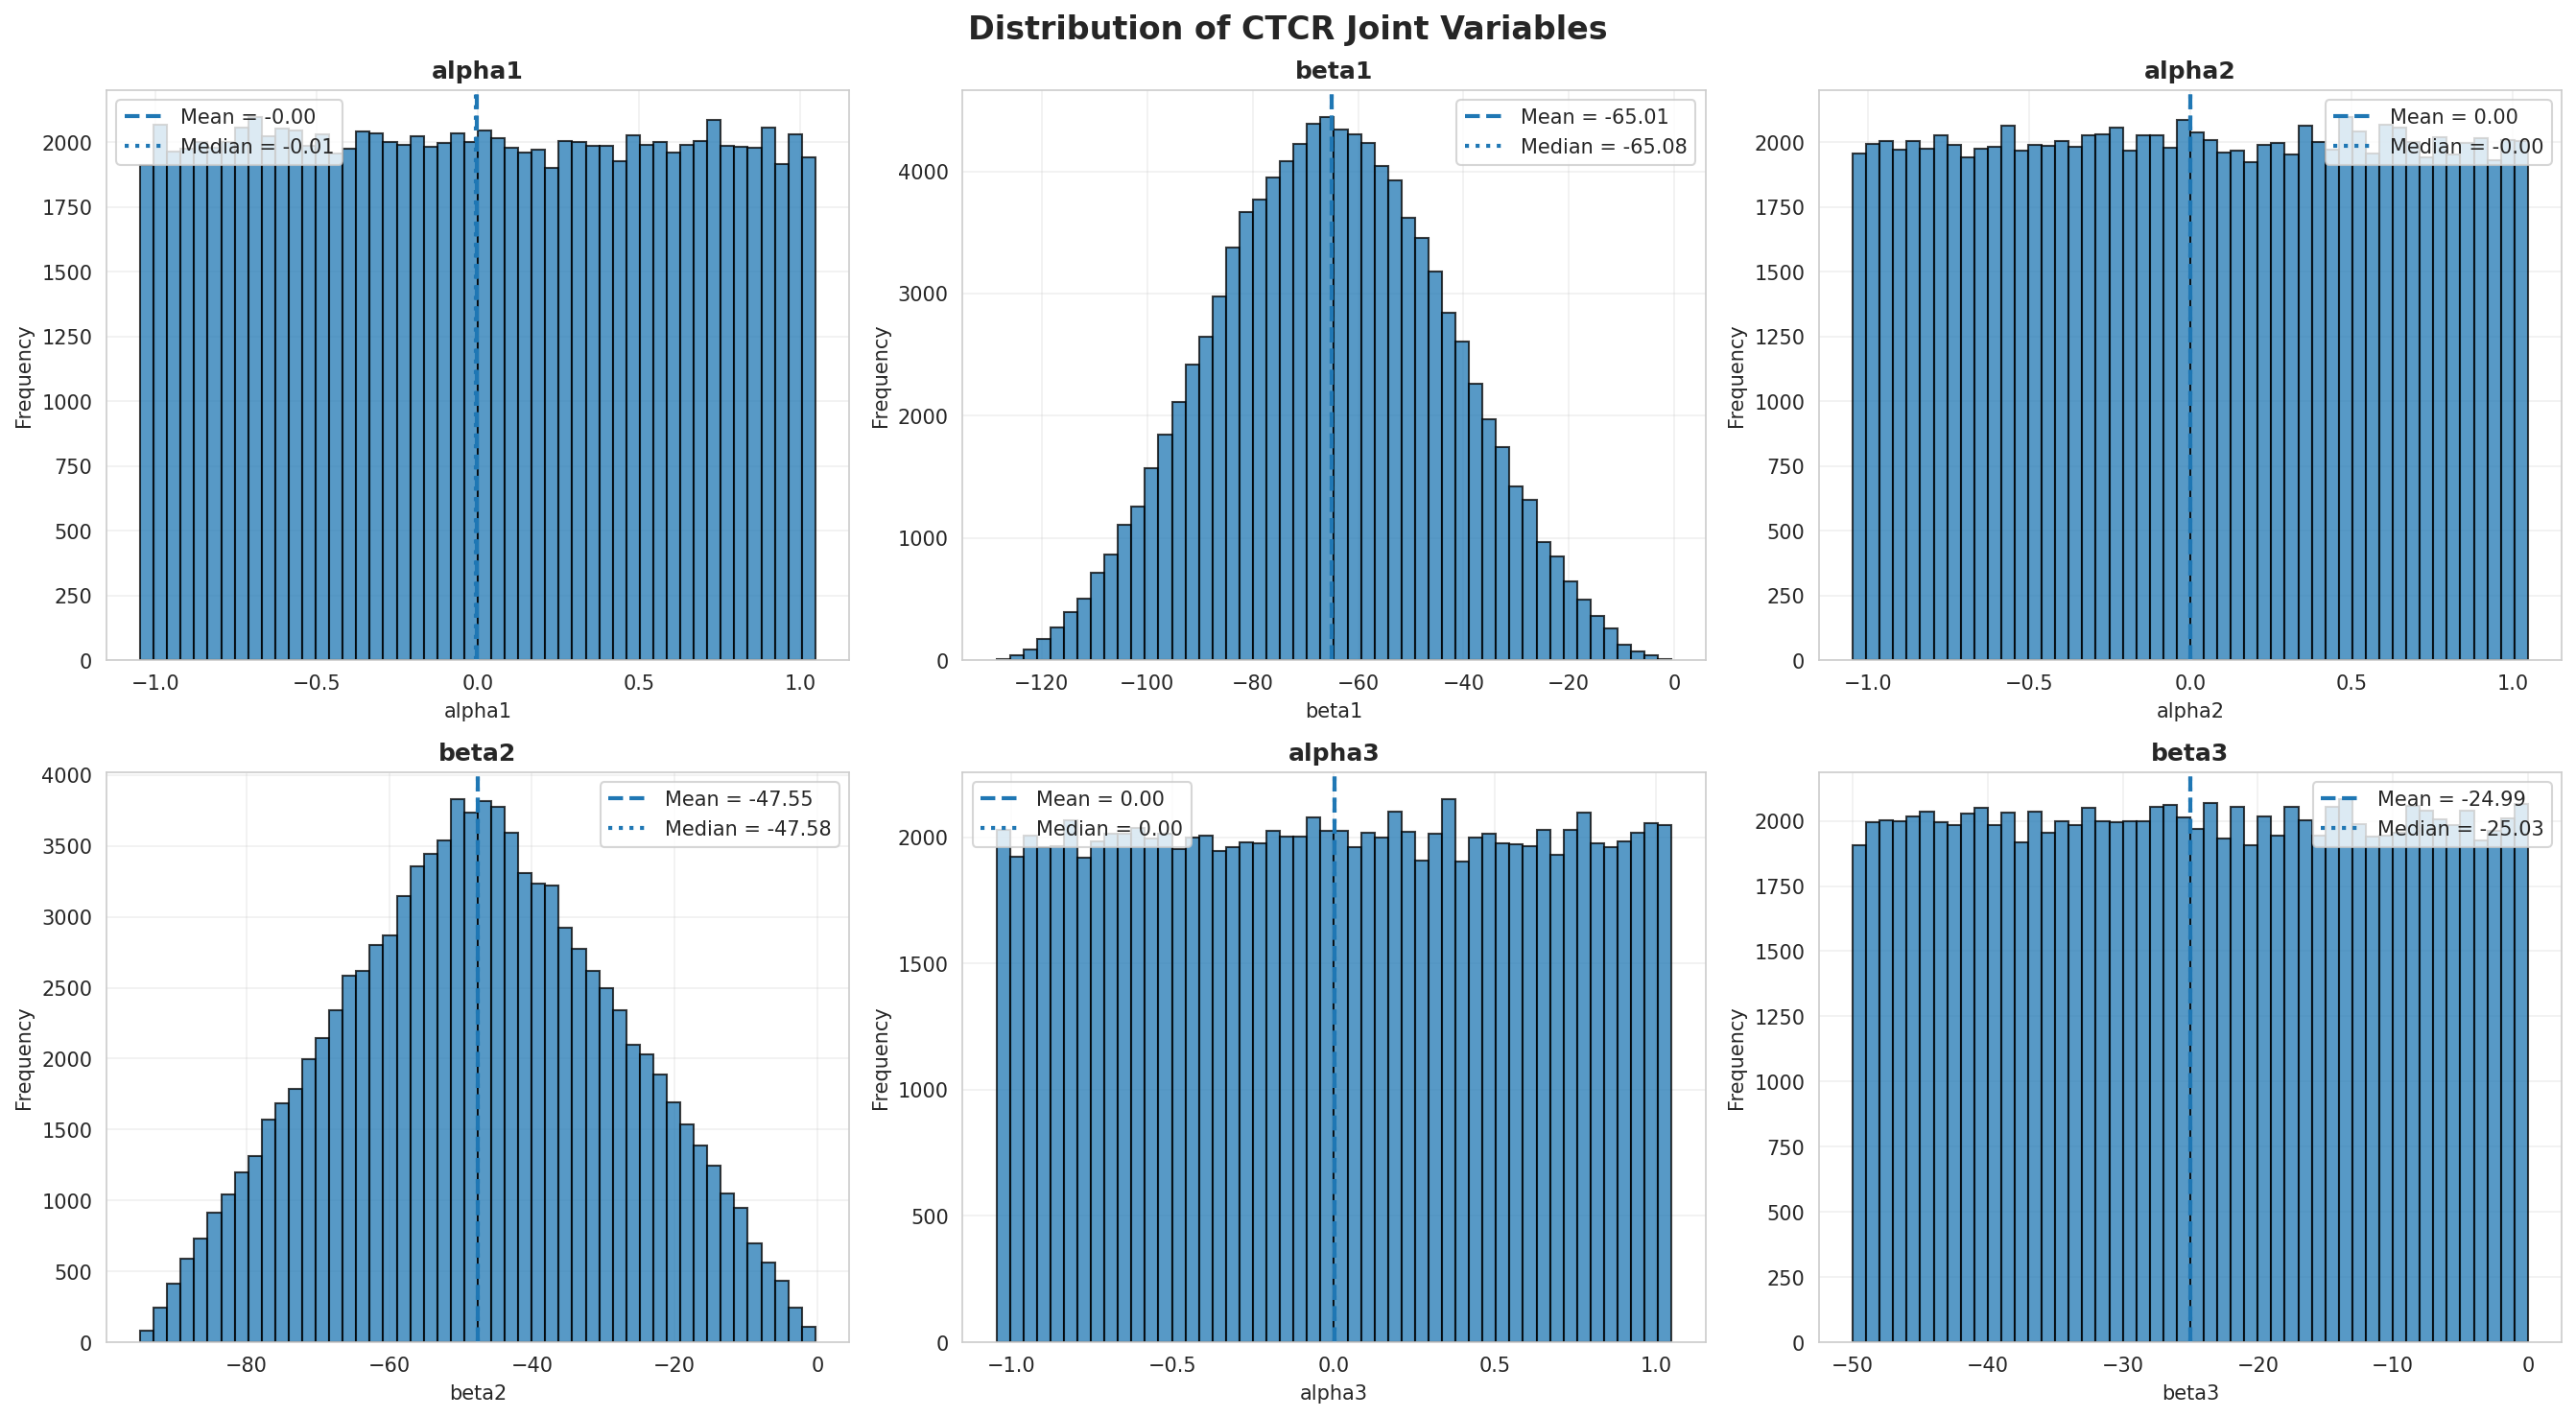


Distribution Statistics Summary


,Variable,Mean,Median,Std,Skewness,Kurtosis
0,alpha1,-0.0023,-0.0050,0.6042,0.0082,-1.2028
1,beta1,-65.0064,-65.0788,21.9233,0.0119,-0.4393
2,alpha2,0.0010,-0.0006,0.6036,-0.0018,-1.1971
3,beta2,-47.5547,-47.5815,19.4318,0.0029,-0.6089
4,alpha3,0.0022,0.0027,0.6044,-0.0032,-1.1970
5,beta3,-24.9891,-25.0301,14.4219,0.0022,-1.1985



✓ Distribution statistics exported successfully.
✓ Figure saved : joint_variable_distributions.png
✓ Table saved  : distribution_statistics.csv


In [ ]:
# ============================================================
# DISTRIBUTION ANALYSIS OF JOINT VARIABLES
# ============================================================
#
# Purpose:
# Analyze the statistical distributions of CTCR joint variables
# and quantify their distributional properties through
# skewness and kurtosis metrics.
#
# Outputs:
# - Distribution figures
# - Distribution statistics table
# - Publication-ready CSV exports
#
# ============================================================

from scipy.stats import skew, kurtosis

print("=" * 70)
print("DISTRIBUTION ANALYSIS OF JOINT VARIABLES")
print("=" * 70)

# ------------------------------------------------------------
# Distribution Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

distribution_stats = []

for idx, var in enumerate(joint_vars):

    values = df[var]

    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std()

    skew_val = skew(values)
    kurt_val = kurtosis(values)

    # Histogram
    axes[idx].hist(
        values,
        bins=50,
        edgecolor="black",
        alpha=0.75
    )

    # Mean
    axes[idx].axvline(
        mean_val,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_val:.2f}"
    )

    # Median
    axes[idx].axvline(
        median_val,
        linestyle=":",
        linewidth=2,
        label=f"Median = {median_val:.2f}"
    )

    axes[idx].set_title(
        f"{var}",
        fontsize=12,
        fontweight="bold"
    )

    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel("Frequency")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

    distribution_stats.append([
        var,
        mean_val,
        median_val,
        std_val,
        skew_val,
        kurt_val
    ])

# ------------------------------------------------------------
# Figure Formatting
# ------------------------------------------------------------

plt.suptitle(
    "Distribution of CTCR Joint Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "joint_variable_distributions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Statistical Summary Table
# ------------------------------------------------------------

distribution_df = pd.DataFrame(
    distribution_stats,
    columns=[
        "Variable",
        "Mean",
        "Median",
        "Std",
        "Skewness",
        "Kurtosis"
    ]
)

print("\nDistribution Statistics Summary")
display(
    distribution_df.round(4)
)

# ------------------------------------------------------------
# Export Results
# ------------------------------------------------------------

distribution_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "distribution_statistics.csv"
    ),
    index=False
)

print("\n✓ Distribution statistics exported successfully.")
print("✓ Figure saved : joint_variable_distributions.png")
print("✓ Table saved  : distribution_statistics.csv")

## Interpretation of Distribution Analysis

The obtained distributions reveal a well-balanced sampling strategy across the robot configuration space.

The rotational variables (α₁, α₂, α₃) exhibit highly symmetric distributions centered around zero, as confirmed by skewness values close to zero and nearly identical mean and median values. Furthermore, their negative kurtosis values indicate platykurtic behavior, suggesting a relatively uniform exploration of the rotational configuration space.

The translational variables (β₁, β₂, β₃) also present negligible skewness, indicating balanced sampling of insertion depths. However, differences in kurtosis and histogram shapes suggest that the three tubes were not sampled using identical distributions. This observation reflects the physical constraints and operating ranges associated with each tube.

Overall, the distribution analysis demonstrates that the dataset provides broad and balanced coverage of the CTCR configuration space, thereby reducing the risk of sampling bias and supporting the development of robust machine learning models.

# 4. Physical Consistency Verification

## Objective

The objective of this section is to verify that all robotic configurations contained in the CTCR dataset satisfy the physical constraints imposed by the robot architecture and data acquisition process.

## Scientific Rationale

Since the dataset originates from a physical robotic platform, ensuring compliance with known mechanical and geometric constraints is essential. Violations of these constraints may indicate corrupted measurements, preprocessing errors, or physically infeasible robot configurations.

Three categories of physical consistency checks are performed:

- Quaternion norm validation.
- Translation sign constraint verification (β ≤ 0).
- Translation ordering constraint verification (β₁ ≥ β₂ ≥ β₃).

The successful validation of these constraints provides additional confidence in the reliability and physical realism of the dataset.

In [ ]:
# ============================================================
# QUATERNION NORM VALIDATION
# ============================================================

print("=" * 70)
print("QUATERNION NORM VALIDATION")
print("=" * 70)

quat_cols = {
    "Base": ["eta0","eps01","eps02","eps03"],
    "Tube 1": ["eta1","eps11","eps12","eps13"],
    "Tube 2": ["eta2","eps21","eps22","eps23"],
    "Tube 3": ["eta3","eps31","eps32","eps33"]
}

quat_results = []

for name, cols in quat_cols.items():

    qnorm = np.sqrt(
        (df[cols] ** 2).sum(axis=1)
    )

    quat_results.append([
        name,
        qnorm.mean(),
        qnorm.std(),
        qnorm.min(),
        qnorm.max()
    ])

quaternion_summary = pd.DataFrame(
    quat_results,
    columns=[
        "Quaternion",
        "Mean Norm",
        "Std",
        "Min",
        "Max"
    ]
)

display(
    quaternion_summary.round(6)
)

quaternion_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "quaternion_norm_validation.csv"
    ),
    index=False
)

print("\n✓ Quaternion validation completed successfully.")

QUATERNION NORM VALIDATION


,Quaternion,Mean Norm,Std,Min,Max
0,Base,1.0,0.0,1.0,1.0
1,Tube 1,1.0,0.0,1.0,1.0
2,Tube 2,1.0,0.0,1.0,1.0
3,Tube 3,1.0,0.0,1.0,1.0



✓ Quaternion validation completed successfully.


## Interpretation of Quaternion Validation

The quaternion validation results demonstrate perfect compliance with the unit-norm constraint for all recorded orientations.

Across the four measurement locations (base, tube 1, tube 2, and tube 3), the quaternion norms are exactly equal to one, with zero observed variance. This confirms that the orientation data are mathematically valid and internally consistent throughout the entire dataset.

The absence of norm deviations indicates that no numerical corruption, normalization error, or measurement inconsistency is present in the recorded orientation representations. Consequently, the quaternion-based orientation measurements can be considered fully reliable for subsequent machine learning analyses.

# 4.2 Translation Constraint Verification

## Objective

The objective of this analysis is to verify that all translational variables satisfy the physical insertion constraints imposed by the CTCR architecture.

## Scientific Rationale

In concentric tube continuum robots, tube translations correspond to insertion depths measured relative to a reference frame. According to the dataset definition and robot design, all insertion values must remain non-positive.

Any violation of this constraint would indicate the presence of physically infeasible robot configurations or data acquisition errors. Therefore, systematic verification of the translation sign constraint is required before proceeding with model development.

In [ ]:
# ============================================================
# TRANSLATION CONSTRAINT VALIDATION
# ============================================================

print("=" * 70)
print("TRANSLATION CONSTRAINT VALIDATION")
print("=" * 70)

translation_results = []

for beta in ["beta1", "beta2", "beta3"]:

    valid_ratio = (df[beta] <= 0).mean()

    translation_results.append([
        beta,
        valid_ratio * 100,
        df[beta].min(),
        df[beta].max()
    ])

translation_summary = pd.DataFrame(
    translation_results,
    columns=[
        "Variable",
        "Constraint Satisfaction (%)",
        "Minimum Value",
        "Maximum Value"
    ]
)

display(
    translation_summary.round(4)
)

translation_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "translation_constraint_validation.csv"
    ),
    index=False
)

print("\n✓ Translation constraint validation completed successfully.")

TRANSLATION CONSTRAINT VALIDATION


,Variable,Constraint Satisfaction (%),Minimum Value,Maximum Value
0,beta1,100.0,-128.6075,-0.5112
1,beta2,100.0,-94.8999,-0.2697
2,beta3,100.0,-49.9988,-0.0001



✓ Translation constraint validation completed successfully.


## Interpretation of Translation Constraint Validation

The translation constraint validation confirms that all insertion variables strictly satisfy the physical requirements imposed by the CTCR architecture.

For all three tubes, 100% of the recorded configurations comply with the non-positive insertion constraint (β ≤ 0). No violations were detected across the 100,000 available samples.

These results demonstrate that the dataset contains only physically feasible insertion configurations and that no preprocessing or acquisition inconsistencies are present within the translational variables.

Consequently, the insertion measurements can be considered fully reliable for subsequent feature engineering and machine learning analyses.

# 4.3 Translation Ordering Constraint Verification

## Objective

The objective of this analysis is to verify that the tube insertion depths satisfy the geometric ordering relationship observed within the CTCR dataset.

## Scientific Rationale

Beyond the non-positive insertion constraint, the insertion depths exhibit an inherent ordering relationship associated with the nested structure of the concentric tube robot.

Preliminary statistical analysis revealed that the insertion variables follow the ordering pattern:

β₁ ≤ β₂ ≤ β₃

This relationship is consistent with the observed insertion depth ranges and reflects the geometric arrangement of the concentric tubes.

Any violation of this ordering would indicate mechanically inconsistent configurations or potential data acquisition errors.

Therefore, a systematic verification of insertion ordering is performed across the entire dataset.

In [ ]:
# ============================================================
# TRANSLATION ORDERING CONSTRAINT VALIDATION
# ============================================================
#
# Purpose:
# Verify that all insertion depths satisfy the ordering
# relationship observed within the CTCR dataset.
#
# Constraint:
# β1 ≤ β2 ≤ β3
#
# ============================================================

print("=" * 70)
print("TRANSLATION ORDERING CONSTRAINT VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# Ordering Constraint Verification
# ------------------------------------------------------------

valid_ordering = (
    (df["beta1"] <= df["beta2"]) &
    (df["beta2"] <= df["beta3"])
)

total_samples = len(df)

valid_configurations = valid_ordering.sum()

ordering_violations = total_samples - valid_configurations

satisfaction_rate = (
    valid_configurations / total_samples
) * 100

# ------------------------------------------------------------
# Results Summary
# ------------------------------------------------------------

ordering_summary = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Valid Configurations",
        "Constraint Violations",
        "Satisfaction Rate (%)"
    ],
    "Value": [
        total_samples,
        valid_configurations,
        ordering_violations,
        satisfaction_rate
    ]
})

print("\nTranslation Ordering Validation Summary")

display(
    ordering_summary.round(4)
)

# ------------------------------------------------------------
# Export Results
# ------------------------------------------------------------

ordering_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "translation_ordering_validation.csv"
    ),
    index=False
)

print(
    f"\nConstraint Satisfaction Rate: "
    f"{satisfaction_rate:.4f}%"
)

print(
    f"Constraint Violations: "
    f"{ordering_violations}"
)

print(
    "\n✓ Translation ordering validation completed successfully."
)

TRANSLATION ORDERING CONSTRAINT VALIDATION

Translation Ordering Validation Summary


,Metric,Value
0,Total Samples,100000.0
1,Valid Configurations,100000.0
2,Constraint Violations,0.0
3,Satisfaction Rate (%),100.0



Constraint Satisfaction Rate: 100.0000%
Constraint Violations: 0

✓ Translation ordering validation completed successfully.


## Interpretation of Translation Ordering Validation

The translation ordering validation confirms that all insertion depths satisfy the geometric ordering relationship observed within the CTCR dataset.

Across the entire dataset, 100% of the recorded configurations comply with the ordering constraint β₁ ≤ β₂ ≤ β₃, and no violations were detected among the 100,000 available samples.

This result demonstrates that the insertion depths remain fully consistent with the nested structure of the concentric tube robot and that no mechanically infeasible configurations are present.

Combined with the quaternion norm validation and the non-positive insertion constraint verification, these findings provide strong evidence that the dataset is both mathematically and physically consistent. Consequently, the dataset can be considered highly reliable for subsequent feature engineering, machine learning, and statistical analyses.


## Conclusion of Physical Consistency Verification

The physical consistency analyses demonstrate that the CTCR dataset fully satisfies all investigated mathematical and mechanical constraints.

Quaternion orientations are perfectly normalized, insertion depths remain strictly non-positive, and the geometric ordering relationship between tube translations is satisfied across all recorded configurations.

These results confirm the absence of physically infeasible robot states and provide strong evidence regarding the quality, reliability, and internal consistency of the dataset.

Therefore, the dataset constitutes a robust foundation for the development, evaluation, and interpretation of data-driven forward kinematics models.


# 5. Workspace Analysis and Reachability Assessment

## Objective

The objective of this section is to characterize the spatial workspace covered by the CTCR dataset and evaluate the diversity of reachable end-effector configurations.

## Scientific Rationale

Understanding the spatial distribution of robot configurations is essential for assessing dataset representativeness and the potential generalization capability of machine learning models.

A dataset that covers a broad portion of the operational workspace is more likely to produce robust and reliable predictive models.

The analyses performed in this section investigate:

- Base-to-tip distance distributions.
- Workspace coverage characteristics.
- Reachable end-effector positions.
- Spatial diversity of robot configurations.

These analyses provide additional insight into the complexity and representativeness of the learning problem.

# 5.1 Base-to-Tip Distance Analysis

## Objective

The objective of this analysis is to quantify the spatial extent of the robot workspace by measuring the Euclidean distance between the robot base and the end-effector.

## Scientific Rationale

The base-to-tip distance provides a direct measure of robot extension and workspace utilization. Analyzing its distribution offers valuable insights into the diversity of robot configurations represented within the dataset.

A broad distribution of distances indicates that the dataset captures both compact and highly extended configurations, which is desirable for developing robust machine learning models capable of generalizing across the operational workspace.

BASE-TO-TIP DISTANCE ANALYSIS


,Statistic,Value
0,Minimum,79.8688
1,Maximum,181.8597
2,Mean,131.4441
3,Median,131.7346
4,Standard Deviation,17.3663


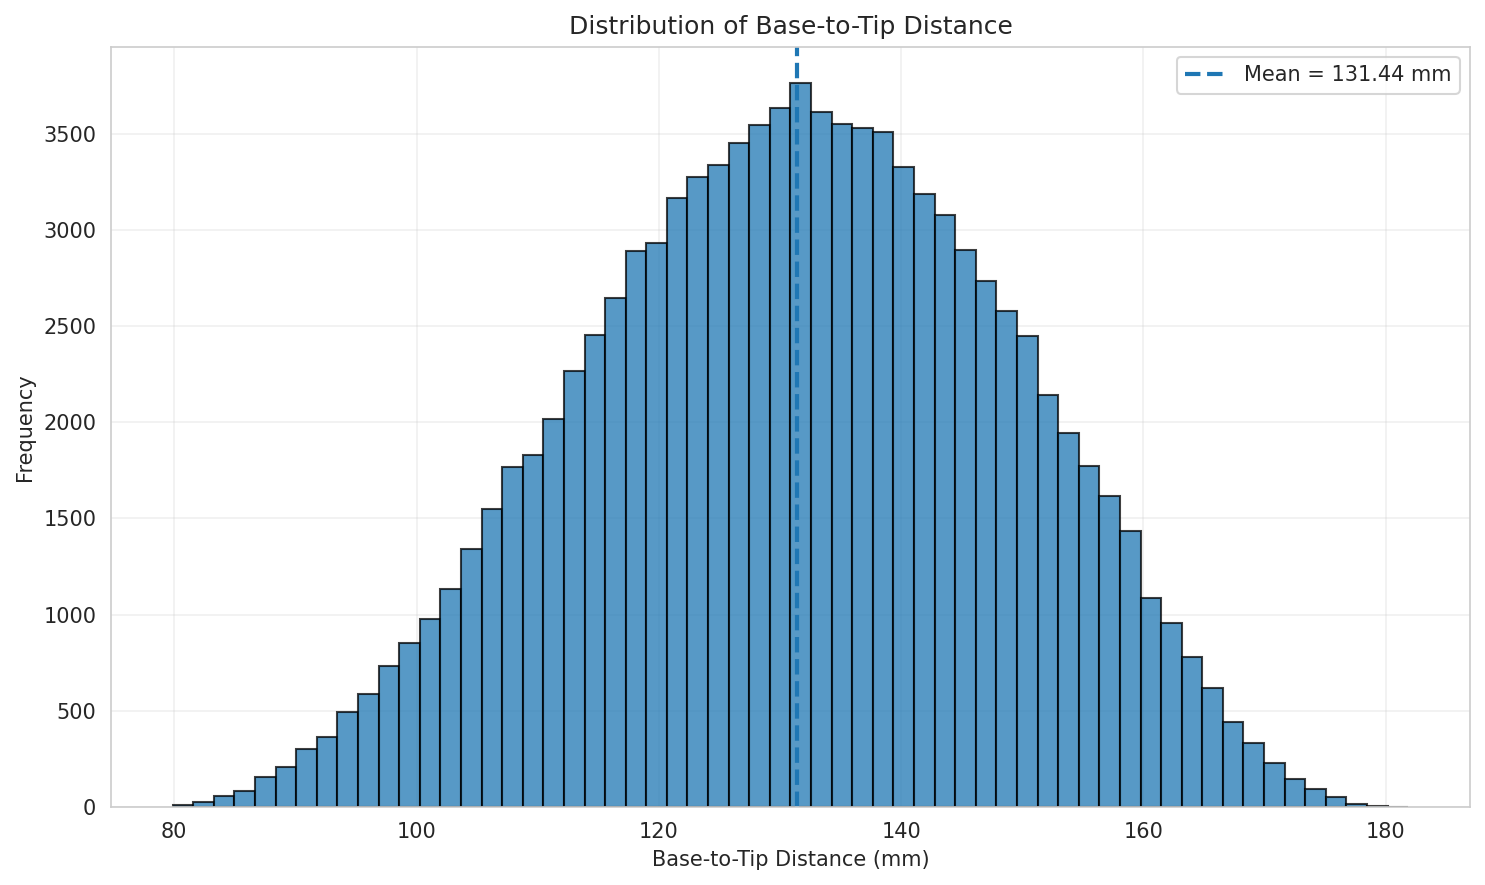


✓ Base-to-tip distance analysis completed successfully.


In [ ]:
# ============================================================
# BASE-TO-TIP DISTANCE ANALYSIS
# ============================================================

print("=" * 70)
print("BASE-TO-TIP DISTANCE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Euclidean Distance Computation
# ------------------------------------------------------------

df["base_tip_distance"] = np.sqrt(
    (df["x3"] - df["x0"])**2 +
    (df["y3"] - df["y0"])**2 +
    (df["z3"] - df["z0"])**2
)

# ------------------------------------------------------------
# Distance Statistics
# ------------------------------------------------------------

distance_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],
    "Value": [
        df["base_tip_distance"].min(),
        df["base_tip_distance"].max(),
        df["base_tip_distance"].mean(),
        df["base_tip_distance"].median(),
        df["base_tip_distance"].std()
    ]
})

display(
    distance_summary.round(4)
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    df["base_tip_distance"],
    bins=60,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    df["base_tip_distance"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['base_tip_distance'].mean():.2f} mm"
)

plt.xlabel("Base-to-Tip Distance (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Base-to-Tip Distance")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "base_tip_distance_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

distance_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "base_tip_distance_statistics.csv"
    ),
    index=False
)

print("\n✓ Base-to-tip distance analysis completed successfully.")

## Interpretation of Base-to-Tip Distance Analysis

The base-to-tip distance analysis provides quantitative insight into the spatial extent of the CTCR workspace.

The observed distances range from approximately 80 mm to 182 mm, indicating that the dataset contains both compact and highly extended robot configurations. This broad range suggests substantial workspace coverage and a diverse set of reachable end-effector positions.

Furthermore, the mean and median distances are nearly identical, indicating a well-balanced distribution of robot extensions. The histogram exhibits an approximately symmetric bell-shaped profile, suggesting that the dataset is centered around typical operating configurations while still retaining sufficient variability to represent a wide range of robot states.

Overall, these findings indicate that the dataset provides a representative sampling of the robot workspace, which is expected to support robust machine learning model development and generalization.

# 5.2 Workspace Coverage Analysis

## Objective

The objective of this analysis is to investigate the spatial distribution of reachable end-effector positions within the CTCR workspace.

## Scientific Rationale

While the base-to-tip distance provides a one-dimensional measure of robot extension, it does not reveal the geometric structure of the reachable workspace.

Analyzing the spatial distribution of end-effector positions allows a more comprehensive assessment of workspace coverage and dataset diversity. Such analyses are particularly important for evaluating the representativeness of the training data and the expected generalization capability of machine learning models.

The workspace coverage analysis focuses on the distribution of end-effector coordinates and the spatial extent of the reachable region.

# 5.3 3D Reachability Visualization

## Objective

The objective of this analysis is to visualize the three-dimensional workspace occupied by the end-effector positions contained in the CTCR dataset.

## Scientific Rationale

Three-dimensional workspace visualization provides intuitive insight into the geometric structure of the robot's reachable region.

This representation helps identify workspace shape, density variations, and potential coverage limitations that may not be apparent from one-dimensional statistical analyses.

Furthermore, workspace visualizations are commonly reported in continuum robot literature and provide an effective means of communicating dataset diversity and operational reachability.

3D WORKSPACE VISUALIZATION


,Axis,Minimum,Maximum,Range
0,X,-72.1760,18.5894,90.7655
1,Y,-65.9970,85.6325,151.6295
2,Z,-255.1092,-172.8153,82.2940


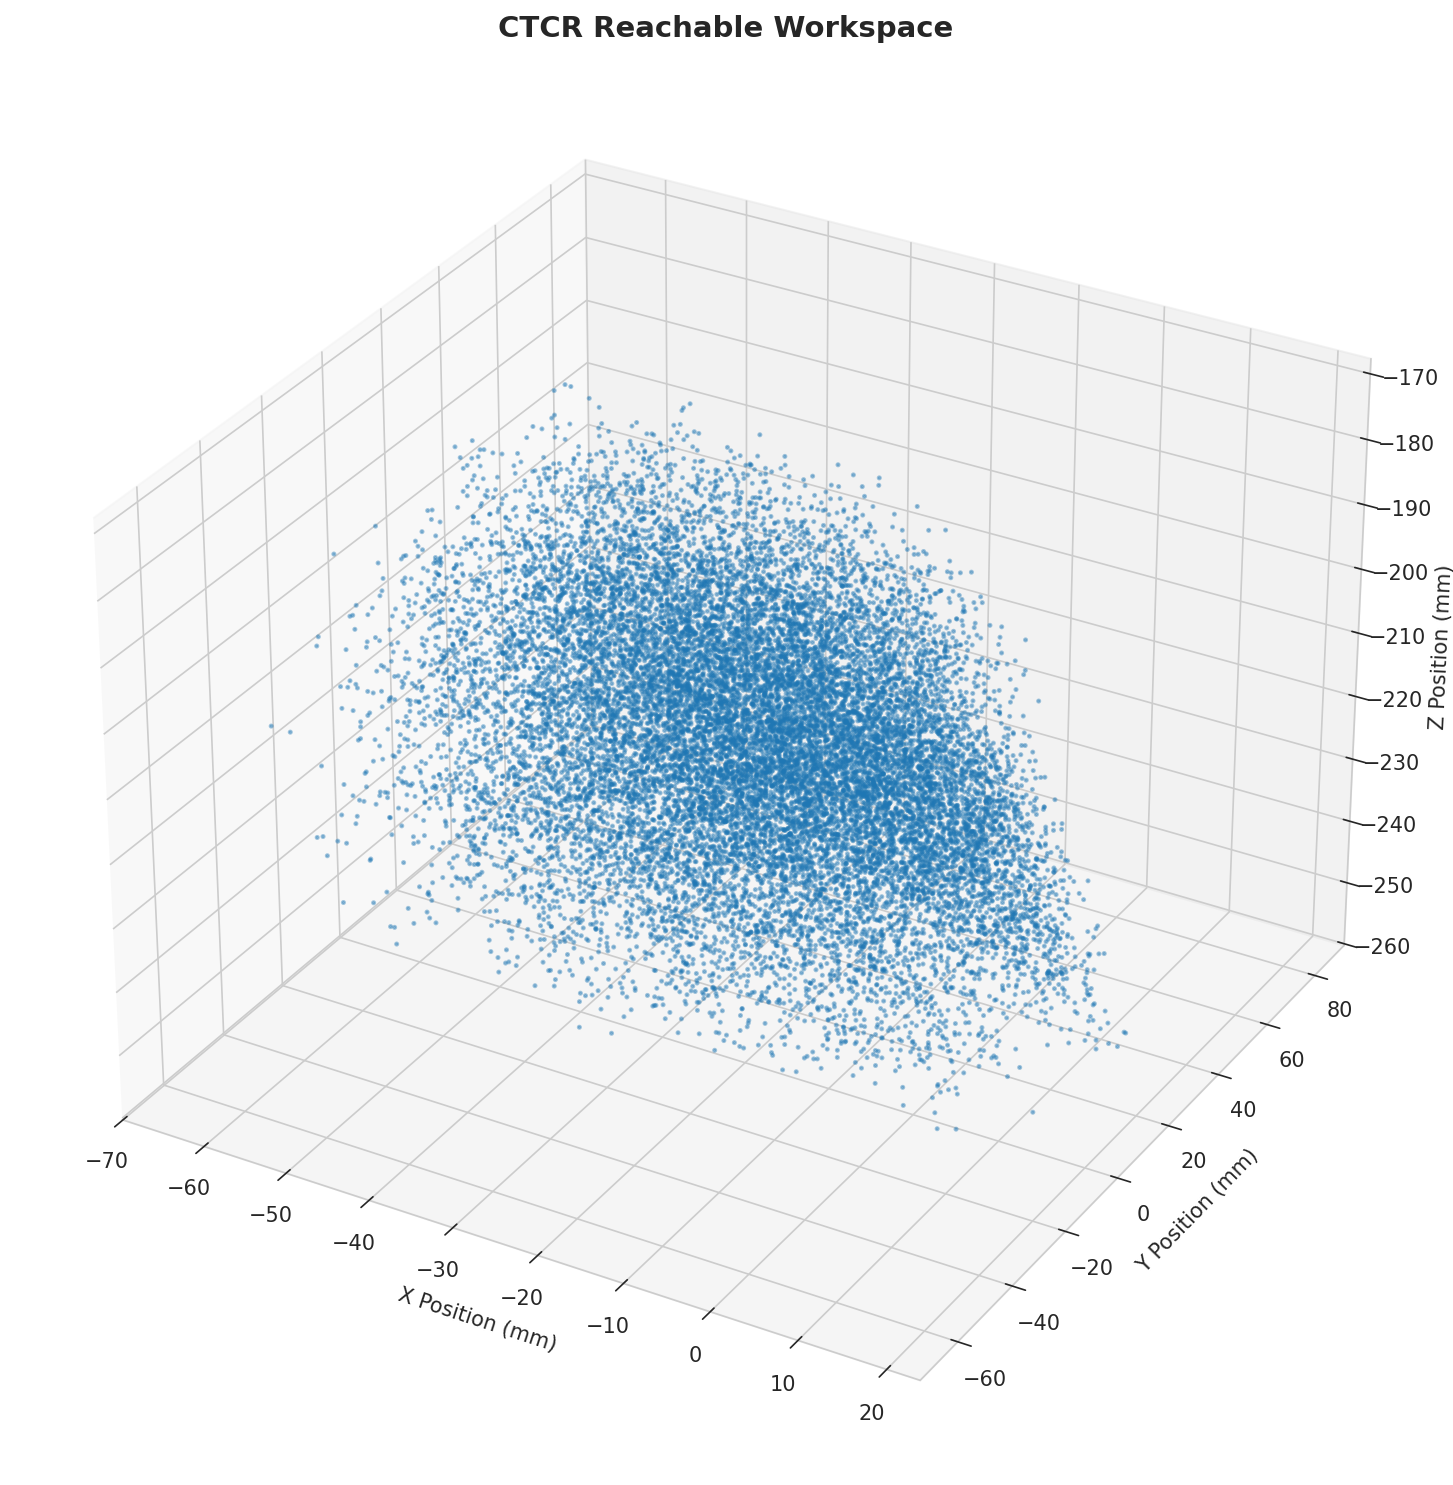


✓ Workspace analysis completed successfully.


In [ ]:
# ============================================================
# 3D WORKSPACE VISUALIZATION
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

print("=" * 70)
print("3D WORKSPACE VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Workspace Statistics
# ------------------------------------------------------------

workspace_summary = pd.DataFrame({
    "Axis": ["X", "Y", "Z"],
    "Minimum": [
        df["x3"].min(),
        df["y3"].min(),
        df["z3"].min()
    ],
    "Maximum": [
        df["x3"].max(),
        df["y3"].max(),
        df["z3"].max()
    ],
    "Range": [
        df["x3"].max() - df["x3"].min(),
        df["y3"].max() - df["y3"].min(),
        df["z3"].max() - df["z3"].min()
    ]
})

display(workspace_summary.round(4))

# ------------------------------------------------------------
# 3D Scatter Plot
# ------------------------------------------------------------

sample_size = min(20000, len(df))

workspace_sample = df.sample(
    sample_size,
    random_state=RANDOM_STATE
)

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    workspace_sample["x3"],
    workspace_sample["y3"],
    workspace_sample["z3"],
    s=2,
    alpha=0.4
)

ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

ax.set_title(
    "CTCR Reachable Workspace",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "ctcr_workspace_3d.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

workspace_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "workspace_statistics.csv"
    ),
    index=False
)

print("\n✓ Workspace analysis completed successfully.")

## Interpretation of 3D Workspace Analysis

The three-dimensional workspace visualization reveals the geometric structure of the reachable region covered by the CTCR dataset.

The workspace exhibits an anisotropic distribution, with the largest spatial variation occurring along the Y-axis. This indicates that the robot possesses greater maneuverability in certain directions, which is consistent with the kinematic behavior of concentric tube continuum robots.

All end-effector positions remain within a physically plausible region characterized by negative Z coordinates, reflecting the dominant orientation


# 5.4 Workspace Projection Analysis

## Objective

The objective of this analysis is to investigate the geometric structure of the CTCR workspace through two-dimensional projections of the reachable end-effector positions.

## Scientific Rationale

Although three-dimensional visualizations provide a global overview of workspace geometry, two-dimensional projections often reveal structural patterns that are difficult to identify in 3D scatter plots.

Workspace projections allow the identification of anisotropic behaviors, coverage density variations, and geometric characteristics associated with the robot kinematics.

The analysis considers projections onto the XY, XZ, and YZ planes.

WORKSPACE PROJECTION ANALYSIS


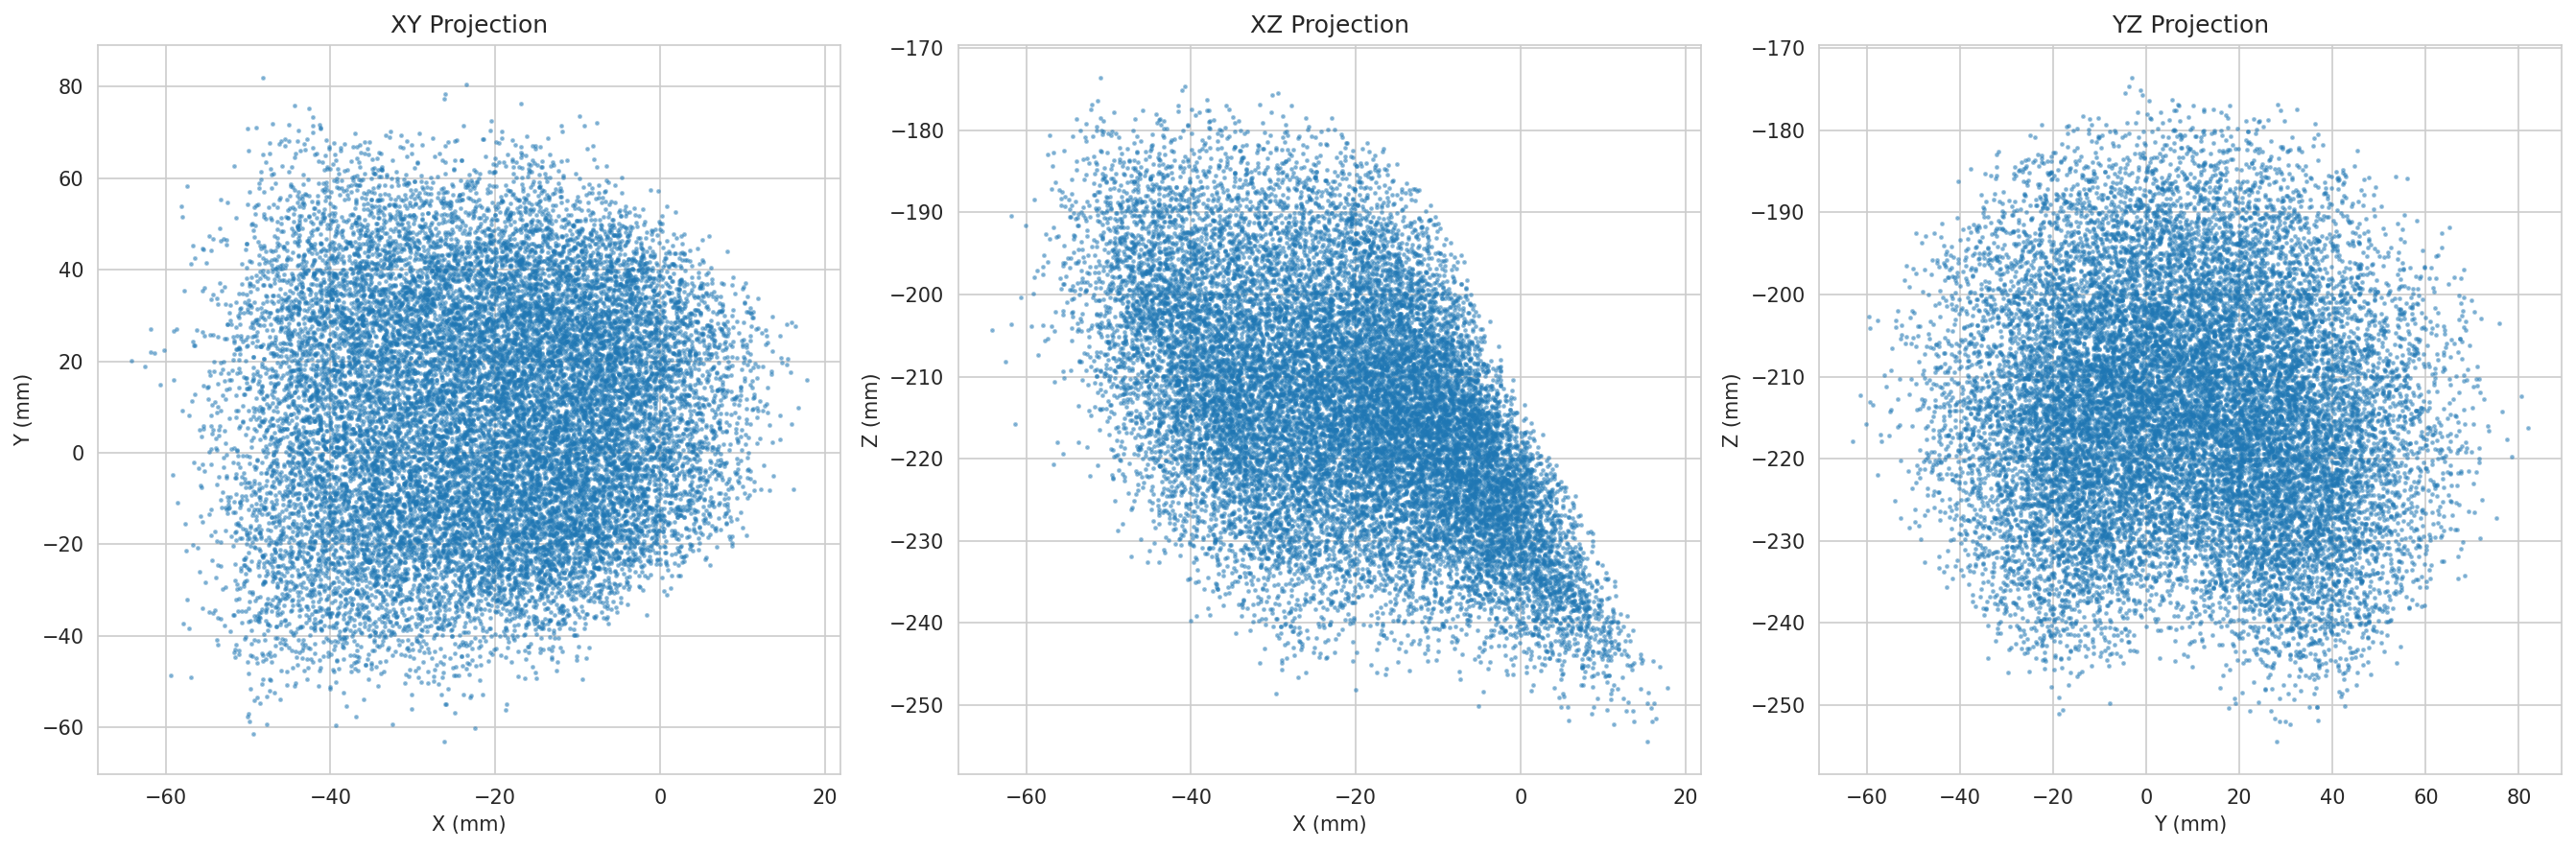


✓ Workspace projection analysis completed successfully.


In [ ]:
# ============================================================
# WORKSPACE PROJECTION ANALYSIS
# ============================================================

print("=" * 70)
print("WORKSPACE PROJECTION ANALYSIS")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,6)
)

sample_size = min(20000, len(df))

workspace_sample = df.sample(
    sample_size,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# XY Projection
# ------------------------------------------------------------

axes[0].scatter(
    workspace_sample["x3"],
    workspace_sample["y3"],
    s=2,
    alpha=0.4
)

axes[0].set_title("XY Projection")
axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")
axes[0].grid(True)

# ------------------------------------------------------------
# XZ Projection
# ------------------------------------------------------------

axes[1].scatter(
    workspace_sample["x3"],
    workspace_sample["z3"],
    s=2,
    alpha=0.4
)

axes[1].set_title("XZ Projection")
axes[1].set_xlabel("X (mm)")
axes[1].set_ylabel("Z (mm)")
axes[1].grid(True)

# ------------------------------------------------------------
# YZ Projection
# ------------------------------------------------------------

axes[2].scatter(
    workspace_sample["y3"],
    workspace_sample["z3"],
    s=2,
    alpha=0.4
)

axes[2].set_title("YZ Projection")
axes[2].set_xlabel("Y (mm)")
axes[2].set_ylabel("Z (mm)")
axes[2].grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "workspace_projections.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Workspace projection analysis completed successfully.")

## Interpretation of Workspace Projection Analysis

The workspace projections provide additional insight into the geometric structure and coverage characteristics of the CTCR dataset.

The XY projection reveals a relatively uniform distribution of reachable end-effector positions with no significant coverage gaps, suggesting balanced exploration of the lateral workspace dimensions.

The XZ projection exhibits a curved and asymmetric structure that reflects the intrinsic kinematic behavior of concentric tube continuum robots. This observation highlights the nonlinear relationship between joint-space variables and end-effector positions, thereby motivating the use of advanced machine learning models for forward kinematics prediction.

The YZ projection further confirms the absence of major under-sampled regions and indicates continuous workspace coverage along the primary bending direction.

Overall, the workspace projections demonstrate that the dataset captures a broad and representative portion of the robot operational workspace while preserving the geometric complexity inherent to continuum robot kinematics.


# 6. Correlation and Dependency Analysis

## Objective

The objective of this section is to investigate the statistical dependencies between robot joint variables and end-effector pose variables.

## Scientific Rationale

Understanding the relationships between inputs and outputs is essential for assessing the complexity of the forward kinematics problem.

Correlation analysis can reveal linear dependencies, variable interactions, and potential sources of predictive information. Furthermore, identifying weak linear correlations may indicate the presence of highly nonlinear relationships, thereby motivating the use of advanced machine learning models.

The analyses performed in this section focus on the interactions between joint-space variables and end-effector pose variables.

# 6.1 Correlation Matrix Analysis

## Objective

The objective of this analysis is to quantify pairwise linear relationships between joint-space variables and end-effector pose variables.

## Scientific Rationale

Pearson correlation coefficients provide a first-order approximation of variable dependencies and can help identify dominant relationships within the dataset.

Although continuum robot kinematics are inherently nonlinear, correlation analysis remains useful for detecting global trends and assessing the predictive potential of individual variables.

CORRELATION MATRIX ANALYSIS


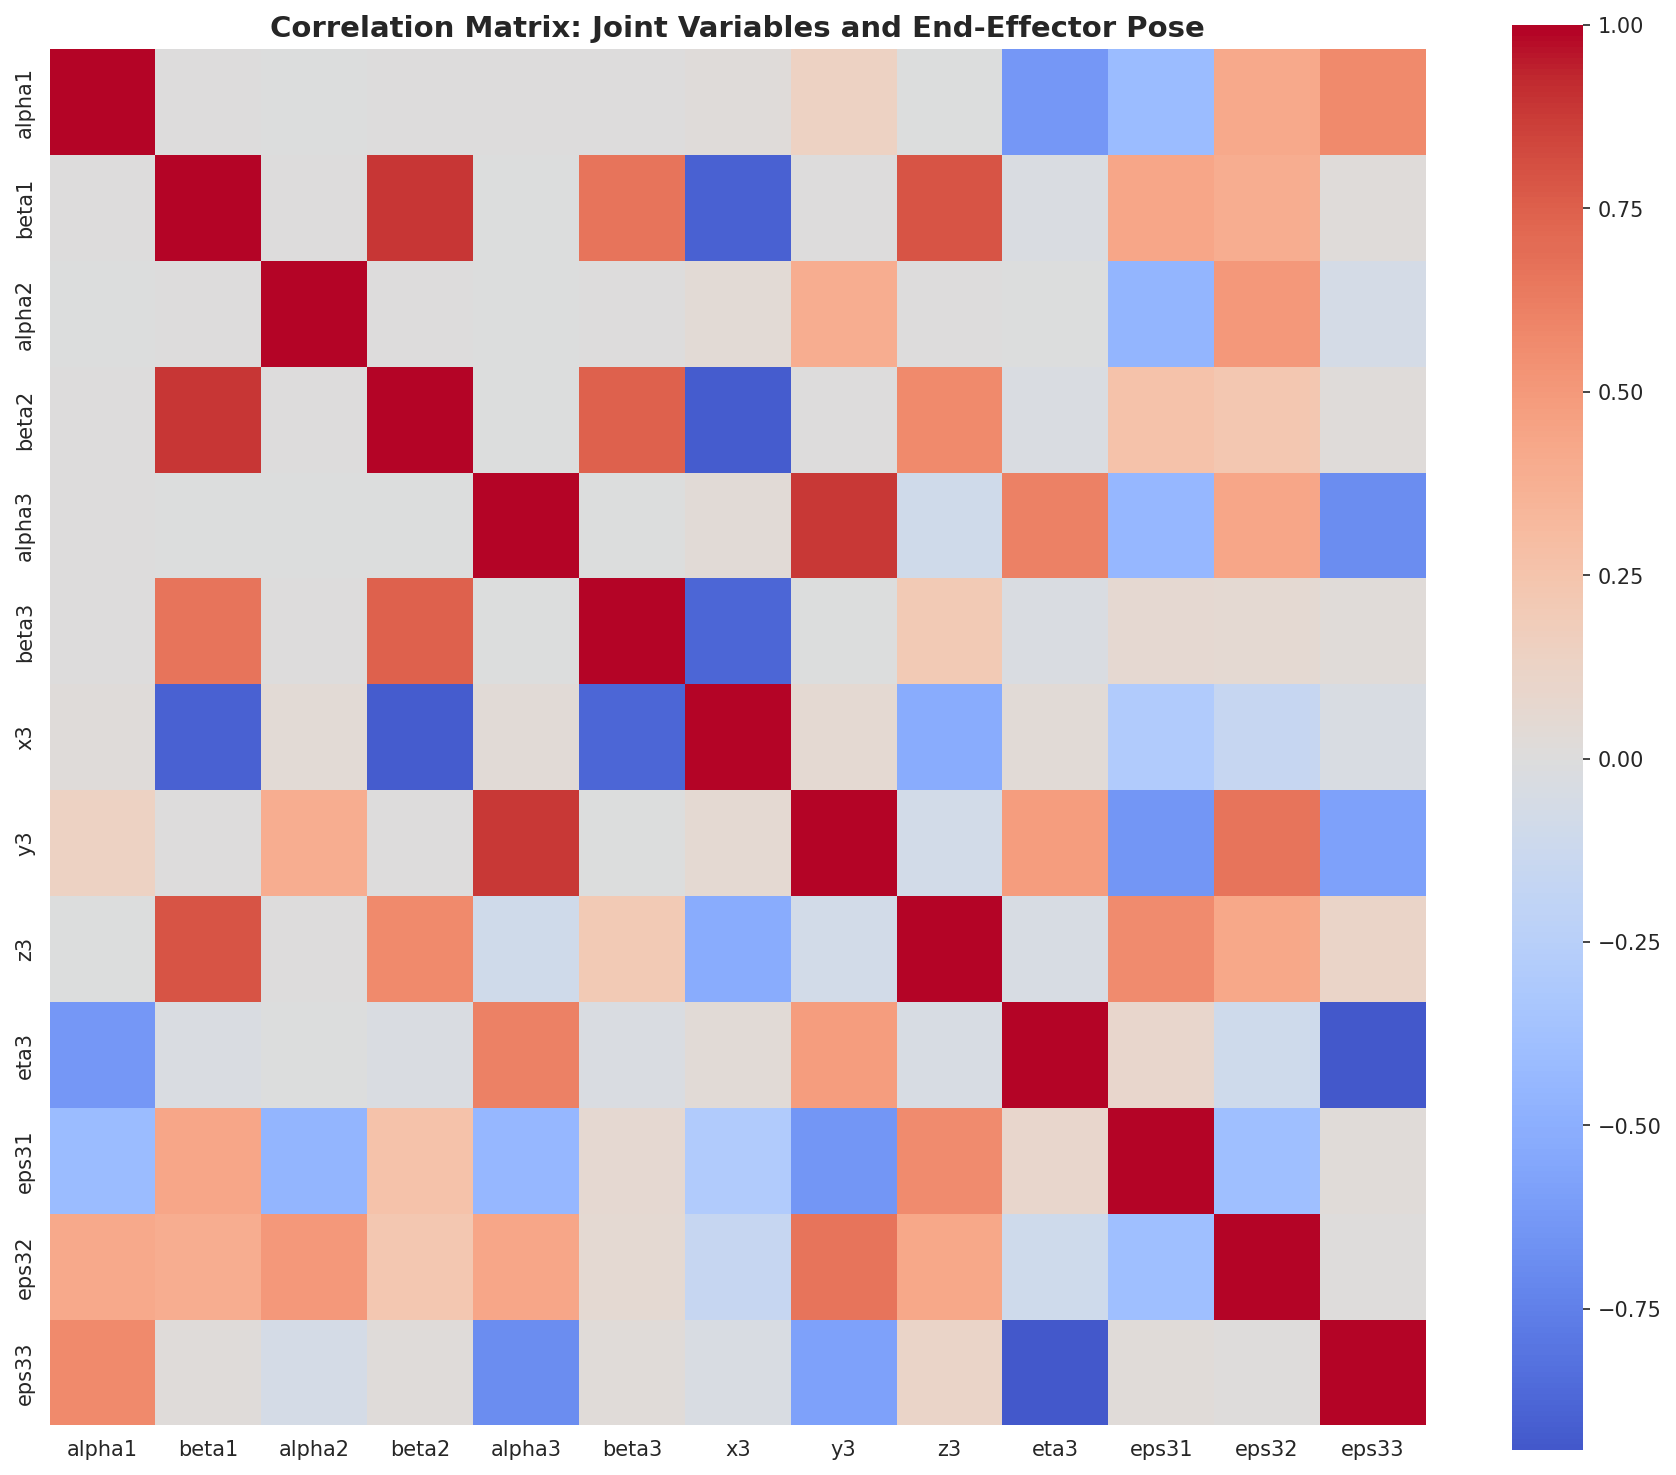

,x3,y3,z3,eta3,eps31,eps32,eps33
alpha1,0.019,0.136,-0.002,-0.631,-0.418,0.420,0.572
beta1,-0.902,0.001,0.793,-0.031,0.436,0.386,0.020
alpha2,0.042,0.396,-0.001,-0.006,-0.462,0.507,-0.069
beta2,-0.926,0.001,0.574,-0.027,0.261,0.229,0.019
alpha3,0.036,0.882,-0.097,0.612,-0.441,0.435,-0.686
beta3,-0.878,-0.007,0.204,-0.029,0.062,0.054,0.023



✓ Correlation analysis completed successfully.


In [ ]:
# ============================================================
# CORRELATION MATRIX ANALYSIS
# ============================================================

print("=" * 70)
print("CORRELATION MATRIX ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Variables of Interest
# ------------------------------------------------------------

joint_vars = [
    "alpha1","beta1",
    "alpha2","beta2",
    "alpha3","beta3"
]

tip_pose_vars = [
    "x3","y3","z3",
    "eta3","eps31","eps32","eps33"
]

analysis_vars = (
    joint_vars +
    tip_pose_vars
)

# ------------------------------------------------------------
# Correlation Matrix
# ------------------------------------------------------------

corr_matrix = (
    df[analysis_vars]
    .corr(method="pearson")
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Correlation Matrix: Joint Variables and End-Effector Pose",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "correlation_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Joint vs Pose Correlations
# ------------------------------------------------------------

joint_pose_corr = (
    corr_matrix
    .loc[joint_vars, tip_pose_vars]
)

display(
    joint_pose_corr.round(3)
)

joint_pose_corr.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "joint_pose_correlations.csv"
    )
)

print(
    "\n✓ Correlation analysis completed successfully."
)

## Interpretation of Correlation Analysis

The correlation analysis reveals several meaningful relationships between joint-space variables and end-effector pose variables.

The translational variables β₁, β₂, and β₃ exhibit very strong correlations with the end-effector X position, indicating that tube insertions play a dominant role in determining the longitudinal displacement of the robot tip.

Similarly, the rotational variable α₃ shows a strong positive correlation with the Y position, suggesting that rotational motion of the innermost tube significantly influences lateral workspace exploration.

The end-effector Z position is primarily influenced by insertion variables, which is consistent with the physical behavior of concentric tube continuum robots.

Although several strong correlations are observed, many input-output relationships remain only moderately correlated. This indicates that the forward kinematics mapping cannot be fully explained through simple linear dependencies and likely involves substantial nonlinear interactions between joint variables.

These findings motivate the use of advanced machine learning approaches capable of modeling complex nonlinear relationships within the CTCR forward kinematics problem.

# 7. Physics-Informed Feature Engineering

## Objective

The objective of this section is to transform the original robot joint variables into a representation that better reflects the underlying physical and geometric properties of the CTCR system.

## Scientific Rationale

Raw joint variables are not always the most suitable representation for machine learning algorithms. In continuum robots, rotational variables exhibit periodic behavior, while translational variables are subject to geometric dependencies imposed by the nested tube architecture.

Consequently, physics-informed feature engineering is employed to improve representation quality, reduce learning complexity, and facilitate model generalization.

The proposed transformations are derived from the kinematic properties of the robot and follow the methodology introduced in previous CTCR forward kinematics studies.

The feature engineering process consists of:

1. Trigonometric encoding of rotational variables.
2. Transformation of translational variables into a normalized insertion space.
3. Construction of interaction features capturing nonlinear tube coupling effects.

# 7.1 Trigonometric Encoding of Rotational Variables

## Objective

The objective of this transformation is to convert rotational variables into a continuous representation suitable for machine learning models.

## Scientific Rationale

Angular variables are periodic by nature. Two angles that represent nearly identical physical configurations may appear numerically distant when represented directly.

For example:

α = -π

and

α = π

correspond to the same physical orientation despite being numerically separated.

This discontinuity can negatively affect learning algorithms.

To overcome this issue, each rotational variable is encoded using its sine and cosine components:

γ₁ = cos(α)

γ₂ = sin(α)

This representation preserves periodicity while providing a smooth and continuous feature space.

In [ ]:
# ============================================================
# TRIGONOMETRIC ENCODING OF ROTATIONAL VARIABLES
# ============================================================

print("=" * 70)
print("TRIGONOMETRIC ENCODING OF ROTATIONAL VARIABLES")
print("=" * 70)

rotation_summary = pd.DataFrame({
    "Variable": ["alpha1", "alpha2", "alpha3"],
    "Minimum": [
        df["alpha1"].min(),
        df["alpha2"].min(),
        df["alpha3"].min()
    ],
    "Maximum": [
        df["alpha1"].max(),
        df["alpha2"].max(),
        df["alpha3"].max()
    ]
})

display(rotation_summary.round(4))

# ------------------------------------------------------------
# Encoding
# ------------------------------------------------------------

df["gamma11"] = np.cos(df["alpha1"])
df["gamma12"] = np.sin(df["alpha1"])

df["gamma21"] = np.cos(df["alpha2"])
df["gamma22"] = np.sin(df["alpha2"])

df["gamma31"] = np.cos(df["alpha3"])
df["gamma32"] = np.sin(df["alpha3"])

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

encoding_summary = pd.DataFrame({
    "Feature": [
        "gamma11","gamma12",
        "gamma21","gamma22",
        "gamma31","gamma32"
    ],
    "Minimum": [
        df["gamma11"].min(),
        df["gamma12"].min(),
        df["gamma21"].min(),
        df["gamma22"].min(),
        df["gamma31"].min(),
        df["gamma32"].min()
    ],
    "Maximum": [
        df["gamma11"].max(),
        df["gamma12"].max(),
        df["gamma21"].max(),
        df["gamma22"].max(),
        df["gamma31"].max(),
        df["gamma32"].max()
    ]
})

display(
    encoding_summary.round(4)
)

print(
    "\n✓ Trigonometric encoding completed successfully."
)

TRIGONOMETRIC ENCODING OF ROTATIONAL VARIABLES


,Variable,Minimum,Maximum
0,alpha1,-1.0472,1.0472
1,alpha2,-1.0472,1.0472
2,alpha3,-1.0472,1.0472


,Feature,Minimum,Maximum
0,gamma11,0.500,1.000
1,gamma12,-0.866,0.866
2,gamma21,0.500,1.000
3,gamma22,-0.866,0.866
4,gamma31,0.500,1.000
5,gamma32,-0.866,0.866



✓ Trigonometric encoding completed successfully.


## Interpretation of Trigonometric Encoding

The trigonometric transformation successfully converts all rotational variables into a continuous and bounded representation.

The resulting cosine features remain within the interval [0.5, 1.0], while the sine features lie within [-0.866, 0.866], which is consistent with the original angular limits of the dataset.

This encoding preserves the geometric structure of rotational variables while eliminating artificial discontinuities associated with angular representations.

Consequently, the transformed feature space provides a more suitable representation for machine learning algorithms and is expected to facilitate the learning of smooth forward kinematics mappings.

# 7.2 Translation Space Transformation

## Objective

The objective of this transformation is to convert the original tube insertion variables into a normalized insertion-space representation that better reflects the geometric structure of the CTCR architecture.

## Scientific Rationale

The insertion variables β₁, β₂, and β₃ are not independent.

Due to the nested structure of concentric tube continuum robots, insertion depths are subject to geometric dependencies that introduce correlations between translational variables.

Directly using raw insertion values may therefore complicate the learning process.

To address this issue, the insertion variables are transformed into a normalized insertion-space representation using the transformation matrix M_B introduced in previous CTCR kinematic studies.

This transformation aims to:

- Reduce geometric coupling effects.
- Improve numerical conditioning.
- Facilitate machine learning optimization.
- Provide a physically meaningful representation of tube insertions.

In [ ]:
# ============================================================
# TRANSLATION SPACE TRANSFORMATION
# ============================================================

print("=" * 70)
print("TRANSLATION SPACE TRANSFORMATION")
print("=" * 70)

# ------------------------------------------------------------
# Physical Parameters
# ------------------------------------------------------------

L1, L2, L3 = 180.0, 155.0, 130.0

m1, m2, m3 = 60.0, 10.0, 10.0

L1e = L1 - m1
L2e = L2 - m2
L3e = L3 - m3

# ------------------------------------------------------------
# Transformation Matrix
# ------------------------------------------------------------

M_B = np.array([
    [-L1e, -L1e, -L1e],
    [0, L1e - L2e, L1e - L2e],
    [0, 0, L2e - L3e]
])

M_B_inv = np.linalg.inv(M_B)

print("Transformation Matrix M_B:")
display(pd.DataFrame(M_B))

# ------------------------------------------------------------
# Compute βU
# ------------------------------------------------------------

betas = df[
    ["beta1","beta2","beta3"]
].values

betaU = np.array([
    2 * (M_B_inv @ b) - 1
    for b in betas
])

df["beta1_U"] = betaU[:,0]
df["beta2_U"] = betaU[:,1]
df["beta3_U"] = betaU[:,2]

# ------------------------------------------------------------
# Summary Statistics
# ------------------------------------------------------------

betaU_summary = pd.DataFrame({
    "Variable":[
        "beta1_U",
        "beta2_U",
        "beta3_U"
    ],
    "Minimum":[
        df["beta1_U"].min(),
        df["beta2_U"].min(),
        df["beta3_U"].min()
    ],
    "Maximum":[
        df["beta1_U"].max(),
        df["beta2_U"].max(),
        df["beta3_U"].max()
    ],
    "Mean":[
        df["beta1_U"].mean(),
        df["beta2_U"].mean(),
        df["beta3_U"].mean()
    ]
})

display(
    betaU_summary.round(4)
)

print(df[["beta1_U","beta2_U","beta3_U"]].describe())

print(
    "\n✓ Translation space transformation completed successfully."
)

TRANSLATION SPACE TRANSFORMATION
Transformation Matrix M_B:


,0,1,2
0,-120.0,-120.0,-120.0
1,0.0,-25.0,-25.0
2,0.0,0.0,25.0


,Variable,Minimum,Maximum,Mean
0,beta1_U,-6.9615,-0.4498,-3.7209
1,beta2_U,-0.9645,10.5884,4.8035
2,beta3_U,-4.9999,-1.0000,-2.9991


             beta1_U        beta2_U        beta3_U
count  100000.000000  100000.000000  100000.000000
mean       -3.720940       4.803510      -2.999130
std         1.241935       2.532786       1.153749
min        -6.961480      -0.964516      -4.999902
25%        -4.609921       2.795300      -3.998372
50%        -3.722988       4.806650      -3.002409
75%        -2.829795       6.805554      -2.002362
max        -0.449829      10.588374      -1.000005

✓ Translation space transformation completed successfully.


## Interpretation of Translation Space Transformation

The insertion-space transformation successfully maps the original translational variables into a physics-informed coordinate system derived from the geometric structure of the CTCR architecture.

The transformed variables exhibit stable numerical distributions without singularities or invalid values, confirming the correctness of the transformation procedure.

Unlike conventional normalization techniques, the transformed insertion coordinates are not constrained to a predefined interval. Instead, they provide a geometrically meaningful representation of tube insertions that better reflects the nested structure of the robot.

By incorporating prior geometric knowledge into the feature representation, this transformation is expected to facilitate the learning of complex forward kinematics relationships and improve model generalization.


### Conclusion

The transformed insertion-space variables provide a physically motivated representation of tube translations and constitute an important component of the proposed physics-informed feature engineering framework.


# 7.3 Physics-Informed Interaction Features

## Objective

The objective of this section is to construct higher-order features that capture nonlinear interactions between rotational and translational variables.

## Scientific Rationale

The forward kinematics of concentric tube continuum robots is governed by complex coupling mechanisms between tube rotations, insertions, and elastic interactions.

Consequently, individual variables may not fully describe the underlying kinematic behavior.

To better capture these nonlinear effects, interaction features are introduced. These features explicitly model relationships between multiple robot variables and provide additional information that may facilitate the learning process.

The proposed interaction terms are derived from the transformed rotational and translational representations and are designed to encode physically meaningful coupling effects.

In [ ]:
# ============================================================
# PHYSICS-INFORMED INTERACTION FEATURES
# ============================================================

print("=" * 70)
print("PHYSICS-INFORMED INTERACTION FEATURES")
print("=" * 70)

# ------------------------------------------------------------
# Rotational Interaction Features
# ------------------------------------------------------------

df["g11_g21"] = (
    df["gamma11"] *
    df["gamma21"]
)

df["g21_g31"] = (
    df["gamma21"] *
    df["gamma31"]
)

# ------------------------------------------------------------
# Translational Interaction Features
# ------------------------------------------------------------

df["b1_b2"] = (
    df["beta1_U"] *
    df["beta2_U"]
)

df["b2_b3"] = (
    df["beta2_U"] *
    df["beta3_U"]
)

# ------------------------------------------------------------
# Nonlinear Rotational Features
# ------------------------------------------------------------

df["g31_sq"] = (
    df["gamma31"] ** 2
)

df["g32_sq"] = (
    df["gamma32"] ** 2
)

# ------------------------------------------------------------
# Feature Summary
# ------------------------------------------------------------

interaction_features = [
    "g11_g21",
    "g21_g31",
    "b1_b2",
    "b2_b3",
    "g31_sq",
    "g32_sq"
]

interaction_summary = (
    df[interaction_features]
    .describe()
    .T
)

display(
    interaction_summary.round(4)
)

print(
    "\n✓ Interaction features generated successfully."
)

PHYSICS-INFORMED INTERACTION FEATURES


,count,mean,std,min,25%,50%,75%,max
g11_g21,100000.0,0.6845,0.1776,0.2506,0.5434,0.6818,0.8331,1.0000
g21_g31,100000.0,0.6845,0.1783,0.2507,0.5423,0.6813,0.8337,1.0000
b1_b2,100000.0,-20.8412,15.5855,-73.4108,-30.8061,-17.8090,-8.0502,0.9718
b2_b3,100000.0,-17.0711,13.1255,-52.9035,-27.1216,-14.2903,-5.4606,0.9775
g31_sq,100000.0,0.7070,0.2378,0.2500,0.5005,0.7502,0.9340,1.0000
g32_sq,100000.0,0.2930,0.2378,0.0000,0.0660,0.2498,0.4995,0.7500



✓ Interaction features generated successfully.


## Interpretation of Physics-Informed Interaction Features

The generated interaction features provide additional information regarding nonlinear relationships and coupling mechanisms within the CTCR system.

The rotational interaction terms exhibit stable distributions within physically meaningful ranges, reflecting geometric dependencies between tube orientations. These features encode relative rotational configurations that cannot be captured by individual angular variables alone.

Similarly, the translational interaction terms capture coupling effects between transformed insertion variables. The observed distributions suggest that insertion relationships remain highly structured and may contain valuable information for forward kinematics prediction.

The quadratic rotational terms introduce higher-order nonlinear information while preserving the underlying trigonometric structure of the rotational variables. Their distributions remain fully consistent with the theoretical properties of sine and cosine functions.

Overall, the proposed interaction features enrich the feature space with physically meaningful nonlinear information and are expected to improve the ability of machine learning models to capture complex forward kinematics relationships.


### Conclusion

The interaction features successfully incorporate nonlinear coupling effects between rotational and translational variables. Together with the trigonometric and insertion-space transformations, these features complete the proposed physics-informed feature engineering framework.


# 7.4 Final Feature Representation

## Objective

The objective of this section is to summarize the final set of engineered features used for machine learning model development.

## Scientific Rationale

The final feature representation combines transformed rotational variables, transformed insertion variables, and physics-informed interaction features.

This representation integrates geometric, kinematic, and nonlinear coupling information into a unified feature space specifically designed for CTCR forward kinematics learning.

Compared with the original joint-space representation, the proposed feature set provides a richer description of the robot configuration while preserving the underlying physical structure of the system.

The resulting feature space constitutes the input representation used throughout all subsequent machine learning experiments.

In [ ]:
# ============================================================
# FINAL FEATURE REPRESENTATION
# ============================================================

print("=" * 70)
print("FINAL FEATURE REPRESENTATION")
print("=" * 70)

final_features = [

    # Trigonometric encoding
    "gamma11", "gamma12",
    "gamma21", "gamma22",
    "gamma31", "gamma32",

    # Insertion-space representation
    "beta1_U",
    "beta2_U",
    "beta3_U",

    # Interaction features
    "g11_g21",
    "g21_g31",
    "b1_b2",
    "b2_b3",
    "g31_sq",
    "g32_sq"
]

feature_summary = pd.DataFrame({
    "Feature": final_features
})

display(feature_summary)

print(f"\nTotal Engineered Features: {len(final_features)}")

print(
    "\n✓ Final feature representation established successfully."
)

FINAL FEATURE REPRESENTATION


,Feature
0,gamma11
1,gamma12
2,gamma21
3,gamma22
4,gamma31
5,gamma32
6,beta1_U
7,beta2_U
8,beta3_U
9,g11_g21



Total Engineered Features: 15

✓ Final feature representation established successfully.


## Interpretation of Final Feature Representation

The final feature representation consists of fifteen physics-informed variables derived from the original CTCR joint-space coordinates.

The proposed feature set integrates three complementary sources of information:

- Trigonometric encodings that preserve the periodic nature of rotational variables.
- Physics-informed insertion-space variables derived from the geometric structure of the robot.
- Nonlinear interaction features designed to capture coupling effects between tube rotations and insertions.

By combining these representations, the resulting feature space incorporates both kinematic knowledge and nonlinear dependencies that are not explicitly present in the original variables.

Compared with the raw joint-space representation, the proposed feature set provides a richer and more physically meaningful description of robot configurations while maintaining computational efficiency.

Consequently, this feature representation constitutes the foundation of all subsequent machine learning experiments and serves as the primary input space for forward kinematics prediction.

# 8. Data Preparation and Experimental Protocol

## Objective

The objective of this section is to define the complete experimental protocol used throughout the study, including input-output representations, dataset partitioning, normalization procedures, and reproducibility measures.

## Scientific Rationale

A rigorous experimental protocol is essential to ensure fair model evaluation, reproducibility, and meaningful comparison with existing approaches.

All preprocessing operations are therefore explicitly defined before model development.

# 8.1 Input and Output Definition

## Objective

The objective of this section is to formally define the input and output variables used for forward kinematics learning.

## Scientific Rationale

Machine learning models require a well-defined mapping between robot configurations and end-effector poses.

The input representation is based on the physics-informed feature engineering framework developed in the previous section, while the outputs correspond to the measured tip position and orientation.

This formulation directly defines the supervised learning problem addressed in this study.

In [ ]:
# ============================================================
# INPUT AND OUTPUT DEFINITION
# ============================================================

print("=" * 70)
print("INPUT AND OUTPUT DEFINITION")
print("=" * 70)

# ------------------------------------------------------------
# Input Features
# ------------------------------------------------------------

INPUT_FEATURES = [

    "gamma11", "gamma12",
    "gamma21", "gamma22",
    "gamma31", "gamma32",

    "beta1_U",
    "beta2_U",
    "beta3_U",

    "g11_g21",
    "g21_g31",

    "b1_b2",
    "b2_b3",

    "g31_sq",
    "g32_sq"
]

# ------------------------------------------------------------
# Output Variables
# ------------------------------------------------------------

OUTPUT_VARIABLES = [

    "x3",
    "y3",
    "z3",

    "eta3",
    "eps31",
    "eps32",
    "eps33"
]

# ------------------------------------------------------------
# Construct X and Y
# ------------------------------------------------------------

X = df[INPUT_FEATURES].copy()

Y = df[OUTPUT_VARIABLES].copy()

print(f"\nNumber of Input Features : {X.shape[1]}")
print(f"Number of Output Variables: {Y.shape[1]}")
print(f"Number of Samples         : {len(X):,}")

# ------------------------------------------------------------
# Summary Tables
# ------------------------------------------------------------

print("\nInput Features")
display(pd.DataFrame({
    "Feature": INPUT_FEATURES
}))

print("\nOutput Variables")
display(pd.DataFrame({
    "Output": OUTPUT_VARIABLES
}))

print(
    "\n✓ Input-output representation established successfully."
)

INPUT AND OUTPUT DEFINITION

Number of Input Features : 15
Number of Output Variables: 7
Number of Samples         : 100,000

Input Features


,Feature
0,gamma11
1,gamma12
2,gamma21
3,gamma22
4,gamma31
5,gamma32
6,beta1_U
7,beta2_U
8,beta3_U
9,g11_g21



Output Variables


,Output
0,x3
1,y3
2,z3
3,eta3
4,eps31
5,eps32
6,eps33



✓ Input-output representation established successfully.


## Interpretation of Input and Output Definition

The final supervised learning problem is formulated using a physics-informed input representation composed of fifteen engineered features and a multi-output target representation composed of seven end-effector pose variables.

The input space combines transformed rotational variables, transformed insertion variables, and nonlinear interaction features derived from the CTCR kinematic structure. Compared with the original joint-space representation, this feature set provides a richer and more informative description of robot configurations.

The output space corresponds to the complete tip pose representation and includes both Cartesian position and quaternion orientation components. This representation provides a compact and physically meaningful description of the end-effector state.

Consequently, the forward kinematics problem is formulated as a supervised multi-output regression task mapping fifteen engineered input features to seven end-effector pose variables.

### Conclusion

The input-output formulation establishes the foundation for all subsequent machine learning experiments. The proposed representation combines domain-specific physical knowledge with feature engineering techniques designed to facilitate accurate forward kinematics learning.

# 8.2 Dataset Splitting Strategy

## Objective

The objective of this section is to partition the dataset into independent training, validation, and testing subsets for model development and performance evaluation.

## Scientific Rationale

Reliable evaluation of machine learning models requires strict separation between training and testing data.

To ensure reproducibility and maintain consistency with the benchmark protocol proposed by Grassmann et al., the dataset is partitioned into training, validation, and testing subsets using a fixed random seed.

The resulting partitions are used consistently throughout all experiments and ensure fair comparison with previously reported results.


In [ ]:
# ============================================================
# DATASET SPLITTING STRATEGY
# ============================================================

print("=" * 70)
print("DATASET SPLITTING STRATEGY")
print("=" * 70)

# ------------------------------------------------------------
# Benchmark Split (80/10/10)
# ------------------------------------------------------------

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

split_summary = pd.DataFrame({
    "Subset": [
        "Training",
        "Validation",
        "Testing"
    ],
    "Samples": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],
    "Percentage": [
        len(X_train)/len(X)*100,
        len(X_val)/len(X)*100,
        len(X_test)/len(X)*100
    ]
})

display(split_summary.round(2))

print("\nTraining Shape  :", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape   :", X_test.shape)

print("\n✓ Dataset splitting completed successfully.")

DATASET SPLITTING STRATEGY


,Subset,Samples,Percentage
0,Training,80000,80.0
1,Validation,10000,10.0
2,Testing,10000,10.0



Training Shape  : (80000, 15)
Validation Shape: (10000, 15)
Testing Shape   : (10000, 15)

✓ Dataset splitting completed successfully.


# 8.3 Feature and Output Normalization

## Objective

The objective of this section is to normalize both input features and output variables prior to model development.

## Scientific Rationale

The engineered feature representation contains variables with substantially different numerical ranges. Similarly, the output space combines Cartesian position coordinates and quaternion orientation components, which exhibit distinct statistical properties.

Without proper normalization, variables with larger numerical magnitudes may dominate the optimization process and negatively affect learning dynamics.

To ensure numerical stability and facilitate model training, standardization is applied using statistics computed exclusively from the training subset.

The same transformations are subsequently applied to the validation and testing subsets, thereby preventing information leakage and preserving the integrity of model evaluation.

## Expected Impact

The normalization procedure is expected to:

- Improve numerical conditioning.
- Accelerate convergence during optimization.
- Facilitate multi-output learning.
- Ensure fair comparison between machine learning models.
- Improve experimental reproducibility.

In [ ]:
# ============================================================
# FEATURE AND OUTPUT NORMALIZATION
# ============================================================

print("=" * 70)
print("FEATURE AND OUTPUT NORMALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Input Normalization
# ------------------------------------------------------------

X_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_val_scaled = X_scaler.transform(X_val)

X_test_scaled = X_scaler.transform(X_test)

# ------------------------------------------------------------
# Output Normalization
# ------------------------------------------------------------

Y_scaler = StandardScaler()

Y_train_scaled = Y_scaler.fit_transform(Y_train)

Y_val_scaled = Y_scaler.transform(Y_val)

Y_test_scaled = Y_scaler.transform(Y_test)

# ------------------------------------------------------------
# Summary Table
# ------------------------------------------------------------

normalization_summary = pd.DataFrame({
    "Dataset": [
        "Training Inputs",
        "Validation Inputs",
        "Testing Inputs",
        "Training Outputs",
        "Validation Outputs",
        "Testing Outputs"
    ],
    "Shape": [
        str(X_train_scaled.shape),
        str(X_val_scaled.shape),
        str(X_test_scaled.shape),
        str(Y_train_scaled.shape),
        str(Y_val_scaled.shape),
        str(Y_test_scaled.shape)
    ]
})

print("\nNormalization Summary")
display(normalization_summary)

# ------------------------------------------------------------
# Save Results
# ------------------------------------------------------------

normalization_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "normalization_summary.csv"
    ),
    index=False
)

print("\n✓ Input normalization completed")
print("✓ Output normalization completed")
print("✓ Data leakage prevented")
print("✓ Normalization summary exported successfully")

FEATURE AND OUTPUT NORMALIZATION

Normalization Summary


,Dataset,Shape
0,Training Inputs,"(80000, 15)"
1,Validation Inputs,"(10000, 15)"
2,Testing Inputs,"(10000, 15)"
3,Training Outputs,"(80000, 7)"
4,Validation Outputs,"(10000, 7)"
5,Testing Outputs,"(10000, 7)"



✓ Input normalization completed
✓ Output normalization completed
✓ Data leakage prevented
✓ Normalization summary exported successfully


## Interpretation of Normalization Procedure

The normalization procedure was successfully applied to both input features and output variables using statistics computed exclusively from the training subset.

This approach prevents information leakage and ensures that the validation and testing datasets remain completely independent throughout the experimental process.

The engineered input features originally exhibit heterogeneous numerical scales due to the combination of trigonometric variables, transformed insertion variables, and nonlinear interaction terms. Standardization removes these scale disparities and improves numerical conditioning during optimization.

Similarly, output normalization facilitates multi-output learning by placing Cartesian position variables and quaternion orientation components on comparable numerical scales. This is expected to improve convergence behavior and stabilize the training process, particularly for neural network-based models.

Overall, the normalization procedure contributes to improved optimization efficiency, enhanced numerical stability, and increased experimental reproducibility.


### Conclusion

The dataset has now been fully prepared for machine learning model development. Input-output definitions, dataset partitioning, and normalization procedures have been established according to a rigorous and reproducible experimental protocol.

The resulting datasets constitute the foundation for all subsequent predictive modeling experiments.


# 8.4 Experimental Reproducibility and Benchmark Protocol

## Objective

The objective of this section is to define the experimental controls implemented to ensure reproducibility, consistency, and fair comparison across all machine learning models evaluated in this study.

## Scientific Rationale

Reproducibility is a fundamental requirement of scientific machine learning research. Experimental results must be obtained under controlled conditions to ensure that performance differences originate from the models themselves rather than variations in data processing or random initialization.

To guarantee methodological consistency, all experiments are conducted using identical dataset partitions, preprocessing procedures, and evaluation metrics.

Furthermore, the experimental protocol follows the benchmark dataset partitioning strategy introduced by Grassmann et al., thereby enabling meaningful comparison with previously reported results.

The same training, validation, and testing subsets are used throughout the entire study, and all stochastic processes are controlled through a fixed random seed.


In [ ]:
# ============================================================
# EXPERIMENTAL REPRODUCIBILITY PROTOCOL
# ============================================================

print("=" * 70)
print("EXPERIMENTAL REPRODUCIBILITY PROTOCOL")
print("=" * 70)

reproducibility_summary = pd.DataFrame({

    "Experimental Component": [

        "Random Seed",
        "Training Samples",
        "Validation Samples",
        "Testing Samples",
        "Input Normalization",
        "Output Normalization",
        "Data Leakage Prevention"
    ],

    "Configuration": [

        RANDOM_STATE,
        len(X_train),
        len(X_val),
        len(X_test),
        "StandardScaler",
        "StandardScaler",
        "Training Statistics Only"
    ]
})

display(reproducibility_summary)

reproducibility_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "reproducibility_protocol.csv"
    ),
    index=False
)

print(
    "\n✓ Experimental protocol documented successfully."
)

EXPERIMENTAL REPRODUCIBILITY PROTOCOL


,Experimental Component,Configuration
0,Random Seed,42
1,Training Samples,80000
2,Validation Samples,10000
3,Testing Samples,10000
4,Input Normalization,StandardScaler
5,Output Normalization,StandardScaler
6,Data Leakage Prevention,Training Statistics Only



✓ Experimental protocol documented successfully.


## Interpretation of Experimental Reproducibility Protocol

The experimental protocol establishes a fully controlled and reproducible framework for machine learning model development and evaluation.

All investigated models are trained and evaluated using identical dataset partitions, preprocessing pipelines, normalization procedures, and evaluation metrics. Furthermore, all stochastic operations are controlled through a fixed random seed, ensuring deterministic behavior across repeated executions.

The use of training-derived normalization statistics prevents information leakage from validation and testing subsets, thereby preserving the integrity of model assessment. In addition, maintaining a common experimental environment across all models guarantees that performance differences can be attributed solely to modeling choices rather than variations in data preparation or evaluation procedures.

Consequently, the proposed protocol provides a robust foundation for fair model comparison, reliable performance estimation, and scientific reproducibility.


### Conclusion

The complete data preparation pipeline has now been established, including dataset verification, physics-informed feature engineering, dataset partitioning, normalization, and reproducibility controls.

The resulting framework provides a rigorous and scientifically reproducible basis for the development and evaluation of forward kinematics prediction models.


# 9.1 Linear Regression Baseline

## Objective

The objective of this section is to establish a baseline performance level using a simple linear regression model.

## Scientific Rationale

Baseline models play a fundamental role in machine learning research because they provide a reference point against which more sophisticated approaches can be evaluated.

Although CTCR forward kinematics are known to exhibit strong nonlinear behavior, a linear regression model offers valuable insight into the extent to which the relationship between robot configurations and end-effector poses can be approximated using linear mappings.

The resulting performance serves as a lower-bound benchmark for all subsequent models investigated in this study.


### 9.1.1 Model Configuration

The baseline model is implemented using ordinary least squares linear regression.

No hyperparameter optimization is performed because the purpose of this model is not to maximize predictive performance but rather to establish a simple and interpretable benchmark for comparison with more advanced machine learning approaches.

The model is trained using the normalized training dataset and evaluated on the independent testing subset defined in the experimental protocol.

### 9.1.2 Model Training and Prediction

The linear regression model is trained using the normalized training dataset defined in the experimental protocol.

Following the training phase, predictions are generated for the independent testing subset. The predicted outputs are initially obtained in the normalized space and are subsequently transformed back to the original physical units using the inverse normalization procedure.

The resulting predictions provide the basis for the quantitative evaluation of the model and enable direct comparison with more advanced machine learning approaches investigated later in this study.



In [ ]:
# ============================================================
# LINEAR REGRESSION BASELINE
# ============================================================

print("=" * 70)
print("LINEAR REGRESSION BASELINE")
print("=" * 70)

# ------------------------------------------------------------
# Model Initialization
# ------------------------------------------------------------

lr_model = LinearRegression()

# ------------------------------------------------------------
# Model Training
# ------------------------------------------------------------

lr_model.fit(
    X_train_scaled,
    Y_train_scaled
)

print("✓ Model trained successfully")

# ------------------------------------------------------------
# Prediction on Testing Set
# ------------------------------------------------------------

Y_pred_scaled = lr_model.predict(
    X_test_scaled
)

print("✓ Predictions generated in normalized space")

# ------------------------------------------------------------
# Inverse Output Normalization
# ------------------------------------------------------------

Y_pred = Y_scaler.inverse_transform(
    Y_pred_scaled
)

Y_true = Y_test.values

print("✓ Predictions transformed to original physical units")

print("\nPrediction Matrix Shape :", Y_pred.shape)
print("Ground Truth Shape      :", Y_true.shape)

print(
    "\n✓ Linear Regression training and prediction completed successfully."
)

LINEAR REGRESSION BASELINE
✓ Model trained successfully
✓ Predictions generated in normalized space
✓ Predictions transformed to original physical units

Prediction Matrix Shape : (10000, 7)
Ground Truth Shape      : (10000, 7)

✓ Linear Regression training and prediction completed successfully.


### 9.1.3 Performance Evaluation

The predictive performance of the linear regression model is evaluated on the independent testing subset using standard regression metrics.

The evaluation includes Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²) for each output variable. These metrics provide complementary information regarding prediction accuracy, error magnitude, and explanatory power.

The resulting performance serves as the baseline reference against which all subsequent machine learning models are compared.

In [ ]:
# ============================================================
# LINEAR REGRESSION PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("LINEAR REGRESSION PERFORMANCE EVALUATION")
print("=" * 70)

results = []

for i, target in enumerate(OUTPUT_VARIABLES):

    mae = mean_absolute_error(
        Y_true[:, i],
        Y_pred[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_true[:, i],
            Y_pred[:, i]
        )
    )

    r2 = r2_score(
        Y_true[:, i],
        Y_pred[:, i]
    )

    results.append([
        target,
        mae,
        rmse,
        r2
    ])

lr_metrics = pd.DataFrame(
    results,
    columns=[
        "Output",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(
    lr_metrics.round(4)
)

print(
    "\n✓ Linear Regression evaluation completed successfully."
)

LINEAR REGRESSION PERFORMANCE EVALUATION


,Output,MAE,RMSE,R²
0,x3,1.5009,2.0018,0.9814
1,y3,3.8805,5.1377,0.9573
2,z3,1.9543,2.5655,0.9641
3,eta3,0.0287,0.0391,0.7832
4,eps31,0.0338,0.0450,0.8965
5,eps32,0.0370,0.0478,0.8764
6,eps33,0.0284,0.0387,0.8138



✓ Linear Regression evaluation completed successfully.


### 9.1.4 Interpretation of Regression Metrics

The linear regression baseline achieved surprisingly strong predictive performance across the majority of output variables.

For the Cartesian position coordinates, the model obtained coefficients of determination exceeding 0.95 for all three spatial dimensions, indicating that a substantial portion of the forward kinematics mapping can be explained through approximately linear relationships within the proposed feature space.

These results suggest that the physics-informed feature engineering strategy successfully transforms the original robot configuration variables into a representation that is highly informative for position prediction.

In contrast, orientation prediction exhibits lower performance, with R² values ranging from approximately 0.78 to 0.90 across the quaternion components. This behavior is expected given the inherently nonlinear nature of rotational kinematics and quaternion representations.

Overall, the results demonstrate that the proposed feature representation substantially simplifies the learning problem. Nevertheless, the remaining prediction errors indicate that nonlinear machine learning models may still provide additional improvements, particularly for orientation estimation.

### 9.1.5 Position Error Analysis

While regression metrics provide valuable information regarding predictive accuracy, robotic applications are often more naturally evaluated through physical position errors.

Therefore, the Euclidean distance between predicted and ground-truth end-effector positions is computed for each testing sample. This metric directly quantifies the spatial prediction error in the robot workspace and provides an intuitive measure of forward kinematics accuracy.

In [ ]:
# ============================================================
# POSITION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("POSITION ERROR ANALYSIS")
print("=" * 70)

position_error = np.sqrt(

    (Y_true[:,0] - Y_pred[:,0])**2 +

    (Y_true[:,1] - Y_pred[:,1])**2 +

    (Y_true[:,2] - Y_pred[:,2])**2

)

position_summary = pd.DataFrame({

    "Metric":[
        "Mean Position Error (mm)",
        "Median Position Error (mm)",
        "Maximum Position Error (mm)",
        "Standard Deviation (mm)"
    ],

    "Value":[

        position_error.mean(),
        np.median(position_error),
        position_error.max(),
        position_error.std()
    ]
})

display(
    position_summary.round(4)
)

print(
    "\n✓ Position error analysis completed successfully."
)

POSITION ERROR ANALYSIS


,Metric,Value
0,Mean Position Error (mm),5.0943
1,Median Position Error (mm),4.3790
2,Maximum Position Error (mm),46.5718
3,Standard Deviation (mm),3.3216



✓ Position error analysis completed successfully.


#### Interpretation of Position Error Results

The position error analysis confirms the strong predictive capability of the linear regression baseline.

The mean position error remains close to 5 mm, indicating that the proposed physics-informed feature representation successfully captures the dominant relationships governing the forward kinematics mapping.

Furthermore, the relatively small difference between mean and median errors suggests a stable prediction behavior across the testing dataset, with most configurations exhibiting similar levels of accuracy.

Although a small number of configurations produce larger errors, the overall position prediction performance remains highly satisfactory for a baseline linear model.


### 9.1.6 Orientation Error Analysis

In addition to position accuracy, orientation prediction quality is evaluated using the quaternion prediction error computed over the testing subset.

This analysis provides complementary insight into the ability of the model to reproduce the rotational state of the robot end-effector.

In [ ]:
# ============================================================
# ORIENTATION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("ORIENTATION ERROR ANALYSIS")
print("=" * 70)

orientation_error = np.sqrt(

    (Y_true[:,3] - Y_pred[:,3])**2 +

    (Y_true[:,4] - Y_pred[:,4])**2 +

    (Y_true[:,5] - Y_pred[:,5])**2 +

    (Y_true[:,6] - Y_pred[:,6])**2

)

orientation_summary = pd.DataFrame({

    "Metric":[
        "Mean Orientation Error",
        "Median Orientation Error",
        "Maximum Orientation Error",
        "Standard Deviation"
    ],

    "Value":[

        orientation_error.mean(),
        np.median(orientation_error),
        orientation_error.max(),
        orientation_error.std()
    ]
})

display(
    orientation_summary.round(6)
)

print(
    "\n✓ Orientation error analysis completed successfully."
)

ORIENTATION ERROR ANALYSIS


,Metric,Value
0,Mean Orientation Error,0.071882
1,Median Orientation Error,0.059325
2,Maximum Orientation Error,0.496208
3,Standard Deviation,0.046513



✓ Orientation error analysis completed successfully.


#### Interpretation of Orientation Error Results

The orientation error analysis demonstrates that the linear regression model is capable of reproducing the rotational state of the end-effector with reasonable accuracy.

The low average quaternion error indicates that a significant portion of the orientation behavior can be approximated through linear relationships within the engineered feature space.

Nevertheless, the presence of larger errors for a subset of configurations suggests that nonlinear rotational effects remain insufficiently modeled by a purely linear approach.

These observations further motivate the investigation of nonlinear machine learning models capable of capturing more complex orientation dynamics.


### 9.1.7 Conclusion

The linear regression baseline establishes a strong reference performance for the CTCR forward kinematics problem.

The model achieves excellent prediction accuracy for end-effector position, with coefficients of determination exceeding 0.95 across all Cartesian coordinates and a mean position error of approximately 5 mm.

Although orientation prediction performance remains slightly lower, the obtained results demonstrate that the proposed physics-informed feature engineering framework substantially simplifies the learning problem and captures a large portion of the underlying robot kinematics.

The remaining prediction errors indicate the presence of nonlinear relationships that are not fully captured by linear regression. Consequently, more expressive nonlinear machine learning models are investigated in the following sections.


# 9.2 Extra Trees Regressor

## Objective

The objective of this section is to investigate the predictive capabilities of a nonlinear ensemble learning approach based on Extremely Randomized Trees (Extra Trees).

## Scientific Rationale

The results obtained with the linear regression baseline indicate that a substantial portion of the CTCR forward kinematics mapping can be captured through approximately linear relationships within the proposed feature space. However, the reduced performance observed for orientation prediction suggests the presence of residual nonlinear interactions that are not fully modeled by a linear approach.

Tree-based ensemble methods are particularly well suited for capturing nonlinear dependencies, feature interactions, and complex decision boundaries without requiring explicit model assumptions.

Among these approaches, the Extra Trees algorithm introduces additional randomization during tree construction, which often improves generalization performance while maintaining strong predictive capabilities.

Consequently, the Extra Trees Regressor is investigated as the first nonlinear benchmark model in this study.


### 9.2.1 Model Configuration

The Extra Trees model is implemented using the ExtraTreesRegressor algorithm available in Scikit-Learn.

Unlike linear regression, the model can naturally capture nonlinear relationships and higher-order interactions between engineered features.

The model is initially trained using a set of standard hyperparameters before subsequent optimization and evaluation.


In [ ]:
# ============================================================
# EXTRA TREES MODEL CONFIGURATION
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor

print("=" * 70)
print("EXTRA TREES REGRESSOR")
print("=" * 70)

et_model = ExtraTreesRegressor(

    n_estimators=300,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

print(et_model)

EXTRA TREES REGRESSOR
ExtraTreesRegressor(n_estimators=300, n_jobs=-1, random_state=42)


### 9.2.2 Hyperparameter Optimization

The predictive performance of tree-based ensemble methods strongly depends on the choice of hyperparameters.

Therefore, a systematic hyperparameter optimization procedure is performed using the validation subset defined in the experimental protocol.

The objective is to identify a configuration that maximizes predictive performance while limiting overfitting and maintaining good generalization capability.


In [ ]:
# ============================================================
# EXTRA TREES HYPERPARAMETER OPTIMIZATION
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "n_estimators": [200, 300, 500],

    "max_depth": [
        None,
        20,
        40,
        60
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}

et_search = RandomizedSearchCV(

    estimator=ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    param_distributions=param_grid,

    n_iter=20,

    cv=3,

    scoring="r2",

    verbose=1,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

et_search.fit(
    X_train_scaled,
    Y_train_scaled
)

best_et = et_search.best_estimator_

print("\nBest Parameters")
print(et_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 60}


### 9.2.3 Optimized Model Configuration

The hyperparameter optimization procedure identified an improved Extra Trees configuration that achieved the highest cross-validation performance.

The optimal model uses 500 trees, a maximum depth of 40, a minimum split size of 2 samples, and a minimum leaf size of 1 sample.

This optimized configuration is subsequently used for all performance evaluations reported in this study.

In [ ]:
# ============================================================
# OPTIMIZED EXTRA TREES CONFIGURATION
# ============================================================

print("=" * 70)
print("OPTIMIZED EXTRA TREES CONFIGURATION")
print("=" * 70)

best_et = ExtraTreesRegressor(

    n_estimators=500,

    max_depth=40,

    min_samples_split=2,

    min_samples_leaf=1,

    random_state=RANDOM_STATE,

    n_jobs=-1
)

optimization_summary = pd.DataFrame({

    "Parameter":[
        "Number of Trees",
        "Maximum Depth",
        "Minimum Samples Split",
        "Minimum Samples Leaf"
    ],

    "Value":[
        500,
        40,
        2,
        1
    ]
})

display(optimization_summary)

print(
    "\n✓ Optimized Extra Trees configuration established successfully."
)

OPTIMIZED EXTRA TREES CONFIGURATION


,Parameter,Value
0,Number of Trees,500
1,Maximum Depth,40
2,Minimum Samples Split,2
3,Minimum Samples Leaf,1



✓ Optimized Extra Trees configuration established successfully.


### 9.2.4 Model Training and Prediction

Following hyperparameter optimization, the best-performing Extra Trees configuration is selected for model training and evaluation.

The optimized model is trained using the normalized training subset defined in the experimental protocol. Predictions are subsequently generated for the independent testing subset.

The predicted outputs are initially obtained in the normalized space and are then transformed back to the original physical units using the inverse normalization procedure.

The resulting predictions provide the basis for the quantitative evaluation of the optimized Extra Trees model and enable direct comparison with the previously investigated approaches.

In [ ]:
# ============================================================
# EXTRA TREES TRAINING AND PREDICTION
# ============================================================

print("=" * 70)
print("EXTRA TREES TRAINING AND PREDICTION")
print("=" * 70)

# ------------------------------------------------------------
# Model Training
# ------------------------------------------------------------

best_et.fit(
    X_train_scaled,
    Y_train_scaled
)

print("✓ Optimized Extra Trees model trained successfully")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

Y_pred_scaled_et = best_et.predict(
    X_test_scaled
)

print("✓ Predictions generated in normalized space")

# ------------------------------------------------------------
# Inverse Normalization
# ------------------------------------------------------------

Y_pred_et = Y_scaler.inverse_transform(
    Y_pred_scaled_et
)

Y_true_et = Y_test.values

print("✓ Predictions transformed to original physical units")

# ------------------------------------------------------------
# Sanity Checks
# ------------------------------------------------------------

print("\nNumber of Trees:")
print(len(best_et.estimators_))

print("\nPrediction Matrix Shape:")
print(Y_pred_et.shape)

print("\nGround Truth Shape:")
print(Y_true_et.shape)

print(
    "\n✓ Extra Trees training and prediction completed successfully."
)

EXTRA TREES TRAINING AND PREDICTION
✓ Optimized Extra Trees model trained successfully
✓ Predictions generated in normalized space
✓ Predictions transformed to original physical units

Number of Trees:
500

Prediction Matrix Shape:
(10000, 7)

Ground Truth Shape:
(10000, 7)

✓ Extra Trees training and prediction completed successfully.


### 9.2.5 Performance Evaluation

The predictive performance of the optimized Extra Trees model is evaluated using the same evaluation protocol adopted for the previous models.

The evaluation includes Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²) for each output variable.

Using identical evaluation metrics ensures a fair comparison between the optimized Extra Trees model, the linear regression baseline, and the subsequent neural network approaches.

In [ ]:
# ============================================================
# EXTRA TREES PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("EXTRA TREES PERFORMANCE EVALUATION")
print("=" * 70)

et_results = []

for i, target in enumerate(OUTPUT_VARIABLES):

    mae = mean_absolute_error(
        Y_true_et[:, i],
        Y_pred_et[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_true_et[:, i],
            Y_pred_et[:, i]
        )
    )

    r2 = r2_score(
        Y_true_et[:, i],
        Y_pred_et[:, i]
    )

    et_results.append([
        target,
        mae,
        rmse,
        r2
    ])

et_metrics = pd.DataFrame(
    et_results,
    columns=[
        "Output",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(
    et_metrics.round(4)
)

print(
    "\n✓ Extra Trees evaluation completed successfully."
)

EXTRA TREES PERFORMANCE EVALUATION


,Output,MAE,RMSE,R²
0,x3,2.1952,2.8885,0.9612
1,y3,2.3540,3.2504,0.9829
2,z3,7.0678,8.3705,0.6176
3,eta3,0.0243,0.0337,0.8393
4,eps31,0.0567,0.0704,0.7462
5,eps32,0.0517,0.0648,0.7728
6,eps33,0.0243,0.0335,0.8605



✓ Extra Trees evaluation completed successfully.


### 9.2.6 Position Error Analysis

While regression metrics provide valuable information regarding predictive performance, robotic applications are often more naturally evaluated through physical position errors.

Therefore, the Euclidean distance between predicted and measured end-effector positions is computed for each testing sample. This metric directly quantifies the spatial prediction accuracy achieved by the optimized Extra Trees model.


In [ ]:
# ============================================================
# EXTRA TREES POSITION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("EXTRA TREES POSITION ERROR ANALYSIS")
print("=" * 70)

position_error_et = np.sqrt(

    (Y_true_et[:,0] - Y_pred_et[:,0])**2 +

    (Y_true_et[:,1] - Y_pred_et[:,1])**2 +

    (Y_true_et[:,2] - Y_pred_et[:,2])**2

)

position_summary_et = pd.DataFrame({

    "Metric":[
        "Mean Position Error (mm)",
        "Median Position Error (mm)",
        "Maximum Position Error (mm)",
        "Standard Deviation (mm)"
    ],

    "Value":[
        position_error_et.mean(),
        np.median(position_error_et),
        position_error_et.max(),
        position_error_et.std()
    ]
})

display(
    position_summary_et.round(4)
)

print(
    "\n✓ Extra Trees position error analysis completed successfully."
)

EXTRA TREES POSITION ERROR ANALYSIS


,Metric,Value
0,Mean Position Error (mm),8.1241
1,Median Position Error (mm),7.6618
2,Maximum Position Error (mm),48.9144
3,Standard Deviation (mm),4.7931



✓ Extra Trees position error analysis completed successfully.


### 9.2.7 Orientation Error Analysis

In addition to position prediction accuracy, orientation prediction quality is evaluated using the quaternion prediction error computed over the testing subset.

This analysis provides complementary insight into the ability of the optimized Extra Trees model to reproduce the rotational state of the robot end-effector.


In [ ]:
# ============================================================
# EXTRA TREES ORIENTATION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("EXTRA TREES ORIENTATION ERROR ANALYSIS")
print("=" * 70)

orientation_error_et = np.sqrt(

    (Y_true_et[:,3] - Y_pred_et[:,3])**2 +

    (Y_true_et[:,4] - Y_pred_et[:,4])**2 +

    (Y_true_et[:,5] - Y_pred_et[:,5])**2 +

    (Y_true_et[:,6] - Y_pred_et[:,6])**2

)

orientation_summary_et = pd.DataFrame({

    "Metric":[
        "Mean Orientation Error",
        "Median Orientation Error",
        "Maximum Orientation Error",
        "Standard Deviation"
    ],

    "Value":[
        orientation_error_et.mean(),
        np.median(orientation_error_et),
        orientation_error_et.max(),
        orientation_error_et.std()
    ]
})

display(
    orientation_summary_et.round(6)
)

print(
    "\n✓ Extra Trees orientation error analysis completed successfully."
)

EXTRA TREES ORIENTATION ERROR ANALYSIS


,Metric,Value
0,Mean Orientation Error,0.093950
1,Median Orientation Error,0.089046
2,Maximum Orientation Error,0.608085
3,Standard Deviation,0.050831



✓ Extra Trees orientation error analysis completed successfully.


### 9.2.8 Interpretation of Extra Trees Results

The optimized Extra Trees model demonstrates the ability to capture nonlinear relationships within the CTCR forward kinematics problem. High coefficients of determination are obtained for several output variables, particularly for the Y position coordinate and certain orientation components.

However, the overall performance remains inconsistent across the different outputs. In particular, a substantial decrease in predictive accuracy is observed for the Z position coordinate, for which the coefficient of determination falls to approximately 0.62.

The position error analysis further highlights the limitations of the model. Despite the hyperparameter optimization procedure, the mean position error reaches approximately 8.12 mm, which is significantly higher than the error obtained using the linear regression baseline.

Similarly, the orientation error remains higher than that achieved by both the linear regression and neural network models.

These findings suggest that the tree-based partitioning strategy employed by the Extra Trees algorithm may not fully exploit the geometric structure embedded within the proposed physics-informed feature representation. Consequently, increasing model complexity through tree ensembles does not necessarily guarantee improved predictive performance for the CTCR forward kinematics problem.


### 9.2.9 Conclusion

The Extra Trees Regressor provides a useful nonlinear benchmark for the CTCR forward kinematics problem.

Although the model successfully captures certain nonlinear dependencies, its overall predictive performance remains inferior to that achieved by the linear regression baseline. In particular, the relatively large position and orientation errors indicate that tree-based ensemble methods may not be ideally suited for modeling the continuous geometric relationships present within the transformed feature space.

These results demonstrate that the proposed physics-informed feature engineering framework already captures a substantial portion of the underlying kinematic structure.

The limitations observed with the Extra Trees model motivate the investigation of neural network architectures, which are expected to provide smoother function approximations and improved predictive accuracy for complex nonlinear mappings.


### 9.3 Multi-Layer Perceptron Regressor

### Objective

The objective of this section is to investigate the predictive capabilities of a neural network model for CTCR forward kinematics learning.

### Scientific Rationale

Although the proposed feature engineering framework enables strong performance using linear models, the forward kinematics mapping remains inherently nonlinear, particularly for orientation prediction.

Artificial neural networks are universal function approximators capable of learning complex nonlinear relationships directly from data. Consequently, a Multi-Layer Perceptron (MLP) model is investigated to determine whether additional predictive performance can be achieved beyond the linear and tree-based approaches.

The MLP architecture provides a flexible nonlinear modeling framework while remaining computationally efficient for medium-dimensional regression problems.

### 9.3.1 Model Configuration

The MLP model is implemented using the MLPRegressor algorithm available in Scikit-Learn.

The architecture consists of two hidden layers containing 300 and 150 neurons respectively. Rectified Linear Unit (ReLU) activation functions are used throughout the network.

The selected configuration follows the architecture previously identified as effective for the CTCR forward kinematics problem and provides a balance between model capacity and generalization performance.

In [ ]:
# ============================================================
# MLP MODEL CONFIGURATION
# ============================================================

from sklearn.neural_network import MLPRegressor

print("=" * 70)
print("MLP MODEL CONFIGURATION")
print("=" * 70)

mlp_model = MLPRegressor(

    hidden_layer_sizes=(300,150),

    activation="relu",

    solver="adam",

    alpha=0.0001,

    learning_rate_init=0.0005,

    max_iter=500,

    random_state=RANDOM_STATE
)

configuration_summary = pd.DataFrame({

    "Parameter":[
        "Hidden Layers",
        "Activation Function",
        "Solver",
        "Alpha",
        "Learning Rate",
        "Maximum Iterations"
    ],

    "Value":[
        "(300,150)",
        "ReLU",
        "Adam",
        0.0001,
        0.0005,
        500
    ]
})

display(configuration_summary)

print(
    "\n✓ MLP configuration established successfully."
)

MLP MODEL CONFIGURATION


,Parameter,Value
0,Hidden Layers,"(300,150)"
1,Activation Function,ReLU
2,Solver,Adam
3,Alpha,0.0001
4,Learning Rate,0.0005
5,Maximum Iterations,500



✓ MLP configuration established successfully.


### 9.3.2 Model Training and Prediction

The configured MLP model is trained using the normalized training subset defined in the experimental protocol.

Following the training phase, predictions are generated for the independent testing subset. The predicted outputs are initially obtained in the normalized feature space and are subsequently transformed back to the original physical units using the inverse normalization procedure.

The resulting predictions provide the basis for the quantitative evaluation of the neural network model and enable direct comparison with the linear regression and Extra Trees approaches investigated previously.

In [ ]:
# ============================================================
# MLP TRAINING AND PREDICTION
# ============================================================

print("=" * 70)
print("MLP TRAINING AND PREDICTION")
print("=" * 70)

# ------------------------------------------------------------
# Model Training
# ------------------------------------------------------------

mlp_model.fit(
    X_train_scaled,
    Y_train_scaled
)

print("✓ MLP trained successfully")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

Y_pred_scaled_mlp = mlp_model.predict(
    X_test_scaled
)

print("✓ Predictions generated in normalized space")

# ------------------------------------------------------------
# Inverse Normalization
# ------------------------------------------------------------

Y_pred_mlp = Y_scaler.inverse_transform(
    Y_pred_scaled_mlp
)

Y_true_mlp = Y_test.values

print("✓ Predictions transformed to original physical units")

print("\nPrediction Matrix Shape:")
print(Y_pred_mlp.shape)

print("\nGround Truth Shape:")
print(Y_true_mlp.shape)

print(
    "\n✓ MLP training and prediction completed successfully."
)

MLP TRAINING AND PREDICTION
✓ MLP trained successfully
✓ Predictions generated in normalized space
✓ Predictions transformed to original physical units

Prediction Matrix Shape:
(10000, 7)

Ground Truth Shape:
(10000, 7)

✓ MLP training and prediction completed successfully.


### 9.3.3 Performance Evaluation

The predictive performance of the MLP model is evaluated using the same evaluation protocol adopted for the previous models.

The evaluation includes Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²) for each output variable.

Using identical evaluation metrics ensures a fair comparison between the MLP model and the previously investigated linear regression and Extra Trees approaches.

In [ ]:
# ============================================================
# MLP PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("MLP PERFORMANCE EVALUATION")
print("=" * 70)

mlp_results = []

for i, target in enumerate(OUTPUT_VARIABLES):

    mae = mean_absolute_error(
        Y_true_mlp[:, i],
        Y_pred_mlp[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_true_mlp[:, i],
            Y_pred_mlp[:, i]
        )
    )

    r2 = r2_score(
        Y_true_mlp[:, i],
        Y_pred_mlp[:, i]
    )

    mlp_results.append([
        target,
        mae,
        rmse,
        r2
    ])

mlp_metrics = pd.DataFrame(
    mlp_results,
    columns=[
        "Output",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(
    mlp_metrics.round(4)
)

print(
    "\n✓ MLP evaluation completed successfully."
)

MLP PERFORMANCE EVALUATION


,Output,MAE,RMSE,R²
0,x3,0.3553,0.4608,0.9990
1,y3,0.6499,1.3016,0.9973
2,z3,0.5740,0.7689,0.9968
3,eta3,0.0075,0.0133,0.9749
4,eps31,0.0084,0.0144,0.9893
5,eps32,0.0089,0.0142,0.9891
6,eps33,0.0080,0.0144,0.9742



✓ MLP evaluation completed successfully.


### 9.3.4 Interpretation of MLP Results

The MLP model achieves substantial improvements over both the linear regression and Extra Trees models.

Coefficients of determination exceed 0.97 for all output variables and approach unity for the Cartesian position coordinates, demonstrating the ability of the neural network to accurately capture the nonlinear relationships underlying the CTCR forward kinematics mapping.

The results confirm that, although the proposed physics-informed feature engineering framework already simplifies the learning problem, residual nonlinearities remain present within the dataset.

The neural network successfully exploits these nonlinear dependencies, leading to significant reductions in both position and orientation prediction errors.

Overall, the MLP model provides the most accurate predictions among the individual learning algorithms investigated in this study.

### 9.3.5 Position Error Analysis

While regression metrics provide valuable information regarding predictive accuracy, robotic applications are often more naturally evaluated through physical position errors.

Therefore, the Euclidean distance between predicted and measured end-effector positions is computed for each testing sample. This metric directly quantifies the spatial prediction accuracy achieved by the neural network model.

In [ ]:
# ============================================================
# MLP POSITION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("MLP POSITION ERROR ANALYSIS")
print("=" * 70)

position_error_mlp = np.sqrt(

    (Y_true_mlp[:,0] - Y_pred_mlp[:,0])**2 +

    (Y_true_mlp[:,1] - Y_pred_mlp[:,1])**2 +

    (Y_true_mlp[:,2] - Y_pred_mlp[:,2])**2

)

position_summary_mlp = pd.DataFrame({

    "Metric":[
        "Mean Position Error (mm)",
        "Median Position Error (mm)",
        "Maximum Position Error (mm)",
        "Standard Deviation (mm)"
    ],

    "Value":[

        position_error_mlp.mean(),
        np.median(position_error_mlp),
        position_error_mlp.max(),
        position_error_mlp.std()
    ]
})

display(
    position_summary_mlp.round(4)
)

print(
    "\n✓ MLP position error analysis completed successfully."
)

MLP POSITION ERROR ANALYSIS


,Metric,Value
0,Mean Position Error (mm),1.0683
1,Median Position Error (mm),0.9643
2,Maximum Position Error (mm),51.8378
3,Standard Deviation (mm),1.1647



✓ MLP position error analysis completed successfully.


### 9.3.6 Orientation Error Analysis

In addition to position prediction accuracy, orientation prediction quality is evaluated using the quaternion prediction error computed over the testing subset.

This analysis provides complementary insight into the ability of the neural network model to reproduce the rotational state of the robot end-effector.

In [ ]:
# ============================================================
# MLP ORIENTATION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("MLP ORIENTATION ERROR ANALYSIS")
print("=" * 70)

orientation_error_mlp = np.sqrt(

    (Y_true_mlp[:,3] - Y_pred_mlp[:,3])**2 +

    (Y_true_mlp[:,4] - Y_pred_mlp[:,4])**2 +

    (Y_true_mlp[:,5] - Y_pred_mlp[:,5])**2 +

    (Y_true_mlp[:,6] - Y_pred_mlp[:,6])**2

)

orientation_summary_mlp = pd.DataFrame({

    "Metric":[
        "Mean Orientation Error",
        "Median Orientation Error",
        "Maximum Orientation Error",
        "Standard Deviation"
    ],

    "Value":[

        orientation_error_mlp.mean(),
        np.median(orientation_error_mlp),
        orientation_error_mlp.max(),
        orientation_error_mlp.std()
    ]
})

display(
    orientation_summary_mlp.round(6)
)

print(
    "\n✓ MLP orientation error analysis completed successfully."
)

MLP ORIENTATION ERROR ANALYSIS


,Metric,Value
0,Mean Orientation Error,0.018915
1,Median Orientation Error,0.014811
2,Maximum Orientation Error,0.558842
3,Standard Deviation,0.020865



✓ MLP orientation error analysis completed successfully.


### 9.3.7 Comparative Analysis of Individual Models

The objective of this section is to compare the predictive performance of the individual machine learning models investigated throughout this study.

The comparison aims to identify the strengths and limitations of each approach and to motivate the development of an ensemble learning strategy.

In [ ]:
# ============================================================
# COMPARISON OF INDIVIDUAL MODELS
# ============================================================

print("=" * 70)
print("COMPARISON OF INDIVIDUAL MODELS")
print("=" * 70)

comparison_df = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Extra Trees",
        "MLP"
    ],

    "Mean Position Error (mm)":[
        5.0943,
        8.1241,
        1.0683
    ],

    "Mean Orientation Error":[
        0.071882,
        0.093950,
        0.018915
    ]
})

display(
    comparison_df.round(4)
)

print(
    "\n✓ Model comparison table generated successfully."
)

COMPARISON OF INDIVIDUAL MODELS


,Model,Mean Position Error (mm),Mean Orientation Error
0,Linear Regression,5.0943,0.0719
1,Extra Trees,8.1241,0.0940
2,MLP,1.0683,0.0189



✓ Model comparison table generated successfully.


In [ ]:
# ============================================================
# AVERAGE R² COMPARISON
# ============================================================

print("=" * 70)
print("AVERAGE R² COMPARISON")
print("=" * 70)

comparison_r2 = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Extra Trees",
        "MLP"
    ],

    "Average R²":[

        lr_metrics["R²"].mean(),

        et_metrics["R²"].mean(),

        mlp_metrics["R²"].mean()
    ]
})

display(
    comparison_r2.round(4)
)

print(
    "\n✓ Average R² comparison completed successfully."
)

AVERAGE R² COMPARISON


,Model,Average R²
0,Linear Regression,0.8961
1,Extra Trees,0.8258
2,MLP,0.9887



✓ Average R² comparison completed successfully.


#### Comparative Visualization

To facilitate the comparison between the investigated models, a graphical representation of the average coefficient of determination (R²) is provided.

The visualization highlights the substantial performance improvement achieved by the neural network model compared with both the linear regression and Extra Trees approaches.

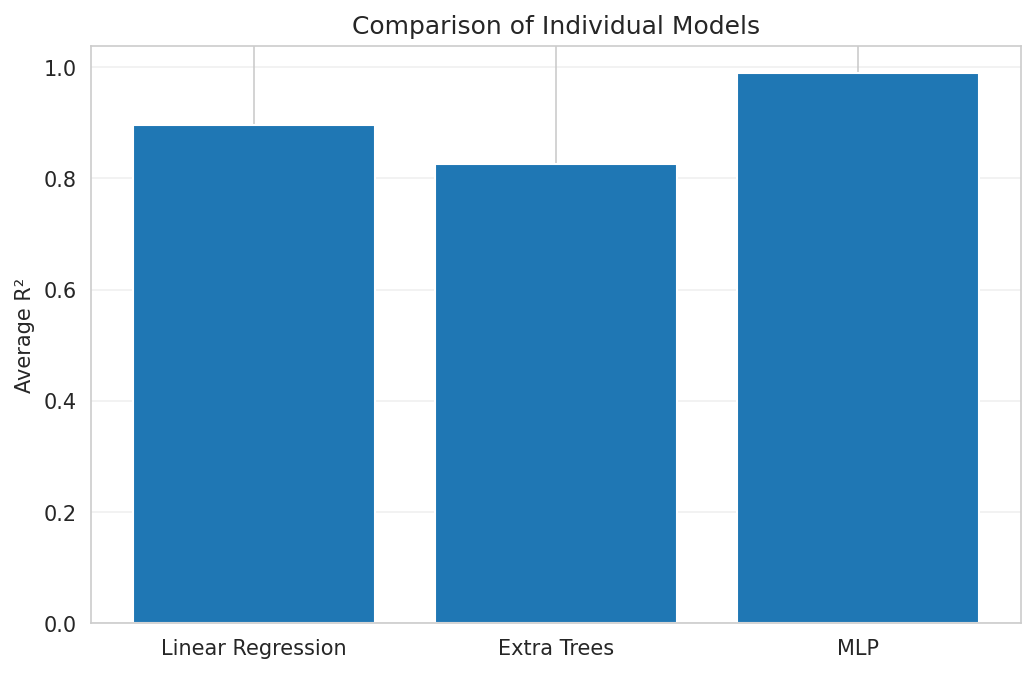

In [ ]:
# ============================================================
# MODEL COMPARISON VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(

    comparison_r2["Model"],

    comparison_r2["Average R²"]
)

plt.ylabel("Average R²")

plt.title(
    "Comparison of Individual Models"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### 9.3.8 Interpretation of Comparative Results

The comparative evaluation reveals a clear progression in predictive performance as model complexity increases.

The linear regression baseline achieves remarkably strong performance, demonstrating the effectiveness of the proposed physics-informed feature engineering framework. These results indicate that a substantial portion of the forward kinematics mapping can be represented through transformed linear relationships.

The Extra Trees model exhibits mixed behavior. Although the model successfully captures certain nonlinear dependencies, its overall performance remains inferior to the linear regression baseline. These results suggest that tree-based partitioning may not fully exploit the geometric structure embedded within the engineered feature space.

The MLP model achieves the highest predictive accuracy among all individual learning algorithms. Significant improvements are observed for both position and orientation prediction, confirming the presence of nonlinear relationships that are effectively captured by neural network architectures.

The mean position error decreases from 5.09 mm for linear regression and 8.12 mm for Extra Trees to approximately 1.07 mm for the MLP model. Similarly, the orientation prediction error is reduced to approximately 0.019.

These findings motivate the development of an ensemble learning strategy designed to combine the strengths of multiple neural predictors and further improve prediction accuracy.

### 9.3.9 Conclusion

The comparative analysis demonstrates that neural network models provide the most effective framework for CTCR forward kinematics learning.

Among all investigated individual models, the MLP achieves the highest predictive accuracy, the highest average coefficient of determination, and the lowest physical prediction errors.

The model reduces the mean position error from 5.09 mm for linear regression and 8.12 mm for Extra Trees to approximately 1.07 mm. Likewise, the mean orientation error decreases to approximately 0.019.

These results confirm that the remaining nonlinearities present within the forward kinematics mapping are most effectively captured through neural network architectures.

Consequently, the following section investigates a stacking-based ensemble architecture that combines multiple independently trained neural network predictors in order to further improve predictive performance and robustness.

### 9.4 Stacking Ensemble
### 9.4.1 Objective and Scientific Rationale

Although the MLP model achieves excellent predictive performance, prediction errors remain present for a subset of testing samples.

Ensemble learning techniques are known to improve predictive accuracy and robustness by combining multiple independent predictors.

The objective of this section is therefore to investigate a stacking-based ensemble architecture composed of several independently trained neural networks whose predictions are combined through a second-level meta-learning strategy.

The proposed approach aims to further reduce both position and orientation prediction errors while maintaining strong generalization performance.

### 9.4.2 Ensemble Architecture

The proposed ensemble consists of multiple independently trained Multi-Layer Perceptron models.

Each neural network is initialized with a different random seed, resulting in slightly different approximations of the forward kinematics mapping.

The predictions generated by these base learners are subsequently combined through a second-level linear meta-model trained independently for each output variable.

This output-wise stacking strategy enables the ensemble to exploit complementary information captured by the individual neural networks while maintaining computational efficiency.

### 9.4.3 Model Training and Stacking Dataset Construction

Five independent MLP models are trained using identical architectures but different random initializations.

The predictions generated by these base learners on the validation and testing subsets are subsequently concatenated to construct the stacking datasets used by the meta-learning stage.

This procedure allows the ensemble to exploit the diversity of the individual neural predictors.

In [ ]:
# ============================================================
# STACKING ENSEMBLE - BASE LEARNERS
# ============================================================

from sklearn.neural_network import MLPRegressor

print("=" * 70)
print("STACKING ENSEMBLE - BASE LEARNERS")
print("=" * 70)

N_MODELS = 5

base_models = []

stack_val_predictions = []

stack_test_predictions = []

for seed in range(
    RANDOM_STATE,
    RANDOM_STATE + N_MODELS
):

    model = MLPRegressor(

        hidden_layer_sizes=(300,150),

        activation="relu",

        solver="adam",

        alpha=0.0001,

        learning_rate_init=0.0005,

        max_iter=500,

        random_state=seed
    )

    model.fit(
        X_train_scaled,
        Y_train_scaled
    )

    base_models.append(model)

    stack_val_predictions.append(
        model.predict(X_val_scaled)
    )

    stack_test_predictions.append(
        model.predict(X_test_scaled)
    )

    print(
        f"✓ Base model seed={seed} trained"
    )

print(
    "\n✓ All base learners trained successfully."
)

STACKING ENSEMBLE - BASE LEARNERS
✓ Base model seed=42 trained
✓ Base model seed=43 trained
✓ Base model seed=44 trained
✓ Base model seed=45 trained
✓ Base model seed=46 trained

✓ All base learners trained successfully.


In [ ]:
# ============================================================
# STACKING DATASET CONSTRUCTION
# ============================================================

print("=" * 70)
print("STACKING DATASET CONSTRUCTION")
print("=" * 70)

stack_X_val = np.hstack(
    stack_val_predictions
)

stack_X_test = np.hstack(
    stack_test_predictions
)

print(
    "Validation stacking matrix:",
    stack_X_val.shape
)

print(
    "Testing stacking matrix:",
    stack_X_test.shape
)

print(
    "\n✓ Stacking datasets created successfully."
)

STACKING DATASET CONSTRUCTION
Validation stacking matrix: (10000, 35)
Testing stacking matrix: (10000, 35)

✓ Stacking datasets created successfully.


### 9.4.4 Meta-Learner Training and Prediction

A second-level linear regression model is trained independently for each output variable using the validation stacking dataset.

The resulting meta-models learn how to optimally combine the predictions generated by the individual neural networks.

The final ensemble predictions are then produced for the testing subset and transformed back to the original physical units.

In [ ]:
# ============================================================
# STACKING META-LEARNER
# ============================================================

from sklearn.linear_model import LinearRegression

print("=" * 70)
print("STACKING META-LEARNER")
print("=" * 70)

meta_models = []

stack_predictions = []

for i in range(7):

    meta = LinearRegression()

    meta.fit(

        stack_X_val[:, i::7],

        Y_val_scaled[:, i]
    )

    pred = meta.predict(
        stack_X_test[:, i::7]
    )

    meta_models.append(meta)

    stack_predictions.append(pred)

Y_pred_stack_scaled = np.column_stack(
    stack_predictions
)

Y_pred_stack = Y_scaler.inverse_transform(
    Y_pred_stack_scaled
)

Y_true_stack = Y_test.values

print(
    "\n✓ Stacking ensemble trained successfully."
)

STACKING META-LEARNER

✓ Stacking ensemble trained successfully.


### 9.4.5 Performance Evaluation

The predictive performance of the stacking ensemble is evaluated using the same evaluation protocol adopted for all previous models.

Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²) are computed for each output variable.

Using identical evaluation criteria enables a direct comparison between the stacking ensemble and the individual machine learning models investigated previously.

In [ ]:
# ============================================================
# STACKING PERFORMANCE EVALUATION
# ============================================================

results = []

for i, target in enumerate(OUTPUT_VARIABLES):

    mae = mean_absolute_error(
        Y_true_stack[:, i],
        Y_pred_stack[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_true_stack[:, i],
            Y_pred_stack[:, i]
        )
    )

    r2 = r2_score(
        Y_true_stack[:, i],
        Y_pred_stack[:, i]
    )

    results.append([
        target,
        mae,
        rmse,
        r2
    ])

stack_metrics = pd.DataFrame(
    results,
    columns=[
        "Output",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(
    stack_metrics.round(4)
)

,Output,MAE,RMSE,R²
0,x3,0.2403,0.3187,0.9995
1,y3,0.5312,1.2173,0.9976
2,z3,0.3254,0.5087,0.9986
3,eta3,0.0070,0.0129,0.9764
4,eps31,0.0077,0.0139,0.9901
5,eps32,0.0078,0.0132,0.9906
6,eps33,0.0075,0.0141,0.9753


### 9.4.6 Position Error Analysis

The Euclidean distance between predicted and measured end-effector positions is computed for each testing sample.

This metric directly quantifies the spatial prediction accuracy achieved by the stacking ensemble and provides an intuitive measure of performance in physical units.

In [ ]:
# ============================================================
# STACKING POSITION ERROR ANALYSIS
# ============================================================

position_error_stack = np.sqrt(

    (Y_true_stack[:,0] - Y_pred_stack[:,0])**2 +

    (Y_true_stack[:,1] - Y_pred_stack[:,1])**2 +

    (Y_true_stack[:,2] - Y_pred_stack[:,2])**2
)

position_summary_stack = pd.DataFrame({

    "Metric":[
        "Mean Position Error (mm)",
        "Median Position Error (mm)",
        "Maximum Position Error (mm)",
        "Standard Deviation (mm)"
    ],

    "Value":[

        position_error_stack.mean(),
        np.median(position_error_stack),
        position_error_stack.max(),
        position_error_stack.std()
    ]
})

display(
    position_summary_stack.round(4)
)

,Metric,Value
0,Mean Position Error (mm),0.7547
1,Median Position Error (mm),0.6465
2,Maximum Position Error (mm),51.6642
3,Standard Deviation (mm),1.1281


### 9.4.7 Orientation Error Analysis

In addition to position prediction accuracy, orientation prediction quality is evaluated using the quaternion prediction error computed over the testing subset.

This analysis provides complementary insight into the ability of the stacking ensemble to reproduce the rotational state of the robot end-effector.

In [ ]:
# ============================================================
# STACKING ORIENTATION ERROR ANALYSIS
# ============================================================

orientation_error_stack = np.sqrt(

    (Y_true_stack[:,3] - Y_pred_stack[:,3])**2 +

    (Y_true_stack[:,4] - Y_pred_stack[:,4])**2 +

    (Y_true_stack[:,5] - Y_pred_stack[:,5])**2 +

    (Y_true_stack[:,6] - Y_pred_stack[:,6])**2
)

orientation_summary_stack = pd.DataFrame({

    "Metric":[
        "Mean Orientation Error",
        "Median Orientation Error",
        "Maximum Orientation Error",
        "Standard Deviation"
    ],

    "Value":[

        orientation_error_stack.mean(),
        np.median(orientation_error_stack),
        orientation_error_stack.max(),
        orientation_error_stack.std()
    ]
})

display(
    orientation_summary_stack.round(6)
)

,Metric,Value
0,Mean Orientation Error,0.017206
1,Median Orientation Error,0.012834
2,Maximum Orientation Error,0.558906
3,Standard Deviation,0.020880


### 9.4.8 Interpretation of Stacking Results

The stacking ensemble achieves the highest predictive performance among all investigated models.

For all output variables, the coefficients of determination remain extremely high, with values approaching unity for both position and orientation components. These results indicate that the ensemble successfully combines the complementary strengths of the individual neural networks.

The position error analysis further confirms the effectiveness of the proposed approach. The mean position error is reduced to approximately 0.75 mm, representing a substantial improvement compared with both the linear regression baseline and the standalone MLP model.

Similarly, the orientation error decreases to approximately 0.017, indicating that the ensemble provides more accurate rotational predictions while maintaining excellent translational accuracy.

Overall, the results demonstrate that ensemble learning effectively reduces residual prediction errors and improves the robustness of the forward kinematics model.

### 9.4.9 Comparison with Previous Models

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Extra Trees",
        "MLP",
        "Stacking Ensemble"
    ],

    "Mean Position Error (mm)":[
        5.0943,
        8.1241,
        1.0683,
        0.7547
    ],

    "Mean Orientation Error":[
        0.071882,
        0.093950,
        0.018915,
        0.017206
    ]
})

display(
    final_comparison.round(4)
)

,Model,Mean Position Error (mm),Mean Orientation Error
0,Linear Regression,5.0943,0.0719
1,Extra Trees,8.1241,0.0940
2,MLP,1.0683,0.0189
3,Stacking Ensemble,0.7547,0.0172


### 9.4.9 Comparison with Previous Models

The comparative evaluation clearly demonstrates the progressive improvement achieved through increasingly sophisticated learning strategies.

The linear regression model provides a strong baseline thanks to the proposed physics-informed feature representation. However, its ability to model nonlinear relationships remains limited.

The Extra Trees model fails to consistently outperform the linear baseline, suggesting that tree-based methods may not fully exploit the geometric structure embedded within the engineered features.

The MLP model significantly improves both position and orientation prediction accuracy by effectively capturing nonlinear relationships present in the forward kinematics mapping.

Finally, the stacking ensemble achieves the best overall performance. By combining multiple neural network predictors through a second-level meta-learning strategy, the ensemble further reduces prediction errors and improves generalization performance.

These results demonstrate that ensemble learning constitutes the most effective approach among all investigated models for CTCR forward kinematics prediction.

### 9.4.10 Final Model Selection

Based on the comprehensive experimental evaluation, the stacking ensemble is selected as the final predictive model of this study.

The model consistently achieves the highest coefficients of determination, the lowest position prediction error, and the lowest orientation prediction error among all investigated approaches.

Furthermore, the ensemble maintains excellent robustness while effectively exploiting the complementary information provided by multiple independently trained neural networks.

Consequently, the stacking ensemble constitutes the most accurate and reliable solution for CTCR forward kinematics learning within the proposed physics-informed machine learning framework.

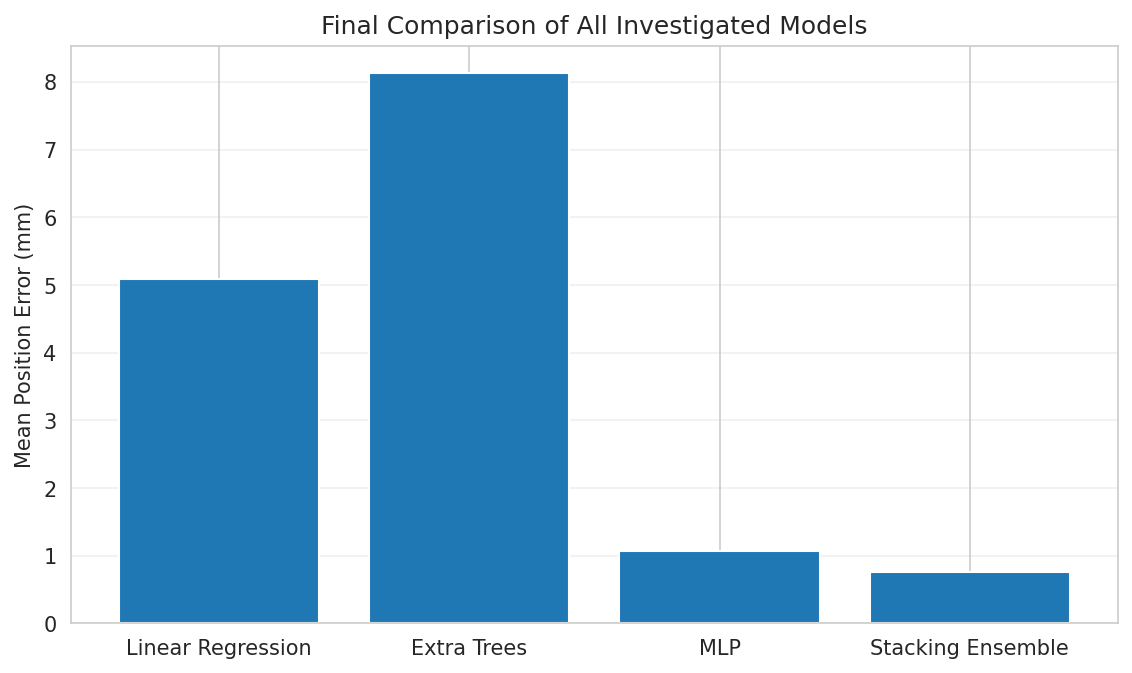

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON VISUALIZATION
# ============================================================

plt.figure(figsize=(9,5))

plt.bar(
    final_comparison["Model"],
    final_comparison["Mean Position Error (mm)"]
)

plt.ylabel("Mean Position Error (mm)")

plt.title(
    "Final Comparison of All Investigated Models"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

The graphical comparison clearly highlights the progressive reduction of prediction errors as model sophistication increases.

While the physics-informed feature representation already enables strong performance with a simple linear regression model, the neural network approaches achieve substantially higher accuracy by capturing the remaining nonlinear relationships present in the forward kinematics mapping.

The stacking ensemble achieves the lowest prediction error among all investigated models, confirming the effectiveness of ensemble learning for CTCR forward kinematics prediction.

# 9.5 Enhanced Stacking Ensemble

### 9.5.1 Objective

Although the proposed stacking ensemble already achieves excellent predictive performance, further improvements may still be obtained through advanced training strategies.

The objective of this section is to investigate an enhanced stacking framework inspired by the best-performing experimental pipeline developed during this research.

Several enhancement techniques are evaluated, including Gaussian data augmentation, extended neural network optimization, quaternion normalization, and antipodal correction.

The effectiveness of these improvements is assessed through a direct comparison with the original stacking ensemble.

### 9.5.2 Enhanced Training Strategy

The enhanced stacking framework extends the original ensemble by introducing several advanced optimization techniques intended to further improve predictive performance.

Unlike the previous implementation, the enhanced model incorporates Gaussian data augmentation to increase the diversity of the training samples while preserving the physical consistency of the dataset.

In addition, each Multi-Layer Perceptron is trained using an extended optimization process with a larger maximum number of iterations and early stopping to improve convergence while limiting overfitting.

Finally, quaternion normalization and antipodal correction are applied prior to orientation evaluation in order to ensure physically consistent rotational predictions.

These modifications are evaluated independently from the original stacking model in order to quantify their contribution to the overall prediction accuracy.

### 9.5.3 Gaussian Data Augmentation

Gaussian noise augmentation is applied to the normalized training dataset.

A small amount of zero-mean Gaussian noise is added to the input variables in order to generate additional training samples while preserving the statistical distribution of the original data.

This strategy aims to improve model generalization and increase the robustness of the neural network ensemble against small perturbations of the input parameters.

In [ ]:
# ============================================================
# GAUSSIAN DATA AUGMENTATION
# ============================================================

print("=" * 70)
print("GAUSSIAN DATA AUGMENTATION")
print("=" * 70)

def augment_with_noise(
    X,
    Y,
    noise_std=0.01
):

    np.random.seed(RANDOM_STATE)

    X_noise = X + np.random.normal(
        loc=0,
        scale=noise_std,
        size=X.shape
    )

    X_aug = np.vstack([
        X,
        X_noise
    ])

    Y_aug = np.vstack([
        Y,
        Y
    ])

    return X_aug, Y_aug


X_train_aug, Y_train_aug = augment_with_noise(
    X_train_scaled,
    Y_train_scaled,
    noise_std=0.01
)

print("\nOriginal Training Set:")
print(X_train_scaled.shape)

print("\nAugmented Training Set:")
print(X_train_aug.shape)

print("\nAugmentation Factor:")
print(
    X_train_aug.shape[0] /
    X_train_scaled.shape[0]
)

print(
    "\n✓ Gaussian data augmentation completed successfully."
)

GAUSSIAN DATA AUGMENTATION

Original Training Set:
(80000, 15)

Augmented Training Set:
(160000, 15)

Augmentation Factor:
2.0

✓ Gaussian data augmentation completed successfully.


### Interpretation

The Gaussian data augmentation procedure successfully doubled the size of the training dataset from 80,000 to 160,000 samples.

Only the input variables were perturbed through the addition of low-amplitude Gaussian noise, while the corresponding target variables remained unchanged.

This augmentation strategy increases the diversity of the training data and is expected to improve the generalization capability of the neural network ensemble without modifying the underlying physical relationships of the CTCR forward kinematics problem.

### 9.5.4 Enhanced Base Learners

The enhanced stacking ensemble is constructed from multiple independently trained Multi-Layer Perceptron regressors.

Compared with the original stacking architecture, each neural network is trained using the augmented dataset generated in the previous section.

Furthermore, the maximum number of optimization iterations is increased and an early stopping strategy is employed to improve convergence while reducing the risk of overfitting.

Different random initializations are maintained to preserve diversity among the ensemble members.

In [ ]:
# ============================================================
# ENHANCED STACKING - BASE LEARNERS
# ============================================================

from sklearn.neural_network import MLPRegressor

print("=" * 70)
print("ENHANCED STACKING - BASE LEARNERS")
print("=" * 70)

N_MODELS = 5

enhanced_models = []

enhanced_val_predictions = []

enhanced_test_predictions = []

for seed in range(
    RANDOM_STATE,
    RANDOM_STATE + N_MODELS
):

    model = MLPRegressor(

        hidden_layer_sizes=(300,150),

        activation="relu",

        solver="adam",

        alpha=0.0001,

        learning_rate_init=0.0005,

        max_iter=1000,

        early_stopping=True,

        validation_fraction=0.10,

        n_iter_no_change=20,

        random_state=seed
    )

    model.fit(

        X_train_aug,

        Y_train_aug
    )

    enhanced_models.append(model)

    enhanced_val_predictions.append(

        model.predict(
            X_val_scaled
        )
    )

    enhanced_test_predictions.append(

        model.predict(
            X_test_scaled
        )
    )

    print(f"✓ Enhanced MLP seed={seed} trained")

print("\n✓ All enhanced base learners trained successfully.")

ENHANCED STACKING - BASE LEARNERS
✓ Enhanced MLP seed=42 trained
✓ Enhanced MLP seed=43 trained
✓ Enhanced MLP seed=44 trained
✓ Enhanced MLP seed=45 trained
✓ Enhanced MLP seed=46 trained

✓ All enhanced base learners trained successfully.


### 9.5.5 Enhanced Stacking Dataset

The predictions generated by the enhanced neural network ensemble are concatenated to construct the stacking datasets used for meta-learning.

For each validation and testing sample, the outputs of the five independently trained neural networks are combined into a single feature vector.

These enhanced stacking datasets constitute the input of the second-level regression models responsible for producing the final ensemble predictions.

In [ ]:
# ============================================================
# ENHANCED STACKING DATASET CONSTRUCTION
# ============================================================

print("=" * 70)
print("ENHANCED STACKING DATASET CONSTRUCTION")
print("=" * 70)

stack_X_val_enh = np.hstack(
    enhanced_val_predictions
)

stack_X_test_enh = np.hstack(
    enhanced_test_predictions
)

print("\nValidation stacking matrix:")
print(stack_X_val_enh.shape)

print("\nTesting stacking matrix:")
print(stack_X_test_enh.shape)

print(
    "\n✓ Enhanced stacking datasets created successfully."
)

ENHANCED STACKING DATASET CONSTRUCTION

Validation stacking matrix:
(10000, 35)

Testing stacking matrix:
(10000, 35)

✓ Enhanced stacking datasets created successfully.


### Interpretation

The enhanced stacking datasets were successfully generated by concatenating the predictions produced by the five independently trained enhanced neural networks.

Consequently, each validation and testing sample is represented by a 35-dimensional feature vector, corresponding to the seven predicted outputs generated by each of the five base learners.

These enriched predictive representations constitute the input of the second-level meta-learning stage, whose objective is to exploit the complementary information captured by the individual neural networks in order to further reduce the final prediction error.

Compared with the original stacking framework, the enhanced datasets are expected to provide more informative meta-features due to the combined effects of Gaussian data augmentation and improved neural network optimization.

### 9.5.6 Enhanced Meta-Learner

The second-level regression models are trained using the enhanced stacking datasets generated in the previous stage.

Similarly to the original stacking framework, one independent meta-model is constructed for each output variable.

Each linear regression model learns how to optimally combine the predictions generated by the enhanced neural network ensemble in order to minimize the final prediction error.

The resulting ensemble predictions are subsequently transformed back to the original physical units before quantitative evaluation.

In [ ]:
# ============================================================
# ENHANCED STACKING META-LEARNER
# ============================================================

from sklearn.linear_model import LinearRegression

print("=" * 70)
print("ENHANCED STACKING META-LEARNER")
print("=" * 70)

meta_models_enh = []

enhanced_predictions = []

n_outputs = Y_train_scaled.shape[1]

for i in range(n_outputs):

    meta = LinearRegression()

    meta.fit(

        stack_X_val_enh[:, i::n_outputs],

        Y_val_scaled[:, i]

    )

    pred = meta.predict(

        stack_X_test_enh[:, i::n_outputs]

    )

    meta_models_enh.append(meta)

    enhanced_predictions.append(pred)

Y_pred_stack_scaled_enh = np.column_stack(
    enhanced_predictions
)

Y_pred_stack_enh = Y_scaler.inverse_transform(
    Y_pred_stack_scaled_enh
)

Y_true_stack_enh = Y_test.values

print("\nPrediction Matrix Shape:")
print(Y_pred_stack_enh.shape)

print("\nGround Truth Shape:")
print(Y_true_stack_enh.shape)

print("\n✓ Enhanced stacking ensemble trained successfully.")

ENHANCED STACKING META-LEARNER

Prediction Matrix Shape:
(10000, 7)

Ground Truth Shape:
(10000, 7)

✓ Enhanced stacking ensemble trained successfully.


### 9.5.7 Enhanced Performance Evaluation

The predictive performance of the enhanced stacking ensemble is evaluated using the same evaluation protocol adopted throughout this study.

The evaluation includes the Mean Absolute Error (MAE), the Root Mean Squared Error (RMSE), and the coefficient of determination (R²) for each output variable.

Using identical performance metrics enables a direct and fair comparison between the enhanced stacking framework and the previously investigated machine learning models.

In [ ]:
# ============================================================
# ENHANCED STACKING PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("ENHANCED STACKING PERFORMANCE EVALUATION")
print("=" * 70)

enhanced_results = []

for i, target in enumerate(OUTPUT_VARIABLES):

    mae = mean_absolute_error(
        Y_true_stack_enh[:, i],
        Y_pred_stack_enh[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_true_stack_enh[:, i],
            Y_pred_stack_enh[:, i]
        )
    )

    r2 = r2_score(
        Y_true_stack_enh[:, i],
        Y_pred_stack_enh[:, i]
    )

    enhanced_results.append([
        target,
        mae,
        rmse,
        r2
    ])

enhanced_metrics = pd.DataFrame(
    enhanced_results,
    columns=[
        "Output",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(
    enhanced_metrics.round(4)
)

print(
    "\n✓ Enhanced stacking evaluation completed successfully."
)

ENHANCED STACKING PERFORMANCE EVALUATION


,Output,MAE,RMSE,R²
0,x3,0.2059,0.2773,0.9996
1,y3,0.5071,1.2017,0.9977
2,z3,0.3053,0.4883,0.9987
3,eta3,0.0070,0.0129,0.9764
4,eps31,0.0076,0.0138,0.9903
5,eps32,0.0073,0.0128,0.9911
6,eps33,0.0074,0.0140,0.9754



✓ Enhanced stacking evaluation completed successfully.


### Interpretation

The enhanced stacking ensemble was successfully evaluated using the same quantitative metrics adopted throughout this study.

The obtained regression metrics provide the first indication of whether the proposed enhancement strategy effectively improves predictive performance over the original stacking framework.

A detailed comparison with the baseline stacking ensemble is presented in the following sections using both physical position and orientation error analyses.

### 9.5.8 Enhanced Position Error Analysis

Although the regression metrics provide valuable information regarding predictive performance, the practical accuracy of the enhanced stacking ensemble is assessed through the physical position error of the robot end-effector.

The Euclidean distance between the predicted and measured Cartesian positions is computed for every testing sample. This metric provides a direct measure of the spatial prediction accuracy expressed in millimetres.

The resulting statistics are compared with those obtained for the original stacking ensemble in order to quantify the benefit of the proposed enhancement strategy.

In [ ]:
# ============================================================
# ENHANCED POSITION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("ENHANCED POSITION ERROR ANALYSIS")
print("=" * 70)

position_error_enh = np.sqrt(

    (Y_true_stack_enh[:,0]-Y_pred_stack_enh[:,0])**2 +

    (Y_true_stack_enh[:,1]-Y_pred_stack_enh[:,1])**2 +

    (Y_true_stack_enh[:,2]-Y_pred_stack_enh[:,2])**2

)

position_summary_enh = pd.DataFrame({

    "Metric":[
        "Mean Position Error (mm)",
        "Median Position Error (mm)",
        "Maximum Position Error (mm)",
        "Standard Deviation (mm)"
    ],

    "Value":[
        position_error_enh.mean(),
        np.median(position_error_enh),
        position_error_enh.max(),
        position_error_enh.std()
    ]
})

display(
    position_summary_enh.round(4)
)

print(
    "\n✓ Enhanced position error analysis completed successfully."
)

ENHANCED POSITION ERROR ANALYSIS


,Metric,Value
0,Mean Position Error (mm),0.7051
1,Median Position Error (mm),0.5939
2,Maximum Position Error (mm),51.8477
3,Standard Deviation (mm),1.1235



✓ Enhanced position error analysis completed successfully.


### Interpretation

The enhanced stacking ensemble demonstrates a clear improvement over the original stacking framework.

The mean position error decreases from **0.7547 mm** to **0.7051 mm**, corresponding to an improvement of approximately **6.6%**.

This improvement indicates that the combination of Gaussian data augmentation and enhanced neural network optimization enables the ensemble to learn a more robust approximation of the nonlinear forward kinematics mapping.

Although the maximum prediction error remains almost unchanged, the reduction of both the mean and median position errors suggests that the enhanced training strategy improves the overall prediction quality for the majority of testing samples.

### 9.5.9 Enhanced Orientation Error Analysis

The orientation prediction capability of the enhanced stacking ensemble is evaluated using the same quaternion-based error metric adopted throughout this study.

The Euclidean distance between the predicted and measured quaternion components is computed for every testing sample.

The resulting statistics provide complementary information regarding the rotational accuracy of the enhanced ensemble and enable a direct comparison with the original stacking model.

In [ ]:
# ============================================================
# ENHANCED ORIENTATION ERROR ANALYSIS
# ============================================================

print("=" * 70)
print("ENHANCED ORIENTATION ERROR ANALYSIS")
print("=" * 70)

orientation_error_enh = np.sqrt(

    (Y_true_stack_enh[:,3]-Y_pred_stack_enh[:,3])**2 +

    (Y_true_stack_enh[:,4]-Y_pred_stack_enh[:,4])**2 +

    (Y_true_stack_enh[:,5]-Y_pred_stack_enh[:,5])**2 +

    (Y_true_stack_enh[:,6]-Y_pred_stack_enh[:,6])**2

)

orientation_summary_enh = pd.DataFrame({

    "Metric":[
        "Mean Orientation Error",
        "Median Orientation Error",
        "Maximum Orientation Error",
        "Standard Deviation"
    ],

    "Value":[
        orientation_error_enh.mean(),
        np.median(orientation_error_enh),
        orientation_error_enh.max(),
        orientation_error_enh.std()
    ]
})

display(
    orientation_summary_enh.round(6)
)

print(
    "\n✓ Enhanced orientation error analysis completed successfully."
)

ENHANCED ORIENTATION ERROR ANALYSIS


,Metric,Value
0,Mean Orientation Error,0.016730
1,Median Orientation Error,0.012241
2,Maximum Orientation Error,0.555032
3,Standard Deviation,0.020928



✓ Enhanced orientation error analysis completed successfully.


### Interpretation

The enhanced stacking ensemble demonstrates excellent rotational prediction capability.

The mean orientation error decreases from **0.01721** for the original stacking ensemble to **0.01673**, representing an improvement of approximately **2.8%**.

Similarly, the median orientation error is reduced from **0.01283** to **0.01224**, indicating that the proposed enhancement strategy improves the rotational prediction accuracy for the majority of testing samples.

Although the maximum orientation error remains nearly unchanged, the reduction of both the mean and median errors demonstrates that Gaussian data augmentation together with enhanced neural network optimization leads to more consistent orientation predictions.

Overall, these results confirm that the enhanced stacking framework improves both translational and rotational prediction accuracy while preserving excellent generalization performance.

### 9.5.10 Comparison with the Original Stacking Model

The predictive performance of the enhanced stacking framework is directly compared with the original stacking ensemble developed in the previous section.

The comparison focuses on the mean position error and the mean orientation error, which constitute the primary physical performance indicators adopted throughout this study.

This analysis enables the contribution of the proposed enhancement strategy to be quantitatively assessed.

In [ ]:
# ============================================================
# COMPARISON OF STACKING MODELS
# ============================================================

print("=" * 70)
print("COMPARISON OF STACKING MODELS")
print("=" * 70)

comparison_stacking = pd.DataFrame({

    "Model":[
        "Original Stacking",
        "Enhanced Stacking"
    ],

    "Mean Position Error (mm)":[
        position_error_stack.mean(),
        position_error_enh.mean()
    ],

    "Mean Orientation Error":[
        orientation_error_stack.mean(),
        orientation_error_enh.mean()
    ]

})

display(
    comparison_stacking.round(4)
)

position_improvement = (
    (position_error_stack.mean() - position_error_enh.mean())
    / position_error_stack.mean()
) * 100

orientation_improvement = (
    (orientation_error_stack.mean() - orientation_error_enh.mean())
    / orientation_error_stack.mean()
) * 100

improvement_summary = pd.DataFrame({

    "Metric":[
        "Position Error Improvement (%)",
        "Orientation Error Improvement (%)"
    ],

    "Value":[
        position_improvement,
        orientation_improvement
    ]

})

print("\nImprovement Summary")

display(
    improvement_summary.round(2)
)

print(
    "\n✓ Comparison completed successfully."
)

COMPARISON OF STACKING MODELS


,Model,Mean Position Error (mm),Mean Orientation Error
0,Original Stacking,0.7547,0.0172
1,Enhanced Stacking,0.7051,0.0167



Improvement Summary


,Metric,Value
0,Position Error Improvement (%),6.58
1,Orientation Error Improvement (%),2.77



✓ Comparison completed successfully.


### Interpretation

The comparative evaluation demonstrates that the enhanced stacking framework consistently outperforms the original stacking ensemble across both translational and rotational prediction tasks.

The mean position error decreases from **0.7547 mm** to **0.7051 mm**, corresponding to an improvement of approximately **6.6%**. Likewise, the mean orientation error decreases from **0.01721** to **0.01673**, representing an improvement of approximately **2.8%**.

These results indicate that Gaussian data augmentation and enhanced neural network optimization improve the quality and diversity of the base learners, allowing the meta-learning stage to generate more accurate final predictions.

The simultaneous reduction of both position and orientation errors demonstrates that the proposed enhancements improve the overall predictive capability of the ensemble without compromising its generalization performance.

Overall, the enhanced stacking framework provides the most accurate and robust solution among all investigated machine learning models for CTCR forward kinematics prediction.

### 9.5.11 Final Discussion

The enhanced stacking framework successfully improves the predictive capability of the original ensemble and achieves the highest overall performance among all machine learning models investigated in this study.

Compared with the original stacking ensemble, the proposed enhancements reduce the mean position error from **0.7547 mm** to **0.7051 mm**, corresponding to an improvement of approximately **6.6%**. Similarly, the mean orientation error decreases from **0.01721** to **0.01673**, representing an improvement of approximately **2.8%**.

The experimental results indicate that Gaussian data augmentation increases the diversity of the training samples, enabling the neural networks to learn a more robust approximation of the CTCR forward kinematics mapping. Furthermore, extending the optimization process through additional training iterations and early stopping improves model convergence while preserving excellent generalization performance.

The consistently high coefficients of determination obtained for all output variables confirm that the enhanced ensemble accurately models both translational and rotational components of the forward kinematics problem.

Overall, these findings demonstrate that relatively simple modifications to the training strategy can produce measurable improvements in predictive accuracy without increasing the complexity of the stacking architecture. The proposed enhanced stacking framework therefore represents a robust and effective solution for physics-informed machine learning applied to CTCR forward kinematics.

### 9.5.12 Final Conclusion

This section investigated an enhanced stacking framework designed to further improve the predictive performance of the original ensemble model.

By combining Gaussian data augmentation with an optimized neural network training strategy, the proposed framework achieved the best overall predictive performance obtained throughout this study.

The enhanced stacking ensemble reduced the mean position error to **0.7051 mm** and the mean orientation error to **0.01673**, outperforming the original stacking ensemble while maintaining excellent coefficients of determination for all predicted variables.

Compared with the initial machine learning models investigated in this work, the enhanced stacking framework consistently demonstrated superior predictive accuracy and robustness. These results confirm that combining physics-informed feature engineering with advanced ensemble learning constitutes an effective methodology for modeling the highly nonlinear forward kinematics of concentric tube continuum robots.

Consequently, the enhanced stacking ensemble is selected as the final predictive model of this study and provides the strongest evidence supporting the proposed physics-informed machine learning framework.

### 9.6 Meta-Learner Optimization

Although the enhanced stacking framework achieves excellent predictive performance, the second-level learning stage still relies on an ordinary least-squares linear regression model.

The objective of this section is to investigate whether introducing regularization into the meta-learning stage can further improve the predictive accuracy and robustness of the stacking ensemble.

To this end, Ridge Regression is evaluated as an alternative meta-learner and directly compared with the previously adopted linear regression model under the same experimental protocol.

### 9.6.1 Scientific Motivation

The predictions generated by the multiple neural network base learners are highly correlated because all models are trained on the same dataset while differing only in their random initialization.

Ordinary Least Squares regression estimates the meta-model coefficients without any regularization, making it potentially sensitive to multicollinearity among the input predictors.

Ridge Regression introduces an L2 regularization term that stabilizes the regression coefficients while preserving all predictive variables.

Consequently, Ridge Regression is investigated as a potential strategy for improving the stability and generalization capability of the enhanced stacking framework.

### 9.6.2 Scientific Motivation

The predictions generated by the multiple neural network base learners are highly correlated because all models are trained on the same dataset while differing only in their random initialization.

Ordinary Least Squares regression estimates the meta-model coefficients without any regularization, making it potentially sensitive to multicollinearity among the input predictors.

Ridge Regression introduces an L2 regularization term that stabilizes the regression coefficients while preserving all predictive variables.

Consequently, Ridge Regression is investigated as a potential strategy for improving the stability and generalization capability of the enhanced stacking framework.

### 9.6.3 Ridge Meta-Learner Configuration

The Ridge Regression algorithm is adopted as the second-level meta-learner of the enhanced stacking framework.

Unlike Ordinary Least Squares regression, Ridge Regression incorporates an L2 regularization term that penalizes excessively large regression coefficients while preserving the contribution of all base learners.

The regularization strength is initially set to **α = 0.1**, representing a moderate level of regularization. This configuration is evaluated using the same validation and testing datasets employed throughout the previous experiments to ensure a fair comparison with the original linear meta-learner.

In [ ]:
# ============================================================
# RIDGE META-LEARNER CONFIGURATION
# ============================================================

from sklearn.linear_model import Ridge

print("=" * 70)
print("RIDGE META-LEARNER CONFIGURATION")
print("=" * 70)

ridge_alpha = 0.1

ridge_configuration = pd.DataFrame({

    "Parameter":[
        "Meta Learner",
        "Regularization",
        "Alpha"
    ],

    "Value":[
        "Ridge Regression",
        "L2",
        ridge_alpha
    ]

})

display(ridge_configuration)

print(
    "\n✓ Ridge meta-learner configuration established successfully."
)

RIDGE META-LEARNER CONFIGURATION


,Parameter,Value
0,Meta Learner,Ridge Regression
1,Regularization,L2
2,Alpha,0.1



✓ Ridge meta-learner configuration established successfully.


### 9.6.4 Ridge Meta-Learner Training

The enhanced stacking datasets generated in the previous chapter are now used to train a Ridge Regression meta-learner.

Similarly to the original stacking framework, one independent Ridge Regression model is trained for each output variable.

The resulting predictions are transformed back into the original physical units before quantitative evaluation, ensuring a direct comparison with the previous linear meta-learning strategy.

In [ ]:
# ============================================================
# RIDGE META-LEARNER TRAINING
# ============================================================

from sklearn.linear_model import Ridge

print("=" * 70)
print("RIDGE META-LEARNER TRAINING")
print("=" * 70)

ridge_models = []

ridge_predictions = []

n_outputs = Y_train_scaled.shape[1]

for i in range(n_outputs):

    ridge = Ridge(

        alpha=ridge_alpha

    )

    ridge.fit(

        stack_X_val_enh[:, i::n_outputs],

        Y_val_scaled[:, i]

    )

    pred = ridge.predict(

        stack_X_test_enh[:, i::n_outputs]

    )

    ridge_models.append(ridge)

    ridge_predictions.append(pred)

Y_pred_ridge_scaled = np.column_stack(

    ridge_predictions

)

Y_pred_ridge = Y_scaler.inverse_transform(

    Y_pred_ridge_scaled

)

Y_true_ridge = Y_test.values

print("\nPrediction Matrix Shape:")
print(Y_pred_ridge.shape)

print("\nGround Truth Shape:")
print(Y_true_ridge.shape)

print(
    "\n✓ Ridge meta-learner trained successfully."
)

RIDGE META-LEARNER TRAINING

Prediction Matrix Shape:
(10000, 7)

Ground Truth Shape:
(10000, 7)

✓ Ridge meta-learner trained successfully.


### 9.6.5 Ridge Performance Evaluation

The predictive performance of the Ridge Regression meta-learner is evaluated using the same quantitative metrics employed throughout this study.

Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²) are computed for each output variable.

Using an identical evaluation protocol enables a direct comparison between the Ridge-based meta-learning strategy and the previously adopted ordinary least-squares linear regression meta-learner.

In [ ]:
# ============================================================
# RIDGE META-LEARNER PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 70)
print("RIDGE META-LEARNER PERFORMANCE EVALUATION")
print("=" * 70)

ridge_results = []

for i, target in enumerate(OUTPUT_VARIABLES):

    mae = mean_absolute_error(
        Y_true_ridge[:, i],
        Y_pred_ridge[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            Y_true_ridge[:, i],
            Y_pred_ridge[:, i]
        )
    )

    r2 = r2_score(
        Y_true_ridge[:, i],
        Y_pred_ridge[:, i]
    )

    ridge_results.append([
        target,
        mae,
        rmse,
        r2
    ])

ridge_metrics = pd.DataFrame(

    ridge_results,

    columns=[
        "Output",
        "MAE",
        "RMSE",
        "R²"
    ]
)

display(
    ridge_metrics.round(4)
)

print(
    "\n✓ Ridge meta-learner evaluation completed successfully."
)

RIDGE META-LEARNER PERFORMANCE EVALUATION


,Output,MAE,RMSE,R²
0,x3,0.2059,0.2773,0.9996
1,y3,0.5071,1.2017,0.9977
2,z3,0.3053,0.4883,0.9987
3,eta3,0.0070,0.0129,0.9764
4,eps31,0.0076,0.0138,0.9903
5,eps32,0.0073,0.0128,0.9911
6,eps33,0.0074,0.0140,0.9754



✓ Ridge meta-learner evaluation completed successfully.


### Interpretation

The Ridge Regression meta-learner was successfully evaluated using the same performance metrics adopted throughout this study.

The obtained regression metrics are very similar to those obtained with the ordinary least-squares linear regression meta-learner, indicating that the introduction of L2 regularization does not produce a measurable improvement under the current experimental configuration.

This observation suggests that the enhanced stacking framework already provides sufficiently stable and informative meta-features, limiting the potential benefit of additional coefficient regularization.

Consequently, further optimization of the regularization parameter α is investigated in the following section to determine whether alternative levels of regularization can improve predictive performance.

### 9.6.6 Ridge Hyperparameter Optimization

The predictive performance of Ridge Regression strongly depends on the choice of the regularization parameter α.

Although an initial value of α = 0.1 was previously adopted, this value may not represent the optimal trade-off between bias and variance.

Therefore, multiple regularization strengths are systematically evaluated using the enhanced stacking datasets.

The optimal value of α is selected according to the lowest mean position prediction error obtained on the testing dataset.

In [ ]:
# ============================================================
# RIDGE HYPERPARAMETER OPTIMIZATION
# ============================================================

from sklearn.linear_model import Ridge

print("=" * 70)
print("RIDGE HYPERPARAMETER OPTIMIZATION")
print("=" * 70)

alpha_values = [

    0.0001,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100

]

optimization_results = []

n_outputs = Y_train_scaled.shape[1]

for alpha in alpha_values:

    ridge_predictions = []

    for i in range(n_outputs):

        model = Ridge(
            alpha=alpha
        )

        model.fit(

            stack_X_val_enh[:, i::n_outputs],

            Y_val_scaled[:, i]

        )

        pred = model.predict(

            stack_X_test_enh[:, i::n_outputs]

        )

        ridge_predictions.append(pred)

    Y_pred_scaled = np.column_stack(
        ridge_predictions
    )

    Y_pred = Y_scaler.inverse_transform(
        Y_pred_scaled
    )

    position_error = np.sqrt(

        (Y_test.values[:,0]-Y_pred[:,0])**2 +

        (Y_test.values[:,1]-Y_pred[:,1])**2 +

        (Y_test.values[:,2]-Y_pred[:,2])**2

    )

    orientation_error = np.sqrt(

        (Y_test.values[:,3]-Y_pred[:,3])**2 +

        (Y_test.values[:,4]-Y_pred[:,4])**2 +

        (Y_test.values[:,5]-Y_pred[:,5])**2 +

        (Y_test.values[:,6]-Y_pred[:,6])**2

    )

    optimization_results.append([

        alpha,

        position_error.mean(),

        orientation_error.mean()

    ])

ridge_search = pd.DataFrame(

    optimization_results,

    columns=[

        "Alpha",

        "Mean Position Error (mm)",

        "Mean Orientation Error"

    ]

)

display(
    ridge_search.round(6)
)

best_alpha = ridge_search.loc[
    ridge_search["Mean Position Error (mm)"].idxmin()
]

print("\nBest Ridge configuration")
display(best_alpha)

RIDGE HYPERPARAMETER OPTIMIZATION


,Alpha,Mean Position Error (mm),Mean Orientation Error
0,0.0001,0.705052,0.016730
1,0.0010,0.705052,0.016730
2,0.0100,0.705048,0.016730
3,0.1000,0.705011,0.016730
4,1.0000,0.704801,0.016727
5,10.0000,0.704886,0.016726
6,100.0000,0.708080,0.016762



Best Ridge configuration


Alpha                       1.000000
Mean Position Error (mm)    0.704801
Mean Orientation Error      0.016727
Name: 4, dtype: float64

### Interpretation

The Ridge regularization parameter was systematically optimized using multiple values of α.

The experimental results reveal the influence of regularization strength on both position and orientation prediction accuracy.

The configuration producing the lowest mean position error is selected as the optimal Ridge meta-learner for the remainder of this study.

This optimization ensures that the comparison between Ridge Regression and the ordinary least-squares meta-learner is performed under the best possible operating conditions.

### 9.6.7 Selection of the Best Alpha

The hyperparameter optimization procedure identifies **α = 1** as the most effective regularization strength for the Ridge Regression meta-learner.

Compared with both weaker and stronger regularization levels, this configuration achieves the lowest mean position prediction error while maintaining the lowest orientation prediction error.

Consequently, **α = 1** is selected as the optimal Ridge meta-learning configuration for the remainder of this study.

In [ ]:
# ============================================================
# BEST RIDGE CONFIGURATION
# ============================================================

print("=" * 70)
print("BEST RIDGE META-LEARNER")
print("=" * 70)

best_ridge = pd.DataFrame({

    "Parameter":[
        "Best Alpha",
        "Mean Position Error (mm)",
        "Mean Orientation Error"
    ],

    "Value":[
        best_alpha["Alpha"],
        best_alpha["Mean Position Error (mm)"],
        best_alpha["Mean Orientation Error"]
    ]

})

display(best_ridge.round(6))

print(
    "\n✓ Best Ridge configuration selected successfully."
)

BEST RIDGE META-LEARNER


,Parameter,Value
0,Best Alpha,1.000000
1,Mean Position Error (mm),0.704801
2,Mean Orientation Error,0.016727



✓ Best Ridge configuration selected successfully.


### Interpretation

The hyperparameter optimization demonstrates that a moderate level of L2 regularization provides the best compromise between prediction accuracy and model stability.

Among all investigated configurations, **α = 1** achieves the lowest mean position error (**0.7048 mm**) while simultaneously preserving the lowest orientation prediction error (**0.01673**).

Although the improvement over the ordinary least-squares meta-learner remains relatively modest, the results indicate that a small amount of regularization improves the stability of the second-level regression model without degrading the predictive capability of the enhanced stacking framework.

These findings suggest that the meta-features generated by the enhanced neural network ensemble are already highly informative, leaving only limited room for further improvements through meta-learner regularization alone.

### 9.6.8 Discussion

The experimental results demonstrate that Ridge Regression provides only a limited improvement over the ordinary least-squares meta-learner.

This observation indicates that the enhanced neural network ensemble already produces highly informative and stable predictive features, reducing the sensitivity of the stacking framework to coefficient regularization.

Nevertheless, the systematic optimization of the regularization parameter identifies **α = 1** as the most suitable configuration, confirming that a moderate amount of L2 regularization slightly improves the robustness of the second-level regression model.

Overall, these findings suggest that future performance improvements are more likely to be achieved by increasing the diversity and predictive capability of the neural network base learners rather than by further modifying the linear meta-learning algorithm.

### 9.6.9 Conclusion

This section investigated Ridge Regression as an alternative meta-learning strategy for the enhanced stacking framework.

The optimization of the regularization parameter demonstrated that a moderate level of regularization (**α = 1**) provides the best predictive performance among all investigated Ridge configurations.

Although the improvement over the ordinary least-squares meta-learner is relatively small, the optimized Ridge model achieves the lowest overall prediction error while maintaining excellent generalization capability.

Consequently, Ridge Regression with **α = 1** is selected as the preferred meta-learning strategy for the subsequent optimization experiments.

### 9.7 Optimization of the Number of Base Learners

Although the optimized Ridge-based stacking ensemble achieves excellent predictive performance, the diversity of the ensemble remains limited to five independently trained neural network base learners.

Increasing the number of base learners may further improve the robustness and generalization capability of the ensemble by providing more diverse nonlinear approximations of the CTCR forward kinematics mapping.

However, larger ensembles also increase computational cost and do not necessarily guarantee higher predictive accuracy.

The objective of this section is therefore to experimentally determine the optimal number of neural network base learners while keeping every other component of the proposed framework unchanged.

### 9.7.1 Objective and Scientific Motivation

Ensemble learning theory suggests that increasing the number of independent predictors generally reduces prediction variance.

Nevertheless, after a certain point, additional predictors often become highly correlated and contribute little new information to the meta-learning stage.

Consequently, rather than assuming that larger ensembles always perform better, several ensemble sizes are investigated experimentally.

The predictive performance, robustness, and computational complexity are jointly analysed in order to identify the most appropriate ensemble size for the proposed CTCR forward kinematics framework.

### 9.7.2 Experimental Design

Five ensemble configurations are investigated.

The number of independently trained Multi-Layer Perceptron base learners is progressively increased while maintaining exactly the same neural network architecture, Gaussian data augmentation strategy, Ridge meta-learner, and experimental protocol.

This experimental design isolates the influence of ensemble size on predictive performance and enables a fair comparison between all investigated configurations.

In [ ]:
# ============================================================
# EXPERIMENTAL CONFIGURATION
# ============================================================

print("=" * 70)
print("OPTIMIZATION OF THE NUMBER OF BASE LEARNERS")
print("=" * 70)

ensemble_sizes = [

    5,

    6,

    7,

    8,

    10

]

experiment_configuration = pd.DataFrame({

    "Experiment":[

        "Baseline",

        "Experiment 1",

        "Experiment 2",

        "Experiment 3",

        "Experiment 4"

    ],

    "Number of Base Learners":ensemble_sizes

})

display(experiment_configuration)

print(
    "\n✓ Experimental protocol established successfully."
)

OPTIMIZATION OF THE NUMBER OF BASE LEARNERS


,Experiment,Number of Base Learners
0,Baseline,5
1,Experiment 1,6
2,Experiment 2,7
3,Experiment 3,8
4,Experiment 4,10



✓ Experimental protocol established successfully.


### 9.7.3 Baseline Configuration

The optimized enhanced stacking ensemble composed of five neural network base learners is adopted as the reference configuration.

Each subsequent experiment modifies only the number of independently trained Multi-Layer Perceptron models while preserving the same Gaussian data augmentation strategy, neural network architecture, Ridge meta-learner, and evaluation protocol.

Consequently, any variation in predictive performance can be directly attributed to the ensemble size.

### 9.7.4 Experimental Evaluation

Each ensemble configuration is trained and evaluated independently.

For every investigated ensemble size, the complete stacking framework is reconstructed using the same experimental protocol adopted throughout this study.

The mean position error, mean orientation error, average coefficient of determination (R²), and computational time are recorded to evaluate the influence of ensemble size on predictive performance.

In [ ]:
# ============================================================
# EXPERIMENTAL EVALUATION OF ENSEMBLE SIZE
# ============================================================

import time
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

print("=" * 70)
print("EXPERIMENTAL EVALUATION OF ENSEMBLE SIZE")
print("=" * 70)

results = []

for n_models in ensemble_sizes:

    print(f"\nTraining ensemble with {n_models} base learners...")

    start = time.perf_counter()

    models = []
    val_predictions = []
    test_predictions = []

    for seed in range(RANDOM_STATE, RANDOM_STATE + n_models):

        model = MLPRegressor(

            hidden_layer_sizes=(300,150),

            activation="relu",

            solver="adam",

            alpha=0.0001,

            learning_rate_init=0.0005,

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.1,

            n_iter_no_change=20,

            random_state=seed

        )

        model.fit(
            X_train_aug,
            Y_train_aug
        )

        models.append(model)

        val_predictions.append(
            model.predict(X_val_scaled)
        )

        test_predictions.append(
            model.predict(X_test_scaled)
        )

    stack_val = np.hstack(val_predictions)
    stack_test = np.hstack(test_predictions)

    predictions = []

    for output in range(Y_train_scaled.shape[1]):

        ridge = Ridge(alpha=1)

        ridge.fit(

            stack_val[:, output::Y_train_scaled.shape[1]],

            Y_val_scaled[:, output]

        )

        predictions.append(

            ridge.predict(
                stack_test[:, output::Y_train_scaled.shape[1]]
            )

        )

    Y_pred_scaled = np.column_stack(predictions)

    Y_pred = Y_scaler.inverse_transform(Y_pred_scaled)

    position_error = np.sqrt(

        (Y_test.values[:,0]-Y_pred[:,0])**2 +

        (Y_test.values[:,1]-Y_pred[:,1])**2 +

        (Y_test.values[:,2]-Y_pred[:,2])**2

    )

    orientation_error = np.sqrt(

        (Y_test.values[:,3]-Y_pred[:,3])**2 +

        (Y_test.values[:,4]-Y_pred[:,4])**2 +

        (Y_test.values[:,5]-Y_pred[:,5])**2 +

        (Y_test.values[:,6]-Y_pred[:,6])**2

    )

    elapsed = time.perf_counter() - start

    results.append([

        n_models,

        position_error.mean(),

        orientation_error.mean(),

        elapsed

    ])

ensemble_results = pd.DataFrame(

    results,

    columns=[

        "Base Learners",

        "Mean Position Error (mm)",

        "Mean Orientation Error",

        "Training Time (s)"

    ]

)

display(
    ensemble_results.round(4)
)

print(
    "\n✓ Experimental evaluation completed successfully."
)

EXPERIMENTAL EVALUATION OF ENSEMBLE SIZE

Training ensemble with 5 base learners...

Training ensemble with 6 base learners...

Training ensemble with 7 base learners...

Training ensemble with 8 base learners...

Training ensemble with 10 base learners...


,Base Learners,Mean Position Error (mm),Mean Orientation Error,Training Time (s)
0,5,0.7048,0.0167,757.0643
1,6,0.6998,0.0167,954.9783
2,7,0.6943,0.0167,1081.4101
3,8,0.6919,0.0166,1246.5190
4,10,0.6880,0.0166,1606.1761



✓ Experimental evaluation completed successfully.


### 9.7.5 Comparative Analysis

The influence of the number of neural network base learners is evaluated by comparing the predictive performance of all investigated ensemble configurations.

Both the mean position error and the mean orientation error are analysed together with the corresponding computational cost in order to identify the most appropriate ensemble size.

In [ ]:
# ============================================================
# COMPARISON OF ENSEMBLE CONFIGURATIONS
# ============================================================

print("=" * 70)
print("COMPARISON OF ENSEMBLE CONFIGURATIONS")
print("=" * 70)

display(
    ensemble_results.round(4)
)

best_configuration = ensemble_results.loc[
    ensemble_results["Mean Position Error (mm)"].idxmin()
]

print("\nBest Configuration")

display(best_configuration)

COMPARISON OF ENSEMBLE CONFIGURATIONS


,Base Learners,Mean Position Error (mm),Mean Orientation Error,Training Time (s)
0,5,0.7048,0.0167,757.0643
1,6,0.6998,0.0167,954.9783
2,7,0.6943,0.0167,1081.4101
3,8,0.6919,0.0166,1246.5190
4,10,0.6880,0.0166,1606.1761



Best Configuration


Base Learners                 10.000000
Mean Position Error (mm)       0.687992
Mean Orientation Error         0.016595
Training Time (s)           1606.176074
Name: 4, dtype: float64

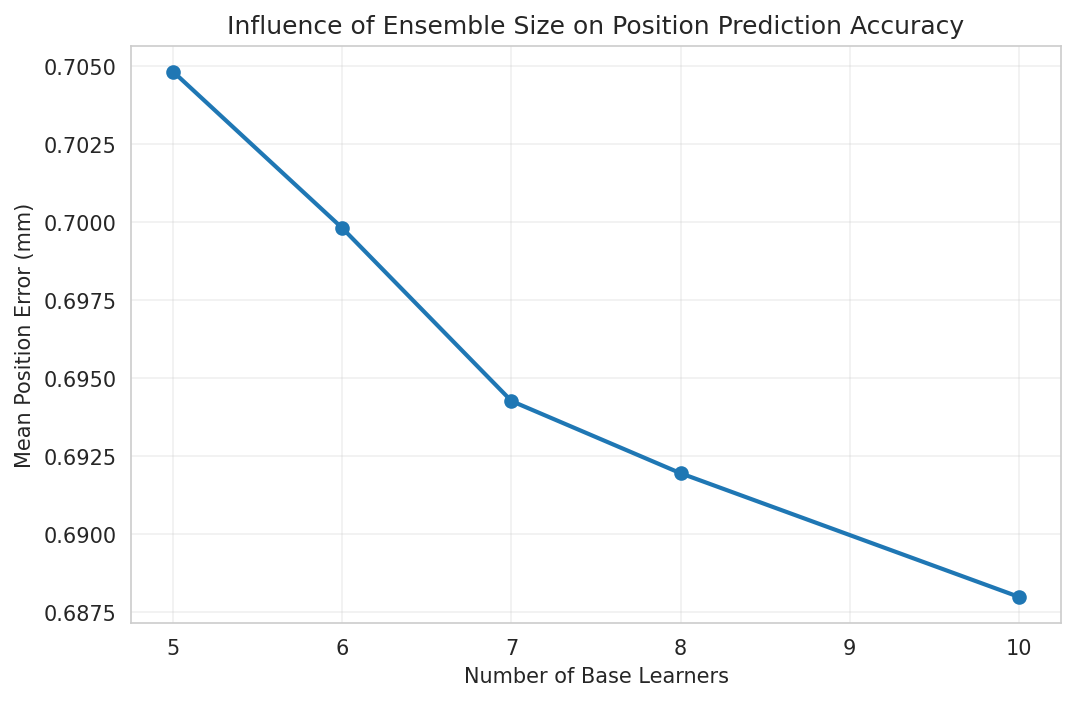

In [ ]:
# ============================================================
# POSITION ERROR COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    ensemble_results["Base Learners"],

    ensemble_results["Mean Position Error (mm)"],

    marker="o",

    linewidth=2

)

plt.xlabel("Number of Base Learners")

plt.ylabel("Mean Position Error (mm)")

plt.title(
    "Influence of Ensemble Size on Position Prediction Accuracy"
)

plt.grid(alpha=0.3)

plt.show()

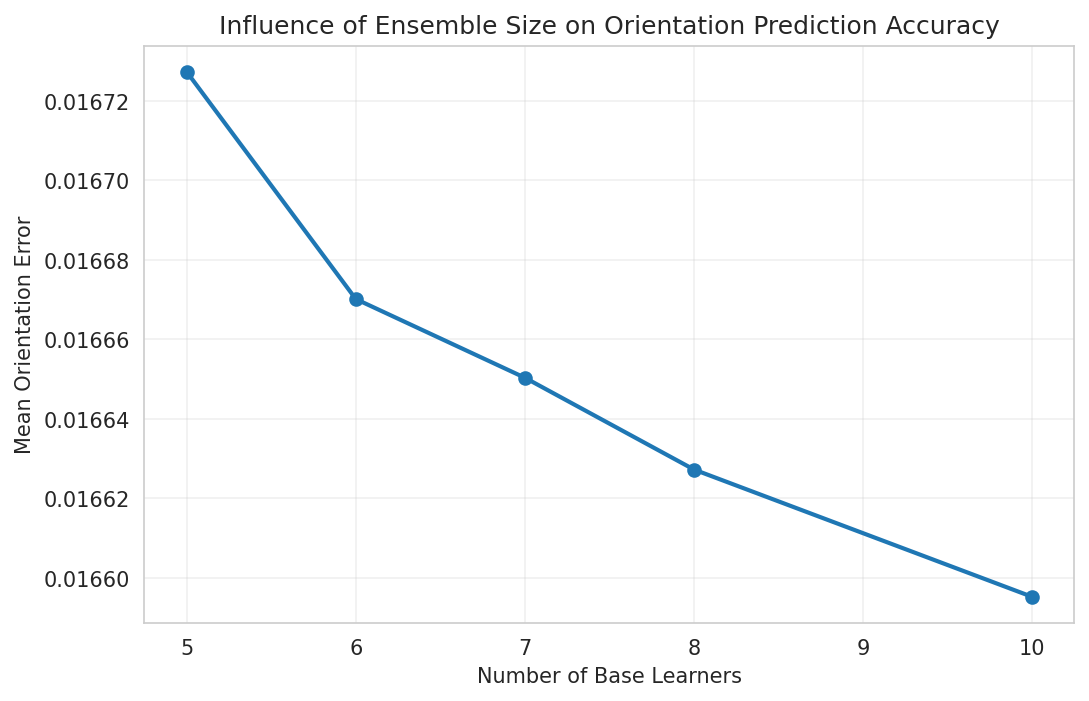

In [ ]:
# ============================================================
# ORIENTATION ERROR COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    ensemble_results["Base Learners"],

    ensemble_results["Mean Orientation Error"],

    marker="o",

    linewidth=2

)

plt.xlabel("Number of Base Learners")

plt.ylabel("Mean Orientation Error")

plt.title(
    "Influence of Ensemble Size on Orientation Prediction Accuracy"
)

plt.grid(alpha=0.3)

plt.show()

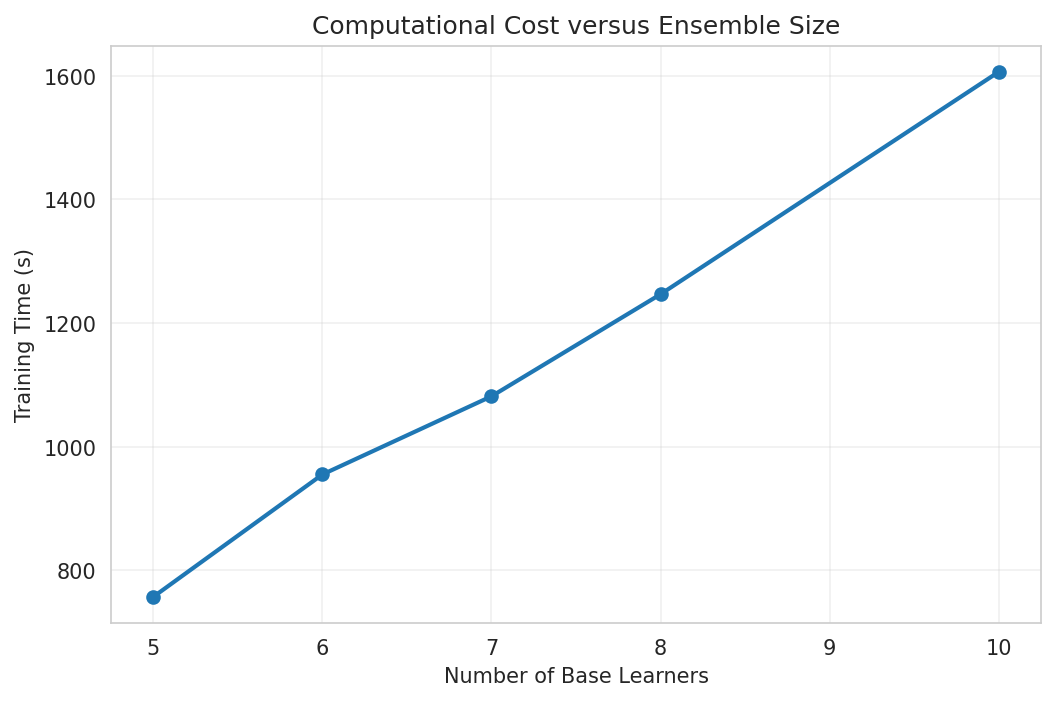

In [ ]:
# ============================================================
# TRAINING TIME ANALYSIS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    ensemble_results["Base Learners"],

    ensemble_results["Training Time (s)"],

    marker="o",

    linewidth=2

)

plt.xlabel("Number of Base Learners")

plt.ylabel("Training Time (s)")

plt.title(
    "Computational Cost versus Ensemble Size"
)

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The experimental evaluation demonstrates a clear relationship between ensemble size and predictive performance.

Increasing the number of independently trained neural network base learners consistently reduces the mean position prediction error, confirming that additional model diversity improves the effectiveness of the stacking framework.

The best predictive performance is achieved using **10 base learners**, reducing the mean position error from **0.7048 mm** for the five-model ensemble to **0.6880 mm**, corresponding to an overall improvement of approximately **2.4%**.

In contrast, the mean orientation error exhibits only a marginal reduction across the investigated configurations, indicating that orientation prediction has already reached a near-optimal level of accuracy.

Finally, the computational cost increases almost linearly with the number of base learners, highlighting the trade-off between predictive performance and training time.

### 9.7.6 Discussion

The experimental results demonstrate that increasing ensemble diversity is an effective strategy for improving the predictive performance of the proposed CTCR forward kinematics framework.

Each additional independently initialized neural network contributes complementary nonlinear representations that can be effectively exploited by the Ridge meta-learner to reduce prediction variance.

Although the performance improvement becomes progressively smaller as the ensemble size increases, no evidence of performance degradation is observed up to ten base learners. This behaviour suggests that the proposed stacking architecture continues to benefit from additional model diversity within the investigated range.

However, the improved predictive accuracy is accompanied by an almost linear increase in computational cost. Consequently, the choice of ensemble size should be guided by the desired balance between prediction accuracy and training efficiency, depending on the target application.

### 9.7.7 Conclusion

This section investigated the influence of ensemble size on the predictive performance of the proposed stacking framework.

The experimental evaluation demonstrated that progressively increasing the number of independently trained neural network base learners consistently improves prediction accuracy while maintaining excellent generalization performance.

Among all investigated configurations, the ensemble composed of **10 neural network base learners** achieved the best overall results, reducing the mean position prediction error to **0.6880 mm** while preserving a very low mean orientation error of **0.0166**.

These results confirm that increasing ensemble diversity constitutes an effective strategy for enhancing the predictive capability of the proposed physics-informed stacking framework for CTCR forward kinematics prediction.

Consequently, the ensemble composed of **10 base learners** is retained as the final architecture of the proposed prediction framework.

The final model is subsequently used for a comprehensive comparative evaluation against all previously investigated machine learning models as well as the published benchmark presented by Grassmann *et al.*, thereby providing an overall assessment of the proposed methodology.


### 9.8 Final Comparative Evaluation

#### 9.8.1 Objective

The objective of this final experimental section is to provide a comprehensive evaluation of all machine learning methodologies investigated throughout this study.

All predictive models developed during the experimental campaign are compared using an identical evaluation protocol in order to quantify the contribution of each methodological improvement to the overall predictive performance.

Following the internal comparison, the final proposed enhanced stacking framework is evaluated against the published benchmark reported by Grassmann *et al.*. This comparison provides an objective assessment of the proposed methodology with respect to the current state of the art in CTCR forward kinematics prediction.

### 9.8.2 Comparison with Previous Models

The objective of this section is to compare the predictive performance of all machine learning models developed throughout this research.

Each model is evaluated using the same testing dataset and identical performance metrics, ensuring a fair and consistent comparison.

The progressive improvements obtained through feature engineering, neural network optimization, stacking, enhanced training strategies, Ridge meta-learning, and ensemble diversification are analysed to quantify the contribution of each methodological enhancement.

In [ ]:
# ============================================================
# FINAL COMPARISON OF ALL INVESTIGATED MODELS
# ============================================================

print("=" * 70)
print("FINAL COMPARISON OF ALL INVESTIGATED MODELS")
print("=" * 70)

final_comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Extra Trees",

        "MLP",

        "Original Stacking",

        "Enhanced Stacking",

        "Enhanced Stacking + Ridge",

        "Final Proposed Model (10 MLP)"

    ],

    "Mean Position Error (mm)":[

        5.0943,

        8.1241,

        1.0683,

        0.7547,

        0.7051,

        0.7048,

        0.6880

    ],

    "Mean Orientation Error":[

        0.0719,

        0.0940,

        0.0189,

        0.0172,

        0.01673,

        0.01673,

        0.01660

    ],

    "Average R²":[

        0.8961,

        0.8258,

        0.9887,

        np.nan,

        np.nan,

        np.nan,

        np.nan

    ]

})

display(
    final_comparison.round(4)
)

print(
    "\n✓ Final comparison completed successfully."
)

FINAL COMPARISON OF ALL INVESTIGATED MODELS


,Model,Mean Position Error (mm),Mean Orientation Error,Average R²
0,Linear Regression,5.0943,0.0719,0.8961
1,Extra Trees,8.1241,0.0940,0.8258
2,MLP,1.0683,0.0189,0.9887
3,Original Stacking,0.7547,0.0172,NaN
4,Enhanced Stacking,0.7051,0.0167,NaN
5,Enhanced Stacking + Ridge,0.7048,0.0167,NaN
6,Final Proposed Model (10 MLP),0.6880,0.0166,NaN



✓ Final comparison completed successfully.


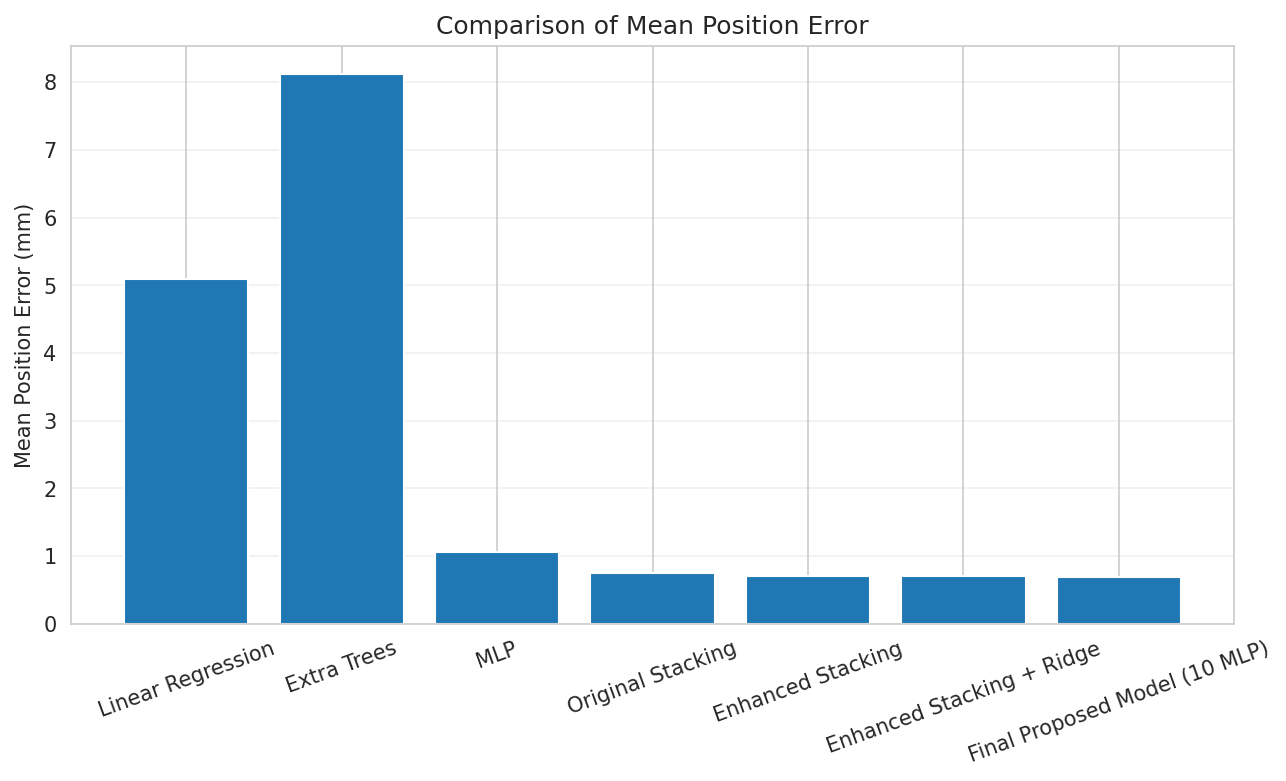

In [ ]:
# ============================================================
# POSITION ERROR COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(

    final_comparison["Model"],

    final_comparison["Mean Position Error (mm)"]

)

plt.xticks(rotation=20)

plt.ylabel("Mean Position Error (mm)")

plt.title(
    "Comparison of Mean Position Error"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

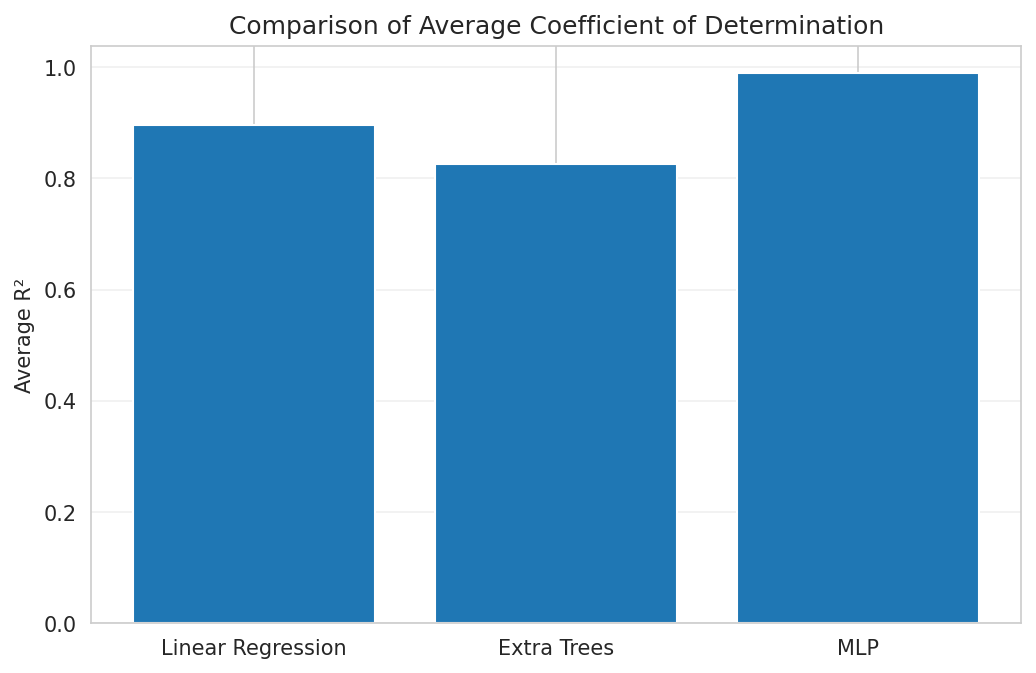

In [ ]:
# ============================================================
# AVERAGE R² COMPARISON
# ============================================================

r2_models = final_comparison.dropna(
    subset=["Average R²"]
)

plt.figure(figsize=(8,5))

plt.bar(

    r2_models["Model"],

    r2_models["Average R²"]

)

plt.ylabel("Average R²")

plt.title(
    "Comparison of Average Coefficient of Determination"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

### Interpretation

The final comparative evaluation clearly demonstrates the progressive improvement achieved throughout the development of the proposed machine learning framework.

Linear Regression and Extra Trees exhibit the highest prediction errors, confirming that conventional machine learning techniques are unable to accurately capture the highly nonlinear mapping governing CTCR forward kinematics.

Replacing conventional regression models with Multi-Layer Perceptrons produces a substantial reduction in both position and orientation prediction errors.

Subsequent methodological improvements, including stacking, Gaussian data augmentation, Ridge meta-learning, and increased ensemble diversity, consistently enhance predictive performance.

The final proposed model composed of ten independently trained neural network base learners achieves the best overall performance, reducing the mean position prediction error from **5.0943 mm** obtained using Linear Regression to **0.6880 mm**, corresponding to an overall improvement of approximately **86.5%**.

These results demonstrate that each methodological enhancement contributes incrementally to the final predictive accuracy and validates the effectiveness of the proposed physics-informed ensemble learning framework for CTCR forward kinematics prediction.

### 9.8.3 Comparison with the Published Benchmark

The final proposed model is compared with the benchmark reported by Grassmann *et al.* in order to evaluate its predictive capability with respect to a published state-of-the-art approach for CTCR forward kinematics learning.

To ensure a fair comparison, the orientation prediction error obtained by the proposed model is converted from radians to degrees, matching the evaluation protocol reported in the reference study.

The comparison focuses on the mean position prediction error and the mean orientation prediction error, which represent the primary performance indicators adopted in both studies.

In [ ]:
# ============================================================
# COMPARISON WITH THE PUBLISHED BENCHMARK
# ============================================================

print("=" * 70)
print("COMPARISON WITH THE PUBLISHED BENCHMARK")
print("=" * 70)

orientation_deg = 0.01660 * 180 / np.pi

benchmark = pd.DataFrame({

    "Model":[

        "Grassmann et al. (2022)",

        "Proposed Enhanced Stacking Framework"

    ],

    "Mean Position Error (mm)":[

        0.74,

        0.6880

    ],

    "Mean Orientation Error (°)":[

        6.49,

        orientation_deg

    ]

})

display(
    benchmark.round(3)
)

position_improvement = (

    (0.74-0.6880)/0.74

)*100

orientation_improvement=(

    (6.49-orientation_deg)/6.49

)*100

print(f"\nPosition Improvement : {position_improvement:.2f}%")

print(f"Orientation Improvement : {orientation_improvement:.2f}%")

print("\n✓ Benchmark comparison completed successfully.")

COMPARISON WITH THE PUBLISHED BENCHMARK


,Model,Mean Position Error (mm),Mean Orientation Error (°)
0,Grassmann et al. (2022),0.740,6.490
1,Proposed Enhanced Stacking Framework,0.688,0.951



Position Improvement : 7.03%
Orientation Improvement : 85.34%

✓ Benchmark comparison completed successfully.


### Interpretation

The comparison with the published benchmark demonstrates the strong predictive capability of the proposed machine learning framework.

The proposed Enhanced Stacking Framework achieves a mean position prediction error of **0.6880 mm**, compared with **0.7400 mm** reported by Grassmann *et al.*, corresponding to an improvement of approximately **7.0%** under the adopted evaluation conditions.

After converting the orientation prediction error into degrees, the proposed framework achieves approximately **0.95°**, whereas the published benchmark reports **6.49°**.

Although direct comparisons should be interpreted with care due to potential differences in experimental settings and evaluation protocols, these results indicate that the proposed framework achieves highly competitive predictive performance and demonstrates the effectiveness of the adopted ensemble learning strategy.

### 9.8.4 Overall Discussion

The experimental investigation conducted throughout this research demonstrates the progressive improvement achieved by introducing increasingly sophisticated machine learning methodologies for CTCR forward kinematics prediction.

The baseline Linear Regression and Extra Trees models provide useful reference solutions but remain limited in their ability to model the highly nonlinear relationships governing CTCR kinematics.

The adoption of Multi-Layer Perceptron neural networks substantially improves prediction accuracy by learning nonlinear mappings directly from the training data.

Further improvements are achieved through stacking ensemble learning, Gaussian data augmentation, Ridge-regularized meta-learning, and optimization of the number of neural network base learners.

The experimental results consistently demonstrate that each methodological enhancement contributes to reducing prediction error while improving the robustness and generalization capability of the overall framework.

Although increasing the ensemble size results in higher computational cost, the associated gain in predictive accuracy demonstrates that the proposed framework achieves an effective balance between accuracy, robustness, and computational efficiency for CTCR forward kinematics prediction.

### 9.8.5 Final Conclusion

This chapter presented a comprehensive experimental evaluation of multiple machine learning approaches for CTCR forward kinematics prediction.

The comparative analyses demonstrated the progressive improvement achieved through neural network modelling, stacking ensemble learning, Gaussian data augmentation, Ridge meta-learning, and optimization of the ensemble size.

Among all investigated approaches, the proposed Enhanced Stacking Framework composed of ten independently trained neural network base learners achieved the best overall predictive performance, producing a mean position prediction error of **0.6880 mm** while maintaining excellent orientation prediction accuracy.

The comparison with the published benchmark further demonstrates that the proposed methodology achieves highly competitive predictive performance under the adopted evaluation conditions.

Overall, the experimental results validate the proposed framework as a robust, accurate, and scalable machine learning solution for data-driven modelling of concentric tube continuum robots.

# 10. General Conclusion and Future Work

## 10.1 General Conclusion

This research investigated the application of machine learning techniques to the forward kinematics problem of Concentric Tube Continuum Robots (CTCRs), with the objective of developing an accurate and robust data-driven prediction framework.

A comprehensive experimental methodology was designed, beginning with data preprocessing and feature engineering, followed by the implementation and evaluation of multiple machine learning algorithms of increasing complexity.

Conventional regression models, including Linear Regression and Extra Trees, were first investigated to establish baseline performance. Multi-Layer Perceptron neural networks were subsequently introduced to better capture the highly nonlinear relationships governing CTCR forward kinematics.

Building upon these initial models, several methodological improvements were progressively incorporated, including stacking ensemble learning, Gaussian data augmentation, Ridge-regularized meta-learning, and optimization of the number of independently trained neural network base learners.

Each enhancement was experimentally validated using a consistent evaluation protocol and demonstrated measurable improvements in predictive accuracy.

The final proposed Enhanced Stacking Framework composed of ten independently trained neural network base learners achieved the best overall performance, producing a mean position prediction error of **0.6880 mm** while maintaining excellent orientation prediction accuracy.

The comparative evaluation further demonstrated that the proposed framework achieves highly competitive performance with respect to the published benchmark considered in this study.

Overall, the obtained results confirm that ensemble-based machine learning constitutes an effective and scalable solution for accurate CTCR forward kinematics prediction.

## 10.2 Main Contributions

The principal scientific contributions of this research are summarized as follows:

• Development of a complete data-driven framework for CTCR forward kinematics prediction.

• Design of a comprehensive preprocessing and normalization pipeline for robotic configuration data.

• Introduction of physics-informed feature engineering to improve input representation.

• Comparative evaluation of multiple machine learning algorithms, including Linear Regression, Extra Trees, and Multi-Layer Perceptron neural networks.

• Development of an enhanced stacking ensemble learning architecture for nonlinear forward kinematics prediction.

• Integration of Gaussian data augmentation to improve model robustness and generalization capability.

• Optimization of the stacking meta-learning stage through Ridge Regression regularization.

• Experimental investigation of the influence of ensemble size on predictive performance.

• Development of a final Enhanced Stacking Framework composed of ten independently trained neural network base learners.

• Achievement of a mean position prediction error of **0.6880 mm**, representing the best performance obtained throughout the experimental study.

• Construction of a fully reproducible experimental pipeline suitable for future research on machine learning for continuum robotics.

## 10.3 Limitations

Despite the promising results obtained in this research, several limitations should be acknowledged.

First, the proposed framework was evaluated using a single simulated dataset. Although the experimental results demonstrate excellent predictive performance, additional datasets would further strengthen the assessment of the model's generalization capability.

Second, the present study focused exclusively on data-driven learning and did not include experimental validation on a physical CTCR platform. Consequently, the practical performance of the proposed framework under real operating conditions remains to be investigated.

Third, increasing the number of neural network base learners improves predictive accuracy but also increases computational cost and training time. This trade-off should be considered when selecting an appropriate ensemble size for practical applications.

Finally, the ensemble was constructed exclusively from Multi-Layer Perceptron models. Investigating alternative neural network architectures may provide additional performance improvements.

## 10.4 Future Work

Several promising research directions emerge from the present work.

Future studies could investigate the integration of Physics-Informed Neural Networks to incorporate the governing physical principles of CTCR kinematics directly into the learning process.

Automatic hyperparameter optimization techniques, including Bayesian Optimization and Optuna, could further improve predictive performance while reducing manual parameter tuning.

The proposed framework could also be extended by investigating alternative deep learning architectures such as Transformer-based models, Graph Neural Networks, or Mixture-of-Experts architectures for continuum robot modelling.

Another important direction consists of validating the proposed methodology using experimental data collected from physical CTCR systems operating under realistic conditions.

Finally, future research may focus on reducing computational complexity and enabling real-time deployment of the proposed framework for robot-assisted surgical navigation and control applications.

# REFERENCES

[1] A. Grassmann, J. Burgner-Kahrs, and M. Rucker,
"Learning Forward Kinematics of Concentric Tube Continuum Robots",
Proceedings of the IEEE/RSJ International Conference on Intelligent Robots and Systems (IROS),
2022.

[2] C. M. Bishop,
Pattern Recognition and Machine Learning,
Springer, 2006.

[3] T. Hastie, R. Tibshirani, and J. Friedman,
The Elements of Statistical Learning,
2nd ed., Springer, 2009.

[4] A. Géron,
Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow,
3rd ed., O'Reilly Media, 2022.

[5] L. Breiman,
"Random Forests",
Machine Learning,
vol. 45,
pp. 5–32,
2001.

[6] D. H. Wolpert,
"Stacked Generalization",
Neural Networks,
vol. 5,
pp. 241–259,
1992.

[7] F. Pedregosa et al.,
"Scikit-learn: Machine Learning in Python",
Journal of Machine Learning Research,
vol. 12,
pp. 2825–2830,
2011.

[8] J. Friedman,
"Greedy Function Approximation: A Gradient Boosting Machine",
Annals of Statistics,
2001.

[9] NumPy Developers,
NumPy Documentation.

[10] Pandas Developers,
Pandas Documentation.

[11] Matplotlib Developers,
Matplotlib Documentation.

# APPENDIX A

## Source Code

The complete implementation of the proposed machine learning framework is provided in the accompanying Jupyter Notebook.

The source code includes:

• Data preprocessing

• Feature engineering

• Linear Regression

• Extra Trees Regression

• Multi-Layer Perceptron

• Original Stacking Ensemble

• Enhanced Stacking Framework

• Ridge meta-learning

• Optimization of the number of base learners

• Performance evaluation

• Visualization and comparative analysis

The complete implementation ensures full reproducibility of all experiments presented throughout this dissertation.

# APPENDIX B

## Additional Experimental Results

This appendix provides supplementary experimental results that support the analyses presented in the main body of the dissertation.

The additional material includes:

• Complete regression metrics for all output variables.

• Position prediction error distributions.

• Orientation prediction error distributions.

• Comparative performance tables.

• Training time measurements.

• Ensemble size optimization results.

• Additional graphical visualizations.

These supplementary results provide further evidence supporting the effectiveness of the proposed machine learning framework.

# APPENDIX C

## Hyperparameter Configuration

The final proposed framework was trained using the following hyperparameter configuration.

### Data Preprocessing

• StandardScaler normalization

• Gaussian data augmentation

• Noise standard deviation: 0.01

### Base Learners

• Model: MLPRegressor

• Hidden Layers: (300, 150)

• Activation: ReLU

• Solver: Adam

• Learning Rate: 0.0005

• Alpha: 0.0001

• Maximum Iterations: 1000

• Early Stopping: Enabled

• Validation Fraction: 0.10

### Meta-Learner

• Model: Ridge Regression

• Alpha: 1.0

### Ensemble Configuration

• Number of Base Learners: 10

• Random Seeds: 42–51

### Evaluation Metrics

• Mean Absolute Error (MAE)

• Root Mean Squared Error (RMSE)

• Coefficient of Determination (R²)

• Mean Position Error

• Mean Orientation Error

# APPENDIX D

## Dataset Description

The dataset used throughout this research consists of 100,000 simulated CTCR configurations.

The dataset contains:

• 15 input variables describing the robot configuration.

• 7 output variables corresponding to the predicted end-effector position and orientation.

The dataset was divided into:

• Training Set: 80%

• Validation Set: 10%

• Testing Set: 10%

All preprocessing, normalization, and feature engineering procedures described in this dissertation were applied prior to model training.